# EEG / Frontal Alpha Asymmetry and instructed rating changes after price presentation

Analysis notebook for the PLOS ONE revision (PONE-D-26-33768). **Every analysis reported in the
manuscript and its supporting information is computed in this notebook, from the raw recordings.**

**How to run.** Open the notebook in the project folder (`V16_R1/`) and run all cells from the top.
It needs `data/` (raw XDF recordings, ratings, precomputed ICA solutions), Python 3.12 with
MNE-Python, statsmodels, scikit-learn, joblib and pandas, and takes about 9 minutes on an idle 8-core
laptop (the permutation and bootstrap loops run in parallel). The run time is printed at the end; the
saved run took longer because the machine was busy.

| Part | What it does | Writes |
|---|---|---|
| **I. Preprocessing and thesis analyses** | raw XDF → CSV → filter → ICA → price-locked epochs → FAA trial table; Tables 1, 3, 4; tonic and robustness checks; Fig 3 and S1 Fig; the thesis examiners' analyses | `fig/` |
| **II. PLOS revision analyses** | rating-change descriptives; signed change and Table 2; nested comparisons; FAA operationalization; sensitivity package; temporal specificity; permutation audit; classification | `plos_upload/supporting_information/S1–S6_Table.csv` |
| **III. Verification** | the rebuilt trial table equals the analysed one; thesis statistics; every number quoted in the manuscript; the figures equal the submitted files | — |

Participants and sessions are identified only by anonymous codes (`subjNN_sessM`, `S01`–`S21`).

In [1]:
# Cell 1 — Imports & configuration
import os, re, warnings
import numpy as np
import pandas as pd
import mne
warnings.filterwarnings("ignore")
mne.set_log_level("ERROR")

DATA = "./data"
csv_dir   = f"{DATA}/csv"
ica_dir   = f"{DATA}/ICA"
rating_dir= f"{DATA}/raw"
os.makedirs("fig", exist_ok=True)

sfreq = 512.0
# CSV has Fp1..AF4 + Oz; Oz is dropped -> 15-ch 10-20 montage (matches paper)
ch_names_eeg = ["Fp1","Fp2","F7","F8","F3","Fz","F4","C3","Cz","C4","P3","Pz","P4","AF3","AF4","Oz"]
event_dict = {"show_fixation1-1":1,"show_product1":2,"show_product_scale1":3,
              "show_fixation1-2":4,"show_price1":5,"show_price_scale1":6}
PRICE_ID, PRODUCT_ID = 5, 2

# Rating/raw folders are named subjNN_sessM (de-identified); derived from CSV id+session in Cell 5.

# ICA components to remove per recording, selected by visual inspection (index -> [components]).
# Corrected after visual re-review: idx 4 (subj03_sess1) [1]->[0], idx 40 (subj21_sess1) [0]->[4].
exclude_dict = {0:[0,1],1:[0,1],2:[0],3:[0],4:[0],5:[0],6:[0],7:[0],8:[0],9:[0],10:[0],11:[1],
 12:[0],13:[0],14:[0],15:[0],16:[0],17:[0],18:[0],19:[0],20:[0,1],21:[0],22:[0,1],23:[0],
 24:[0,1],25:[0],26:[0],27:[0],28:[0,1],29:[2],30:[0],31:[0],32:[0],33:[0],34:[0],35:[0],
 36:[0],37:[0],38:[0],39:[0],40:[4],41:[0]}

# Thesis-defense slide figures (Cells R19, R21) are not part of the manuscript; they are kept
# for completeness and skipped unless this is set to True.
MAKE_DEFENSE_SLIDES = False
import time; _T0 = time.time()   # total run time is printed at the end of Part III
from IPython.core.magic import register_cell_magic

@register_cell_magic
def run_if(flag, cell):
    if eval(flag, get_ipython().user_ns):
        get_ipython().run_cell(cell)
    else:
        print(f"skipped (set {flag} = True in Cell 1 to run this cell)")


# Part I — Preprocessing and thesis analyses

## Data preparation — Raw LabRecorder XDF → CSV

Converts the raw `.xdf` recordings under `data/raw/<id>/<id>.xdf` into the per-recording CSVs (`data/csv/<id>.csv`) consumed below, so the pipeline is reproducible from raw. **Idempotent** — recordings whose CSV already exists are skipped, and `pyxdf` is imported only when a conversion is actually needed.

In [2]:
# Cell 1b — Raw LabRecorder XDF -> per-recording CSV (reproducibility from raw)
# Each data/raw/<id>/<id>.xdf holds a "designer" EEG stream (16 ch, microvolts) and a
# "PsychoPyMarkers" event stream. We write data/csv/<id>.csv = 16 EEG channels + an LSL
# "timestamp" column + a "trigger" column, placing each marker on its NEAREST EEG sample.
# Idempotent: recordings whose CSV already exists are skipped (delete a CSV to regenerate it).

def xdf_to_csv(xdf_path, out_csv):
    from pyxdf import load_xdf                                  # imported lazily (only when converting)
    streams, _ = load_xdf(xdf_path)
    eeg = next(s for s in streams if s["info"]["name"][0] == "designer")
    mrk = next(s for s in streams if s["info"]["name"][0] == "PsychoPyMarkers")
    ets = np.asarray(eeg["time_stamps"]); mts = np.asarray(mrk["time_stamps"])
    df = pd.DataFrame(eeg["time_series"], columns=ch_names_eeg)  # raw microvolts (DC removed in Cell 2)
    df["timestamp"] = ets; df["trigger"] = 0
    nn = np.clip(np.searchsorted(ets, mts), 1, len(ets) - 1)     # nearest EEG sample to each marker
    nn = np.where(np.abs(ets[nn] - mts) < np.abs(ets[nn - 1] - mts), nn, nn - 1)
    df.iloc[nn, df.columns.get_loc("trigger")] = [int(m[0]) for m in mrk["time_series"]]
    df.to_csv(out_csv, index=False)

os.makedirs(csv_dir, exist_ok=True)
_new = 0
for _stem in sorted(d for d in os.listdir(rating_dir) if re.fullmatch(r"subj\d+_sess\d+", d)):
    _xdf = f"{rating_dir}/{_stem}/{_stem}.xdf"; _csv = f"{csv_dir}/{_stem}.csv"
    if os.path.exists(_xdf) and not os.path.exists(_csv):
        xdf_to_csv(_xdf, _csv); _new += 1

file_list = sorted(f for f in os.listdir(csv_dir) if f.endswith('.csv'))
print(f"XDF->CSV: {_new} new CSV(s) generated | {len(file_list)} CSV recordings ready")

XDF->CSV: 0 new CSV(s) generated | 42 CSV recordings ready


In [3]:
# Cell 2 — Load CSV -> Raw, filter 0.3-45 Hz (+notch 50), find events
raw_list, events_list, subject_ids_list, session_ids_list = [], [], [], []
for fn in file_list:
    m = re.search(r"subj(\d+)_sess(\d+)", fn)
    if not m:
        continue
    s_id, sess = int(m.group(1)), int(m.group(2))
    df = pd.read_csv(os.path.join(csv_dir, fn))

    eeg = df[ch_names_eeg].values.T
    eeg = eeg - eeg.mean(axis=1, keepdims=True)   # remove per-channel DC offset
    eeg = eeg * 1e-6                              # uV -> V
    trig = np.round(df['trigger'].values).astype(int).reshape(1, -1)

    info = mne.create_info(ch_names_eeg + ['trigger'], sfreq, ['eeg']*16 + ['stim'])
    raw = mne.io.RawArray(np.vstack([eeg, trig]), info)
    raw.drop_channels(['Oz'])
    raw.set_montage(mne.channels.make_standard_montage("standard_1020"))

    events = mne.find_events(raw, stim_channel="trigger", min_duration=0, verbose=False)
    raw.filter(0.3, 45.0, verbose=False)
    raw.notch_filter(50, verbose=False)          # (redundant after 45 Hz LP; kept for parity)
    raw.drop_channels(['trigger'])

    raw_list.append(raw); events_list.append(events)
    subject_ids_list.append(s_id); session_ids_list.append(sess)
print(f"Loaded {len(raw_list)} recordings")

Loaded 42 recordings


In [4]:
# Cell 3 — ICA-copy segment QC (amplitude reject + 20% channel rule; documents Methods)
# In this dataset no channel met the 20% bad-epoch threshold, so none were excluded.
ica_epochs_list = []
print(f"{'Subj':<5}{'Sess':<5}{'Init':<6}{'AfterAmp':<9}{'Excluded ch'}")
for idx, raw in enumerate(raw_list):
    raw_ica = raw.copy().filter(1.0, 45.0, verbose=False)
    ep = mne.make_fixed_length_epochs(raw_ica, duration=1.0, preload=True, verbose=False)
    total = len(ep)
    ep.drop_bad(reject=dict(eeg=1000e-6), verbose=False)   # amplitude rejection (1000 uV peak-to-peak)
    after_amp = len(ep)
    # 20% channel rule (safeguard; none excluded here)
    excl = [c for c in ep.ch_names if sum(1 for lg in ep.drop_log if c in lg)/total > 0.20]
    ica_epochs_list.append(ep)
    print(f"P{subject_ids_list[idx]:<4}S{session_ids_list[idx]:<4}{total:<6}{after_amp:<9}{excl if excl else '-'}")

Subj Sess Init  AfterAmp Excluded ch


P1   S1   537   536      -


P1   S2   497   497      -


P2   S1   518   514      -


P2   S2   486   482      -


...

P19  S2   575   574      -


P20  S1   611   606      -


P20  S2   521   517      -


P21  S1   510   510      -


P21  S2   502   502      -


In [5]:
# Cell 4 — Load precomputed ICA (extended infomax, 15 comp) from disk
ica_list = []
for idx in range(len(raw_list)):
    fp = os.path.join(ica_dir, f"subj{subject_ids_list[idx]:02d}_sess{session_ids_list[idx]}-ica.fif")
    ica_list.append(mne.preprocessing.read_ica(fp, verbose=False))
print(f"Loaded {sum(x is not None for x in ica_list)} ICA solutions")

Loaded 42 ICA solutions


In [6]:
# Cell 5 — Apply ICA -> avg ref -> price epochs (-1..3), QC from task window (0..3) @150uV
# Includes a ratings.csv <-> image_order.csv ordering cross-check (imgChk).
# Written as a function so Part II can re-run the rejection step at 100 and 200 µV
# (artifact-threshold sensitivity) with exactly this code. ICA application and
# epoching do not depend on the threshold, so the unrejected epochs are kept in
# memory after the first call and only the rejection step is repeated.
EPOCH_TMIN, EPOCH_TMAX = -1.0, 3.0
QC_TMIN, QC_TMAX = 0.0, 3.0
reject_uV = 150e-6

def trim_to_n(ev, n):
    return ev[:n] if (ev is not None and len(ev) > n) else ev

_unrejected_epochs = {}   # recording index -> (epochs before rejection, image-order check)

def make_price_epochs(reject=reject_uV, verbose=True):
    price_epochs_list, qc_flow = [], []   # A3: participant/trial-flow accounting
    if verbose:
        print(f"{'Idx':<4}{'Subj':<6}{'Sess':<5}{'Keep':<6}{'imgChk':<8}Status")
    for i, raw_obj in enumerate(raw_list):
        sid, sess = subject_ids_list[i], session_ids_list[i]
        p_name = f"subj{sid:02d}_sess{sess}"
        r_df = pd.read_csv(os.path.join(rating_dir, p_name, 'rating_scale', 'ratings.csv'))
        n_trials = len(r_df)

        if i not in _unrejected_epochs:
            # cross-check: ratings order == presentation order (image_order.csv)
            img_chk = "n/a"
            io_path = os.path.join(rating_dir, p_name, 'image_order.csv')
            if os.path.exists(io_path):
                io = pd.read_csv(io_path)
                if 'image_id' in io.columns and 'image_id' in r_df.columns:
                    img_chk = "OK" if list(io['image_id'])[:n_trials] == list(r_df['image_id']) else "MISMATCH!"

            meta = []
            for t in range(n_trials):
                pr = float(r_df.loc[t,'rating_product']); pp = float(r_df.loc[t,'rating_price'])
                diff = pp - pr
                if pr == 1 and pp == 1: diff = -1
                elif pr == 9 and pp == 9: diff = 1
                meta.append({"trial_index":t,"subject_id":sid,"session":sess,
                             "rating_product":pr,"rating_price":pp,"momentum":float(abs(diff)),
                             "decision":"Positive" if diff>0 else "Negative","diff_score":float(diff),
                             "image_id":r_df.loc[t,"image_id"] if "image_id" in r_df.columns else t})
            metadata_df = pd.DataFrame(meta).set_index("trial_index")

            temp = ica_list[i].apply(raw_obj.copy(), exclude=exclude_dict.get(i, []), verbose=False)
            if temp.info.get("bads"):
                temp.interpolate_bads(reset_bads=True, verbose=False)
            temp.set_eeg_reference("average", projection=False, verbose=False)

            price = trim_to_n(events_list[i][events_list[i][:,2]==PRICE_ID], n_trials)  # extra marker is trailing
            mp = metadata_df.iloc[:len(price)].copy()
            ep0 = mne.Epochs(temp, price, event_id={"show_price1":PRICE_ID},
                             tmin=EPOCH_TMIN, tmax=EPOCH_TMAX, baseline=None,
                             metadata=mp, preload=True, verbose=False)
            _unrejected_epochs[i] = (ep0, img_chk)

        ep0, img_chk = _unrejected_epochs[i]
        ep = ep0.copy()
        made = len(ep)
        task = ep.copy().crop(QC_TMIN, QC_TMAX).get_data()
        ptp = task.max(-1) - task.min(-1)
        bad = np.where(np.any(ptp > reject, axis=1))[0]
        if len(bad) > 0:
            ep.drop(bad, verbose=False)
        price_epochs_list.append(ep)
        qc_flow.append(dict(subj=sid, sess=sess, n_trials=n_trials, made=made,
                            dropped_150uV=int(len(bad)), kept=len(ep),
                            n_ica_removed=len(exclude_dict.get(i, []))))
        if verbose:
            print(f"{i:<4}P{sid:<5}S{sess:<4}{len(ep):<6}{img_chk:<8}OK")
    return price_epochs_list, qc_flow

price_epochs_list, qc_flow = make_price_epochs()

Idx Subj  Sess Keep  imgChk  Status
0   P1    S1   25    OK      OK


1   P1    S2   18    OK      OK


2   P2    S1   30    OK      OK


3   P2    S2   29    OK      OK


4   P3    S1   22    OK      OK
5   P3    S2   30    OK      OK


...

29  P15   S2   13    OK      OK
30  P16   S1   24    OK      OK
31  P16   S2   28    OK      OK


32  P17   S1   26    OK      OK
33  P17   S2   18    OK      OK
34  P18   S1   21    OK      OK


35  P18   S2   19    OK      OK
36  P19   S1   30    OK      OK
37  P19   S2   29    OK      OK


38  P20   S1   20    OK      OK
39  P20   S2   29    OK      OK


40  P21   S1   0     OK      OK
41  P21   S2   1     OK      OK


In [7]:
# Cell 6 — FAA_post (0..3) and FAA_pre (-1..0), BOTH n_fft=512, F3/F4 by NAME
# Feature extraction and the participant screen are functions so Part II can apply them
# unchanged to the epochs of the artifact-threshold sensitivity runs.
# The primary FAA band definition, named rather than repeated as literals so that
# anything downstream which LABELS the band -- Cell R21 draws "8-13 Hz" onto a
# defense slide -- reads the same constants the analysis actually uses.
ALPHA_BAND = (8.0, 13.0)   # relative-alpha numerator
TOTAL_BAND = (1.0, 40.0)   # denominator: total power
def rel_alpha_log(psd_a, psd_t, idx):
    return np.log(psd_a[:, idx] / psd_t[:, idx])

def faa_window(ep, tmin, tmax, n_fft, left="F3", right="F4"):
    e = ep.copy().crop(tmin, tmax)
    li, ri = e.ch_names.index(left), e.ch_names.index(right)
    a = e.compute_psd(method="welch", fmin=ALPHA_BAND[0], fmax=ALPHA_BAND[1], n_fft=n_fft, verbose=False).get_data().mean(-1)
    t = e.compute_psd(method="welch", fmin=TOTAL_BAND[0], fmax=TOTAL_BAND[1], n_fft=n_fft, verbose=False).get_data().mean(-1)
    return rel_alpha_log(a, t, ri) - rel_alpha_log(a, t, li)  # relative-alpha FAA for an arbitrary L/R pair

def abs_faa_window(ep, tmin, tmax, n_fft):
    # Absolute-alpha FAA = ln(absAlpha_F4) - ln(absAlpha_F3) (A4 sensitivity: reference-free of total-power denominator)
    e = ep.copy().crop(tmin, tmax)
    f3, f4 = e.ch_names.index("F3"), e.ch_names.index("F4")
    a = e.compute_psd(method="welch", fmin=8, fmax=13, n_fft=n_fft, verbose=False).get_data().mean(-1)
    return np.log(a[:, f4]) - np.log(a[:, f3])

# Posterior alpha power (absolute log, 8-13 Hz) over centro-parietal sensors in the task
# window. Often read as an arousal index (higher = lower arousal), an interpretation not
# tested here. Same Welch settings/window as FAA_post for comparability.
POSTERIOR_ROI = ["P3", "Pz", "P4", "C3", "Cz", "C4"]
def post_alpha_window(ep, tmin, tmax, n_fft):
    e = ep.copy().crop(tmin, tmax)
    idx = [e.ch_names.index(c) for c in POSTERIOR_ROI]
    a = e.compute_psd(method="welch", fmin=8, fmax=13, n_fft=n_fft, verbose=False).get_data().mean(-1)
    return np.log(a[:, idx]).mean(1)

def extract_features(price_epochs_list):
    """One row per retained epoch: ratings, FAA_post/FAA_pre and the sensitivity features."""
    records = []
    for ep in price_epochs_list:
        if ep is None or len(ep) == 0:
            continue
        faa_post = faa_window(ep, 0.0, 3.0, 512)
        faa_pre  = faa_window(ep, -1.0, 0.0, 512)   # n_fft=512 (same as FAA_post) for comparability across windows
        faa_abs  = abs_faa_window(ep, 0.0, 3.0, 512)  # A4 sensitivity
        faa_f7f8 = faa_window(ep, 0.0, 3.0, 512, left="F7", right="F8")   # B-S4 electrode specificity
        faa_af   = faa_window(ep, 0.0, 3.0, 512, left="AF3", right="AF4")  # B-S4 electrode specificity
        post_alpha = post_alpha_window(ep, 0.0, 3.0, 512)
        md = ep.metadata.reset_index(drop=True)
        for j in range(len(ep)):
            m = md.iloc[j]
            records.append({
                "Subject_ID": f"S{int(m['subject_id']):02d}",
                "Session": int(m['session']),
                "Valence": "Positive" if m['diff_score'] > 0 else "Negative",
                "Momentum": float(m['momentum']),
                "RatingProduct": float(m['rating_product']),
                "RatingPrice": float(m['rating_price']),
                "ImageID": m['image_id'],
                "FAA": float(faa_post[j]),
                "FAA_pre": float(faa_pre[j]),
                "FAA_abs": float(faa_abs[j]),
                "FAA_F7F8": float(faa_f7f8[j]),
                "FAA_AF3AF4": float(faa_af[j]),
                "PosteriorAlpha": float(post_alpha[j]),
            })
    df_all = pd.DataFrame(records)
    df_all["dFAA"] = df_all["FAA"] - df_all["FAA_pre"]
    return df_all


# Filter: >=3 Positive AND >=3 Negative in BOTH sessions
def screen_participants(df_all):
    """The published participant screen and the boundary-trial exclusion."""
    keep = []
    for sub in df_all["Subject_ID"].unique():
        s = df_all[df_all.Subject_ID == sub]
        ok = s.Session.nunique() == 2
        for ss in (1, 2):
            d = s[s.Session == ss]
            if (d.Valence == "Positive").sum() < 3 or (d.Valence == "Negative").sum() < 3:
                ok = False
        if ok:
            keep.append(sub)
    df_f = df_all[df_all.Subject_ID.isin(keep)].copy()
    for col, cats in [("Valence", ["Positive","Negative"]), ("Session", [1,2])]:
        df_f[col] = pd.Categorical(df_f[col], categories=cats)
    # Create df_primary by excluding boundary trials
    bmask = ((df_f.RatingProduct == 9) & (df_f.RatingPrice == 9)) | ((df_f.RatingProduct == 1) & (df_f.RatingPrice == 1))
    df_primary = df_f[~bmask].copy()
    return keep, df_f, df_primary

df_all = extract_features(price_epochs_list)
keep, df_f, df_primary = screen_participants(df_all)

print("All trials:", len(df_all), "| Filtered:", len(df_f), "| Subjects:", df_f.Subject_ID.nunique())
print("Valence:", df_f.Valence.value_counts().to_dict())
print("Session:", df_f.Session.value_counts().to_dict())
print(f"df_primary (no boundary): {len(df_primary)}")

All trials: 959 | Filtered: 937 | Subjects: 19
Valence: {'Negative': 479, 'Positive': 458}
Session: {1: 474, 2: 463}
df_primary (no boundary): 820


In [8]:
# Cell 6b — Participant/trial-flow accounting (Methods exclusion flow) [A3a/A3b]
fl = pd.DataFrame(qc_flow)
n_part = fl.subj.nunique()
made = int(fl.made.sum()); dropped = int(fl.dropped_150uV.sum()); kept = int(fl.kept.sum())
print("PARTICIPANT / TRIAL FLOW")
print(f"  Possible trials: {n_part} participants x 60 trials = {n_part*60}")
print(f"  Epochs created (price-locked):            {made}")
print(f"  Rejected by 150 uV peak-to-peak (0-3 s):  {dropped}  ({100*dropped/made:.1f}%)")
print(f"  Retained after artifact rejection:        {kept}   -> df_all rows: {len(df_all)}")
dropped_subj = sorted(set(df_all.Subject_ID.unique()) - set(keep))
print(f"  Screening rule: >=3 Positive AND >=3 Negative trials in BOTH sessions")
print(f"  Excluded by screening: {dropped_subj} ({len(dropped_subj)} participants, {len(df_all)-len(df_f)} trials)")
print(f"  -> FINAL analysis set: {len(df_f)} trials, {df_f.Subject_ID.nunique()} participants")
print(f"  ICA components removed per recording: {fl.n_ica_removed.value_counts().to_dict()} (total {int(fl.n_ica_removed.sum())})")
b99 = int(((df_f.RatingProduct==9)&(df_f.RatingPrice==9)).sum())
b11 = int(((df_f.RatingProduct==1)&(df_f.RatingPrice==1)).sum())
print(f"  Scale-boundary trials in final set: 9->9 (Positive)={b99}, 1->1 (Negative)={b11}")


PARTICIPANT / TRIAL FLOW
  Possible trials: 21 participants x 60 trials = 1260
  Epochs created (price-locked):            1260
  Rejected by 150 uV peak-to-peak (0-3 s):  301  (23.9%)
  Retained after artifact rejection:        959   -> df_all rows: 959
  Screening rule: >=3 Positive AND >=3 Negative trials in BOTH sessions
  Excluded by screening: ['S08', 'S21'] (2 participants, 22 trials)
  -> FINAL analysis set: 937 trials, 19 participants
  ICA components removed per recording: {1: 36, 2: 6} (total 48)
  Scale-boundary trials in final set: 9->9 (Positive)=13, 1->1 (Negative)=104


In [9]:
# Cell 6c — Artifact rejection bias check
import scipy.stats as stats
import statsmodels.api as sm

print("=== Artifact Rejection Bias Check ===")
reject_rows = []
for i, raw_obj in enumerate(raw_list):
    sid, sess = subject_ids_list[i], session_ids_list[i]
    p_name = f"subj{sid:02d}_sess{sess}"
    r_df = pd.read_csv(os.path.join(rating_dir, p_name, 'rating_scale', 'ratings.csv'))
    
    temp = ica_list[i].apply(raw_obj.copy(), exclude=exclude_dict.get(i, []), verbose=False)
    temp.set_eeg_reference("average", projection=False, verbose=False)
    price = trim_to_n(events_list[i][events_list[i][:,2]==PRICE_ID], len(r_df))
    
    ep = mne.Epochs(temp, price, event_id={"show_price1":PRICE_ID},
                    tmin=0.0, tmax=3.0, baseline=None, preload=True, verbose=False)
    task = ep.get_data(copy=False)
    ptp = task.max(-1) - task.min(-1)
    bad = np.any(ptp > reject_uV, axis=1)
    
    for t in range(len(ep)):
        pr = float(r_df.loc[t,'rating_product']); pp = float(r_df.loc[t,'rating_price'])
        diff = pp - pr
        mom = float(abs(diff))
        reject_rows.append({
            "subject": sid, "session": sess, 
            "valence": "Positive" if diff > 0 else "Negative",
            "momentum": mom, "rejected": bad[t]
        })

rej_df = pd.DataFrame(reject_rows)
print(f"Total trials checked: {len(rej_df)}, Rejected: {rej_df.rejected.sum()}")

ct_sess = pd.crosstab(rej_df.session, rej_df.rejected)
chi2_s, p_s, _, _ = stats.chi2_contingency(ct_sess)
print(f"Rejection by Session: p={p_s:.4f}")

ct_val = pd.crosstab(rej_df.valence, rej_df.rejected)
chi2_v, p_v, _, _ = stats.chi2_contingency(ct_val)
print(f"Rejection by Valence: p={p_v:.4f}")

mom_rej = rej_df[rej_df.rejected == True].momentum
mom_keep = rej_df[rej_df.rejected == False].momentum
t_m, p_m = stats.ttest_ind(mom_rej, mom_keep, equal_var=False)
print(f"Rejection by Momentum: p={p_m:.4f}")


=== Artifact Rejection Bias Check ===


Total trials checked: 1260, Rejected: 301
Rejection by Session: p=1.0000
Rejection by Valence: p=0.9420
Rejection by Momentum: p=0.0749


## Objective 1 — Behavioral shifts & descriptives

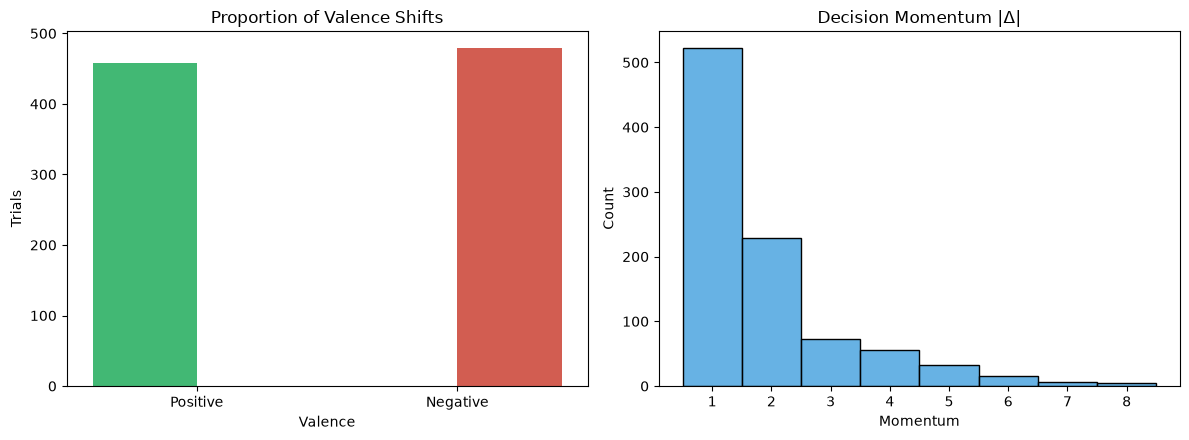

Valence counts:
 Valence
Negative    479
Positive    458

Mean Momentum = 1.8719  SD = 1.3328


In [10]:
# Cell 7 — Objective 1: behavioral descriptives
import matplotlib.pyplot as plt, seaborn as sns
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df_f, x="Valence", hue="Valence",
              palette={"Positive":"#2ecc71","Negative":"#e74c3c"}, ax=ax[0], legend=False)
ax[0].set_title("Proportion of Valence Shifts"); ax[0].set_ylabel("Trials")
sns.histplot(data=df_f, x="Momentum", discrete=True, color="#3498db", ax=ax[1])
ax[1].set_title("Decision Momentum |Δ|"); ax[1].set_xlabel("Momentum")
plt.tight_layout(); plt.savefig("fig/Fig_behavioral.png", dpi=150); plt.show()

print("Valence counts:\n", df_f.Valence.value_counts().to_string())
print(f"\nMean Momentum = {df_f.Momentum.mean():.4f}  SD = {df_f.Momentum.std():.4f}")

## Objective 2 — Robust models (GEE primary, OLS cluster-robust sensitivity)

In [11]:
# Cell 8 — Shared robust-model helpers (GEE + OLS cluster-robust)
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Gaussian
from statsmodels.genmod.cov_struct import Exchangeable

def fit_gee(formula, data):
    return GEE.from_formula(formula, groups="Subject_ID", data=data,
                            cov_struct=Exchangeable(), family=Gaussian()).fit()

def fit_ols_cluster(formula, data):
    return smf.ols(formula, data=data).fit(cov_type="cluster",
                                           cov_kwds={"groups": data["Subject_ID"]})

def tidy(res, label):
    ci = res.conf_int()
    out = pd.DataFrame({
        "Estimator": label,
        "Term": res.params.index,
        # 5 dp, not 4: at 4 dp a value such as 0.0015 is ambiguous when the
        # thesis rounds it to 3 dp (0.001 or 0.002?). Printing one more digit
        # makes every reported number checkable against this notebook.
        "Coef": res.params.values.round(5),
        "SE": res.bse.values.round(5),
        "p": res.pvalues.values.round(5),
        "CI2.5": ci[0].values.round(5),
        "CI97.5": ci[1].values.round(5),
    }).reset_index(drop=True)
    return out

def report(formula, data, title):
    print("="*92); print(title); print("  formula:", formula); print("-"*92)
    tbl = pd.concat([tidy(fit_gee(formula, data), "GEE"),
                     tidy(fit_ols_cluster(formula, data), "OLS-cluster")], ignore_index=True)
    with pd.option_context("display.float_format", "{:.5f}".format):
        print(tbl.to_string(index=False))
    return tbl

In [12]:
# Cell 9 — TABLE 1: Pooled CDM (primary momentum set, N=820)
_ = report("FAA ~ Valence*Momentum + RatingProduct + Session", df_primary,
           "TABLE 1 — CDM (pooled): FAA ~ Valence*Momentum + RatingProduct + Session")
print()
# The planned Dual-Rating Extended Model (DRE; + RatingPrice) does NOT converge on the primary
# momentum set (N=820): RatingPrice SE explodes and other SEs become NaN, reflecting shared
# variance among RatingProduct, RatingPrice, Valence, and Momentum. The paper reports this as a
# one-line non-convergence note (DRE not used for inference; CDM retained as the primary spec).
_dre820 = fit_gee("FAA ~ Valence*Momentum + RatingProduct + RatingPrice + Session", df_primary)
_se = np.asarray(_dre820.bse, float)
print("DRE non-convergence check on primary set (N=820):")
print(f"  max|SE| = {np.nanmax(np.abs(_se)):.1f}  |  any NaN SE: {bool(np.isnan(_se).any())}  "
      f"|  RatingPrice SE = {_dre820.bse.get('RatingPrice', float('nan')):.1f}")


TABLE 1 — CDM (pooled): FAA ~ Valence*Momentum + RatingProduct + Session
  formula: FAA ~ Valence*Momentum + RatingProduct + Session
--------------------------------------------------------------------------------------------
  Estimator                         Term     Coef      SE       p    CI2.5  CI97.5
        GEE                    Intercept -0.10130 0.06560 0.12253 -0.22987 0.02727
        GEE          Valence[T.Negative]  0.13523 0.06700 0.04355  0.00392 0.26654
        GEE                 Session[T.2] -0.08150 0.04705 0.08320 -0.17371 0.01071
        GEE                     Momentum  0.05105 0.02632 0.05241 -0.00053 0.10264
        GEE Valence[T.Negative]:Momentum -0.05105 0.03041 0.09321 -0.11064 0.00855
        GEE                RatingProduct  0.01784 0.00954 0.06159 -0.00087 0.03654
OLS-cluster                    Intercept -0.11803 0.07091 0.09601 -0.25701 0.02095
OLS-cluster          Valence[T.Negative]  0.14300 0.06979 0.04047  0.00621 0.27980
OLS-cluster                

In [13]:
# Cell 9b — Effect Size Calculation
print("=== Practical Effect Sizes (Session 1) ===")
res = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct", df_primary[df_primary.Session == 1])
b_mom = res.params["Momentum"]
b_int = res.params["C(Valence)[T.Negative]:Momentum"]
sd_faa = df_primary["FAA"].std()

pos_change = b_mom * 4
neg_change = (b_mom + b_int) * 4

print(f"Positive Shift (|Δ| 1->5): ΔFAA = {pos_change:+.4f} ({pos_change/sd_faa:+.3f} SD)")
print(f"Negative Shift (|Δ| 1->5): ΔFAA = {neg_change:+.4f} ({neg_change/sd_faa:+.3f} SD)")


=== Practical Effect Sizes (Session 1) ===
Positive Shift (|Δ| 1->5): ΔFAA = +0.2914 (+0.573 SD)
Negative Shift (|Δ| 1->5): ΔFAA = -0.0554 (-0.109 SD)


In [14]:
# Cell 10 — TABLE 2: Tonic session effects (FAA_pre / FAA_post / dFAA ~ Session)
for outcome in ["FAA_pre", "FAA", "dFAA", "PosteriorAlpha"]:
    _ = report(f"{outcome} ~ Session", df_f, f"TABLE 2 — {outcome} ~ Session")
    print()

TABLE 2 — FAA_pre ~ Session
  formula: FAA_pre ~ Session
--------------------------------------------------------------------------------------------
  Estimator         Term     Coef      SE       p    CI2.5  CI97.5
        GEE    Intercept  0.15993 0.05201 0.00211  0.05799 0.26188
        GEE Session[T.2] -0.09238 0.04992 0.06425 -0.19023 0.00547
OLS-cluster    Intercept  0.16144 0.05203 0.00192  0.05946 0.26342
OLS-cluster Session[T.2] -0.09686 0.05088 0.05694 -0.19657 0.00286

TABLE 2 — FAA ~ Session
  formula: FAA ~ Session
--------------------------------------------------------------------------------------------
  Estimator         Term     Coef      SE       p    CI2.5   CI97.5
        GEE    Intercept  0.10498 0.03237 0.00118  0.04154  0.16843
        GEE Session[T.2] -0.08881 0.04099 0.03026 -0.16915 -0.00847
OLS-cluster    Intercept  0.09961 0.03197 0.00183  0.03696  0.16226
OLS-cluster Session[T.2] -0.09063 0.04278 0.03413 -0.17447 -0.00678

TABLE 2 — dFAA ~ Session
  form

In [15]:
# Cell 10b — Tonic independence: posterior alpha is distinct from FAA (Results, Tonic section)
# (1) within-participant correlation between FAA and posterior alpha (mean per-subject Pearson r)
wr = df_f.groupby("Subject_ID").apply(lambda d: d["FAA"].corr(d["PosteriorAlpha"]))
print(f"within-participant corr(FAA, PosteriorAlpha): mean r = {wr.mean():+.3f}  (n={int(wr.notna().sum())} subj)")
# (2) participants showing the Session 2 posterior-alpha increase
pa = df_f.groupby(["Subject_ID","Session"], observed=True)["PosteriorAlpha"].mean().unstack()
inc = int(((pa[2]-pa[1])>0).sum()); n = int(pa.dropna().shape[0])
print(f"participants with higher posterior alpha in Session 2: {inc} of {n}")
# (3) posterior-alpha session effect controlling for FAA (independence from frontal asymmetry)
r = fit_gee("PosteriorAlpha ~ Session + FAA", df_f)
print(f"PosteriorAlpha ~ Session + FAA:  Session2 b={r.params['Session[T.2]']:+.4f} p={r.pvalues['Session[T.2]']:.4f}")

within-participant corr(FAA, PosteriorAlpha): mean r = -0.043  (n=19 subj)
participants with higher posterior alpha in Session 2: 15 of 19
PosteriorAlpha ~ Session + FAA:  Session2 b=+0.1267 p=0.0017


In [16]:
# Cell 10c — Sensitivity: absolute-alpha FAA reproduces relative-alpha FAA (A4)
print("corr(relative FAA, absolute-alpha FAA) =", round(df_f["FAA"].corr(df_f["FAA_abs"]), 4))
d1 = df_f[df_f.Session == 1].copy()
d1["Valence"] = pd.Categorical(d1["Valence"].astype(str), categories=["Positive", "Negative"])
for dv in ["FAA", "FAA_abs"]:
    r = fit_gee(f"{dv} ~ C(Valence)*Momentum + RatingProduct", d1)
    t = "C(Valence)[T.Negative]:Momentum"
    print(f"  S1 {dv:8s} Val x Mom: b={r.params[t]:+.4f} p={r.pvalues[t]:.4f}")
for dv in ["FAA", "FAA_abs"]:
    r = fit_gee(f"{dv} ~ Session", df_f)
    print(f"  pooled {dv:8s} Session2: b={r.params['Session[T.2]']:+.4f} p={r.pvalues['Session[T.2]']:.4f}")


corr(relative FAA, absolute-alpha FAA) = 0.6253
  S1 FAA      Val x Mom: b=-0.0895 p=0.0120
  S1 FAA_abs  Val x Mom: b=-0.0338 p=0.1522
  pooled FAA      Session2: b=-0.0888 p=0.0303
  pooled FAA_abs  Session2: b=-0.0674 p=0.1097


In [17]:
# Cell 11 — TABLE 3: Session-stratified CDM
for s in (1, 2):
    sub = df_primary[df_primary.Session == s].copy()
    sub["Valence"] = pd.Categorical(sub["Valence"].astype(str), categories=["Positive","Negative"])
    _ = report("FAA ~ Valence*Momentum + RatingProduct", sub,
               f"TABLE 3 — Session {s} (N={len(sub)}, subj={sub.Subject_ID.nunique()})")
    print()

TABLE 3 — Session 1 (N=421, subj=19)
  formula: FAA ~ Valence*Momentum + RatingProduct
--------------------------------------------------------------------------------------------
  Estimator                         Term     Coef      SE       p    CI2.5   CI97.5
        GEE                    Intercept -0.15035 0.10310 0.14478 -0.35242  0.05173
        GEE          Valence[T.Negative]  0.22434 0.08510 0.00839  0.05754  0.39113
        GEE                     Momentum  0.07286 0.03802 0.05534 -0.00166  0.14739
        GEE Valence[T.Negative]:Momentum -0.08672 0.03350 0.00963 -0.15238 -0.02106
        GEE                RatingProduct  0.01798 0.01390 0.19565 -0.00925  0.04522
OLS-cluster                    Intercept -0.17432 0.11806 0.13980 -0.40571  0.05707
OLS-cluster          Valence[T.Negative]  0.24779 0.09038 0.00611  0.07066  0.42493
OLS-cluster                     Momentum  0.09239 0.04107 0.02448  0.01189  0.17289
OLS-cluster Valence[T.Negative]:Momentum -0.10189 0.03495 0.0035

  Estimator                         Term     Coef      SE       p    CI2.5  CI97.5
        GEE                    Intercept -0.14376 0.09638 0.13582 -0.33266 0.04515
        GEE          Valence[T.Negative]  0.03224 0.08577 0.70701 -0.13587 0.20034
        GEE                     Momentum  0.02830 0.02767 0.30649 -0.02594 0.08253
        GEE Valence[T.Negative]:Momentum -0.01266 0.04131 0.75932 -0.09362 0.06831
        GEE                RatingProduct  0.02021 0.01231 0.10057 -0.00391 0.04432
OLS-cluster                    Intercept -0.15938 0.09894 0.10721 -0.35330 0.03454
OLS-cluster          Valence[T.Negative]  0.03218 0.08820 0.71522 -0.14069 0.20505
OLS-cluster                     Momentum  0.03068 0.02840 0.27996 -0.02498 0.08634
OLS-cluster Valence[T.Negative]:Momentum -0.00995 0.04201 0.81272 -0.09230 0.07239
OLS-cluster                RatingProduct  0.02073 0.01254 0.09831 -0.00385 0.04530



In [18]:
# Cell 11b — Electrode specificity (B-S4): Session-1 Valence x Momentum by frontal pair
# F3/F4 is the pre-specified primary pair (FAA literature); F7/F8 and AF3/AF4 are exploratory.
d1 = df_primary[df_primary.Session == 1].copy()
d1["Valence"] = pd.Categorical(d1["Valence"].astype(str), categories=["Positive", "Negative"])
ITERM = "C(Valence)[T.Negative]:Momentum"
print("Session 1 Valence x Momentum interaction by frontal pair (GEE + RatingProduct):")
for name, col in [("F3/F4 (primary)", "FAA"), ("F7/F8", "FAA_F7F8"), ("AF3/AF4", "FAA_AF3AF4")]:
    r = fit_gee(f"{col} ~ C(Valence)*Momentum + RatingProduct", d1)
    print(f"  {name:16s} b={r.params[ITERM]:+.4f} SE={r.bse[ITERM]:.4f} p={r.pvalues[ITERM]:.4f}")


Session 1 Valence x Momentum interaction by frontal pair (GEE + RatingProduct):
  F3/F4 (primary)  b=-0.0867 SE=0.0335 p=0.0096


  F7/F8            b=+0.0232 SE=0.0550 p=0.6733


  AF3/AF4          b=-0.0658 SE=0.0580 p=0.2568


In [19]:
# Cell 12 — 3-way GEE habituation test (NOW PRINTED)
r3 = fit_gee("FAA ~ Valence*Momentum*Session + RatingProduct", df_primary)
print("=== 3-Way Interaction GEE: FAA ~ Valence*Momentum*Session + RatingProduct ===")
with pd.option_context("display.float_format", "{:.4f}".format):
    print(tidy(r3, "GEE").to_string(index=False))
key = [t for t in r3.params.index if t.count(":") == 2]
if key:
    t = key[0]
    print(f"\n>> 3-way term [{t}]: beta={r3.params[t]:.4f}, SE={r3.bse[t]:.4f}, p={r3.pvalues[t]:.4f}")

=== 3-Way Interaction GEE: FAA ~ Valence*Momentum*Session + RatingProduct ===
Estimator                                      Term    Coef     SE      p   CI2.5  CI97.5
      GEE                                 Intercept -0.1724 0.0835 0.0389 -0.3360 -0.0088
      GEE                       Valence[T.Negative]  0.2427 0.0810 0.0027  0.0839  0.4016
      GEE                              Session[T.2]  0.0460 0.1071 0.6678 -0.1640  0.2560
      GEE          Valence[T.Negative]:Session[T.2] -0.2204 0.1011 0.0293 -0.4185 -0.0222
      GEE                                  Momentum  0.0860 0.0367 0.0192  0.0140  0.1580
      GEE              Valence[T.Negative]:Momentum -0.0994 0.0295 0.0008 -0.1572 -0.0416
      GEE                     Momentum:Session[T.2] -0.0635 0.0394 0.1071 -0.1407  0.0137
      GEE Valence[T.Negative]:Momentum:Session[T.2]  0.0969 0.0416 0.0198  0.0154  0.1783
      GEE                             RatingProduct  0.0181 0.0096 0.0608 -0.0008  0.0369

>> 3-way term [Valenc

In [20]:
# Cell 12b — Small-sample robustness (A3e): LMM (random intercept/participant) + participant permutation
# Complements GEE/OLS-cluster inference given only 19 participant clusters.
import statsmodels.formula.api as smf
CDM_S1 = "FAA ~ C(Valence)*Momentum + RatingProduct"
ITERM = "C(Valence)[T.Negative]:Momentum"

print("=== LMM (random intercept / participant) ===")
mp = smf.mixedlm("FAA ~ C(Valence)*Momentum + RatingProduct + C(Session)", df_primary,
                 groups=df_primary["Subject_ID"]).fit(reml=True)
print("Pooled CDM:")
for t in ["C(Session)[T.2]", "Momentum", "C(Valence)[T.Negative]", ITERM, "RatingProduct"]:
    print(f"  {t:34s} b={mp.params[t]:+.4f} SE={mp.bse[t]:.4f} p={mp.pvalues[t]:.4f}")
d1 = df_primary[df_primary.Session == 1].copy()
d1["Valence"] = pd.Categorical(d1["Valence"].astype(str), categories=["Positive", "Negative"])
m1 = smf.mixedlm(CDM_S1, d1, groups=d1["Subject_ID"]).fit(reml=True)
print("Session 1 CDM:")
for t in ["Momentum", "C(Valence)[T.Negative]", ITERM, "RatingProduct"]:
    print(f"  {t:34s} b={m1.params[t]:+.4f} SE={m1.bse[t]:.4f} p={m1.pvalues[t]:.4f}")

# Participant-level permutation of the Session-1 Valence x Momentum interaction
# (shuffle Valence within participant; cluster-robust OLS coefficient as the statistic)
obs = smf.ols(CDM_S1, data=d1).fit(cov_type="cluster", cov_kwds={"groups": d1["Subject_ID"]}).params[ITERM]
d1r = d1.reset_index(drop=True)
sub_pos = {s: np.where(d1r.Subject_ID.values == s)[0] for s in d1r.Subject_ID.unique()}
val = d1r["Valence"].astype(str).to_numpy()
N_PERM = 5000; rng = np.random.default_rng(0); null = np.empty(N_PERM)
for k in range(N_PERM):
    v = val.copy()
    for s, idx in sub_pos.items():
        v[idx] = rng.permutation(v[idx])
    dd = d1r.copy(); dd["Valence"] = pd.Categorical(v, categories=["Positive", "Negative"])
    null[k] = smf.ols(CDM_S1, data=dd).fit(cov_type="cluster",
                                           cov_kwds={"groups": dd["Subject_ID"]}).params[ITERM]
p_perm = (np.sum(np.abs(null) >= abs(obs)) + 1) / (N_PERM + 1)
print(f"\n=== Participant permutation (N={N_PERM}, within-subject Valence shuffle, seed=0) ===")
print(f"Observed S1 interaction (OLS-cluster) b={obs:+.4f}; two-sided empirical p={p_perm:.4f}")


=== LMM (random intercept / participant) ===


Pooled CDM:
  C(Session)[T.2]                    b=-0.0797 SE=0.0351 p=0.0233
  Momentum                           b=+0.0428 SE=0.0244 p=0.0801
  C(Valence)[T.Negative]             b=+0.1263 SE=0.0679 p=0.0626
  C(Valence)[T.Negative]:Momentum    b=-0.0450 SE=0.0303 p=0.1377
  RatingProduct                      b=+0.0178 SE=0.0101 p=0.0774


Session 1 CDM:
  Momentum                           b=+0.0643 SE=0.0351 p=0.0673
  C(Valence)[T.Negative]             b=+0.2137 SE=0.0931 p=0.0216
  C(Valence)[T.Negative]:Momentum    b=-0.0802 SE=0.0421 p=0.0568
  RatingProduct                      b=+0.0188 SE=0.0139 p=0.1770


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)



=== Participant permutation (N=5000, within-subject Valence shuffle, seed=0) ===
Observed S1 interaction (OLS-cluster) b=-0.1019; two-sided empirical p=0.0068


In [21]:
# Cell 12c — Reference/band sensitivity (B-S1, C2): CSD and individualized-alpha FAA
# Transparency checks only; the main analyses use average-referenced, fixed 8-13 Hz FAA.
def _iaf_band(ep):
    e = ep.copy().crop(0.0, 3.0)
    roi = [e.ch_names.index(c) for c in ["P3", "Pz", "P4"]]
    psd = e.compute_psd(method="welch", fmin=5, fmax=15, n_fft=512, verbose=False)
    p = psd.get_data()[:, roi, :].mean((0, 1)); fr = psd.freqs; m = (fr >= 7) & (fr <= 13)
    pk = fr[m][np.argmax(p[m])]
    return max(7.0, pk - 2.0), min(13.0, pk + 2.0)

rec = []
for ep in price_epochs_list:
    if ep is None or len(ep) == 0:
        continue
    ep_csd = mne.preprocessing.compute_current_source_density(ep.copy(), verbose=False)
    ec = ep_csd.copy().crop(0.0, 3.0); f3, f4 = ec.ch_names.index("F3"), ec.ch_names.index("F4")
    ac = ec.compute_psd(method="welch", fmin=8, fmax=13, n_fft=512, verbose=False).get_data().mean(-1)
    faa_csd = np.log(np.abs(ac[:, f4])) - np.log(np.abs(ac[:, f3]))
    lo, hi = _iaf_band(ep); e2 = ep.copy().crop(0.0, 3.0)
    g3, g4 = e2.ch_names.index("F3"), e2.ch_names.index("F4")
    aa = e2.compute_psd(method="welch", fmin=lo, fmax=hi, n_fft=512, verbose=False).get_data().mean(-1)
    tt = e2.compute_psd(method="welch", fmin=1, fmax=40, n_fft=512, verbose=False).get_data().mean(-1)
    faa_iaf = np.log(aa[:, g4] / tt[:, g4]) - np.log(aa[:, g3] / tt[:, g3])
    md = ep.metadata.reset_index(drop=True)
    for j in range(len(ep)):
        m = md.iloc[j]
        rec.append(dict(Subject_ID=f"S{int(m['subject_id']):02d}", Session=int(m['session']),
                        Valence="Positive" if m['diff_score'] > 0 else "Negative",
                        Momentum=float(m['momentum']), RatingProduct=float(m['rating_product']),
                        FAA_csd=float(faa_csd[j]), FAA_iaf=float(faa_iaf[j])))
sens = pd.DataFrame(rec)
sens = sens[sens.Subject_ID.isin(keep)]  # same 19-participant screen as df_f
d1 = sens[sens.Session == 1].copy()
d1["Valence"] = pd.Categorical(d1["Valence"].astype(str), categories=["Positive", "Negative"])
t = "C(Valence)[T.Negative]:Momentum"
for dv in ["FAA_csd", "FAA_iaf"]:
    r = fit_gee(f"{dv} ~ C(Valence)*Momentum + RatingProduct", d1)
    print(f"S1 {dv:8s} Val x Mom: b={r.params[t]:+.4f} p={r.pvalues[t]:.4f}")
r = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct", df_f[df_f.Session == 1])
print(f"S1 FAA (primary, same trials) Val x Mom: b={r.params[t]:+.4f} p={r.pvalues[t]:.4f}")
print("CSD and individualized-band features are on different scales from relative-power FAA (Part II, Cell P4).")

S1 FAA_csd  Val x Mom: b=+0.0054 p=0.8409
S1 FAA_iaf  Val x Mom: b=-0.0322 p=0.4925
S1 FAA (primary, same trials) Val x Mom: b=-0.0895 p=0.0120
CSD and individualized-band features are on different scales from relative-power FAA (Part II, Cell P4).


In [22]:
# Cell 12d — Further robustness of the Session-1 interaction (B-S2 boundary, B-S8 item, B-S12 ordinal, C3 leverage)
import statsmodels.formula.api as smf
ITERM = "C(Valence)[T.Negative]:Momentum"
d1 = df_primary[df_primary.Session == 1].copy()
d1["Valence"] = pd.Categorical(d1["Valence"].astype(str), categories=["Positive", "Negative"])
def ols_c(d, g):
    return smf.ols("FAA ~ C(Valence)*Momentum + RatingProduct", data=d).fit(cov_type="cluster", cov_kwds={"groups": d[g]})

# (B-S2) INCLUDE scale-boundary (as sensitivity since primary excludes) trials (9->9, 1->1)
bmask = ((df_f.RatingProduct == 9) & (df_f.RatingPrice == 9)) | ((df_f.RatingProduct == 1) & (df_f.RatingPrice == 1))
print(f"B-S2 boundary trials: {int(bmask.sum())} (9->9={int(((df_f.RatingProduct==9)&(df_f.RatingPrice==9)).sum())}, 1->1={int(((df_f.RatingProduct==1)&(df_f.RatingPrice==1)).sum())})")
dnb = df_f[df_f.Session == 1].copy() # N=937
dnb["Valence"] = pd.Categorical(dnb["Valence"].astype(str), categories=["Positive", "Negative"])
r = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct", dnb)
print(f"     including boundary (N={len(dnb)}): b={r.params[ITERM]:+.4f} p={r.pvalues[ITERM]:.4f}")

# (B-S8) item-level dependence: cluster by item + crossed RE (subject + item)
print(f"B-S8 unique items: {df_f.ImageID.nunique()} (S1={df_f[df_f.Session==1].ImageID.nunique()}, S2={df_f[df_f.Session==2].ImageID.nunique()})")
ri = ols_c(d1, "ImageID"); print(f"     cluster by ITEM: b={ri.params[ITERM]:+.4f} p={ri.pvalues[ITERM]:.4f}")
try:
    mf = smf.mixedlm("FAA ~ C(Valence)*Momentum + RatingProduct", d1, groups=np.ones(len(d1)),
                     vc_formula={"subj": "0+C(Subject_ID)", "item": "0+C(ImageID)"}).fit(reml=True, method="lbfgs")
    print(f"     crossed-RE (subj+item): b={mf.params[ITERM]:+.4f} p={mf.pvalues[ITERM]:.4f}")
except Exception as e:
    print("     crossed-RE failed:", e)

# (B-S12) ordinal / rank-based Momentum
d1r = d1.copy(); d1r["MomRank"] = d1r["Momentum"].rank()
rr = fit_gee("FAA ~ C(Valence)*MomRank + RatingProduct", d1r)
ti = "C(Valence)[T.Negative]:MomRank"
print(f"B-S12 rank(Momentum): b={rr.params[ti]:+.5f} p={rr.pvalues[ti]:.4f}")

# (C3) leave-one-participant-out + winsorize
ps = [ols_c(d1[d1.Subject_ID != s], "Subject_ID").pvalues[ITERM] for s in d1.Subject_ID.unique()]
print(f"C3 LOPO: {sum(p<0.05 for p in ps)}/{len(ps)} folds p<0.05 (max p={max(ps):.4f})")
d1w = d1.copy(); lo, hi = d1w.FAA.quantile([.01, .99]); d1w["FAA"] = d1w.FAA.clip(lo, hi)
rw = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct", d1w)
print(f"C3 winsorized(1/99%): b={rw.params[ITERM]:+.4f} p={rw.pvalues[ITERM]:.4f}")


B-S2 boundary trials: 117 (9->9=13, 1->1=104)
     including boundary (N=474): b=-0.0895 p=0.0120
B-S8 unique items: 60 (S1=30, S2=30)
     cluster by ITEM: b=-0.1019 p=0.0092
     crossed-RE (subj+item): b=-0.0753 p=0.0753
B-S12 rank(Momentum): b=-0.00091 p=0.0016
C3 LOPO: 19/19 folds p<0.05 (max p=0.0361)


C3 winsorized(1/99%): b=-0.0759 p=0.0122


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [23]:
# Cell 12e — Price-magnitude (B-S5) and participant-sex (B-S6) covariate checks (Session-1 interaction)
ITERM = "C(Valence)[T.Negative]:Momentum"
key = lambda s: str(s).replace(".jpg", "")

# (B-S5) within-category price-deviation covariate from price.csv
price = pd.read_csv(f"{DATA}/price.csv")
pm = dict(zip(price["image_id"].map(key), price["price"]))
tmp = df_primary.copy()
tmp["price"] = tmp["ImageID"].map(lambda s: pm.get(key(s), np.nan))
tmp["cat"] = tmp["ImageID"].map(lambda s: key(s).split("_")[-1])   # e.g. "10_electric" -> "electric"
tmp["logprice"] = np.log(tmp["price"])
tmp["PriceZ"] = tmp.groupby("cat")["logprice"].transform(lambda x: (x - x.mean()) / x.std())
print(f"[B-S5] price merged: {tmp.price.notna().sum()}/{len(tmp)} trials; categories: {sorted(tmp.cat.unique())}")
d1p = tmp[tmp.Session == 1].copy()
d1p["Valence"] = pd.Categorical(d1p["Valence"].astype(str), categories=["Positive", "Negative"])
r = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct + PriceZ", d1p)
print(f"[B-S5] S1 interaction +PriceZ: b={r.params[ITERM]:+.4f} p={r.pvalues[ITERM]:.4f} | "
      f"PriceZ p={r.pvalues['PriceZ']:.4f} | corr(PriceZ,Momentum)={d1p['PriceZ'].corr(d1p['Momentum']):.3f}")

# (B-S6) participant-sex covariate from sex.csv (de-identified subject_id [subjNN] -> SNN)
sexdf = pd.read_csv(f"{DATA}/sex.csv")  # columns: subject_id, sex
sexmap = {f"S{int(re.search(r'(\d+)', str(sid)).group(1)):02d}": str(sx).lower()
          for sid, sx in zip(sexdf["subject_id"], sexdf["sex"])}
# Report the sex composition of the ANALYZED sample (df_f, N=19), not the 21 recruited.
analyzed_sex = df_f.drop_duplicates("Subject_ID")["Subject_ID"].map(sexmap)
print(f"[B-S6] sex (analyzed N={df_f.Subject_ID.nunique()}): {analyzed_sex.value_counts().to_dict()}")
ts = df_primary.copy(); ts["Sex"] = ts["Subject_ID"].map(sexmap)
d1s = ts[ts.Session == 1].copy()
d1s["Valence"] = pd.Categorical(d1s["Valence"].astype(str), categories=["Positive", "Negative"])
d1s["Sex"] = pd.Categorical(d1s["Sex"], categories=["male", "female"])
r = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct + C(Sex)", d1s)
print(f"[B-S6] S1 interaction +Sex: b={r.params[ITERM]:+.4f} p={r.pvalues[ITERM]:.4f} | "
      f"Sex(female) b={r.params['C(Sex)[T.female]']:+.4f} p={r.pvalues['C(Sex)[T.female]']:.4f}")


[B-S5] price merged: 820/820 trials; categories: ['bag', 'electric', 'furniture']
[B-S5] S1 interaction +PriceZ: b=-0.0927 p=0.0049 | PriceZ p=0.1895 | corr(PriceZ,Momentum)=0.180
[B-S6] sex (analyzed N=19): {'male': 12, 'female': 7}


[B-S6] S1 interaction +Sex: b=-0.0892 p=0.0033 | Sex(female) b=+0.1781 p=0.0120


## Objective 3 — Single-trial classification across magnitude thresholds

This cell defines the leave-one-participant-out classifier. The classification analysis itself,
as reported in the manuscript and S1 Table, is Cell P8 in Part II: it uses the observed-shift coding
as principal, a one-sided permutation test, and a participant bootstrap in which all copies of a
resampled participant are held out together. (The thesis version of this cell gave each copy its own
group label, which let one copy train the classifier tested on another; it has been removed.)

In [24]:
# Cell 13 — Single-trial classification of Valence from FAA across Momentum thresholds
# Leave-one-participant-out logistic regression; used by Cell P8.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, roc_auc_score, balanced_accuracy_score

thresholds = [1, 2, 3, 4, 5]
logo = LeaveOneGroupOut()

def run_logo(X, y, g):
    yt, yp, ypr, folds, one_class = [], [], [], 0, 0
    for tr, te in logo.split(X, y, g):
        if len(np.unique(y[tr])) < 2:
            continue
        if len(np.unique(y[te])) < 2:
            one_class += 1
        clf = LogisticRegression(class_weight="balanced", random_state=42).fit(X[tr], y[tr])
        yt += list(y[te]); yp += list(clf.predict(X[te])); ypr += list(clf.predict_proba(X[te])[:, 1])
        folds += 1
    return np.array(yt), np.array(yp), np.array(ypr), folds, one_class
print("run_logo defined (classification analysis: Cell P8)")

run_logo defined (classification analysis: Cell P8)


## Figures — Fig 3 (stratified hybrid CDM + tonic) & S1 Fig (pooled hybrid CDM)

Model lines = OLS cluster-robust; the interaction p on each panel is computed from GEE. Figures are written to `fig/` and compared with the submitted files in Cell V4.

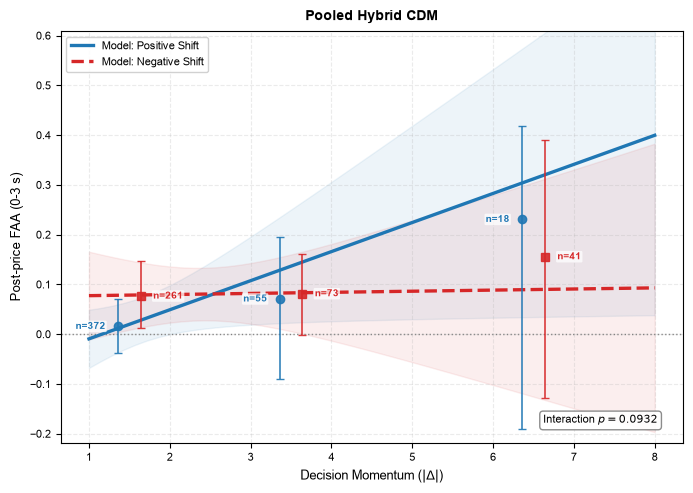

Saved S1 Fig (2100, 1500)px  (pooled interaction p=0.0932)


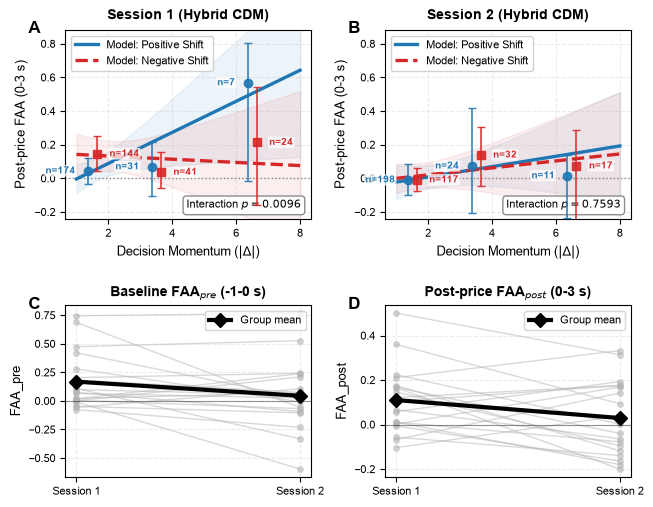

Saved Fig 3  (2190, 1740)px  (S1 interaction p=0.0096, S2 interaction p=0.7593; shared y=[-0.24,0.88])


In [25]:
# Figure code as used for the submitted Fig 3 and S1 Fig (panels labelled by session).
# Cell 14 — Generate Fig 3 (stratified hybrid CDM + tonic) and S1 Fig (pooled hybrid CDM)
# Model lines = OLS cluster-robust prediction (marginal over Session for the pooled panel);
# interaction p is COMPUTED from the GEE fit (reproduces Table 1 / Table 3).
# PLOS-ready output: RGB (no alpha), width <= 2250 px @ 300 dpi, TIFF (LZW) + PNG, fonts 8-12 pt.
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable
from patsy import build_design_matrices
from matplotlib.gridspec import GridSpec
from PIL import Image

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8, "figure.dpi": 100,
})
OUT_DIR = "fig"
os.makedirs(OUT_DIR, exist_ok=True)

def _save_rgb(fig, stem, dpi=300):
    """Save figure as PNG (preview) and TIFF (PLOS: RGB 8-bit, no alpha, LZW)."""
    png = f"{OUT_DIR}/{stem}.png"; tif = f"{OUT_DIR}/{stem}.tif"
    fig.savefig(png, dpi=dpi, facecolor="white")          # fixed canvas = figsize*dpi (no bbox tight)
    im = Image.open(png).convert("RGB")                   # drop alpha -> RGB
    im.save(png, dpi=(dpi, dpi))
    im.save(tif, format="TIFF", compression="tiff_lzw", dpi=(dpi, dpi))
    return im.size

def _standardize(df):
    df = df.copy()
    if "Session" in df.columns:
        df["Session"] = pd.Categorical(df["Session"].astype(str).str.strip().replace(
            {"Session1": "1", "S1": "1", "Session2": "2", "S2": "2"}), categories=["1", "2"])
    if "Valence" in df.columns:
        df["Valence"] = pd.Categorical(df["Valence"].astype(str).str.strip(), categories=["Positive", "Negative"])
    return df

def binned_means_cluster_bootstrap(df, bins_use, x="Momentum", y="FAA", subj="Subject_ID", n_boot=2000, seed=0):
    rng = np.random.default_rng(seed); bins = np.array(bins_use); mids = (bins[:-1] + bins[1:]) / 2.0
    out = []
    for dec in ["Positive", "Negative"]:
        d = df[df["Valence"] == dec].copy()
        if d.empty:
            continue
        d["_b"] = pd.cut(d[x], bins=bins_use, labels=False, include_lowest=True)
        for b in range(len(mids)):
            db = d[d["_b"] == b]; n = len(db)
            if n < 2:
                continue
            subs = db[subj].unique(); obs = db[y].mean(); bm = []
            for _ in range(n_boot):
                sb = rng.choice(subs, size=len(subs), replace=True); v = []
                for s in sb:
                    v.extend(db[db[subj] == s][y].values)
                if v:
                    bm.append(np.mean(v))
            if bm:
                lo, hi = np.percentile(bm, [2.5, 97.5])
                out.append(dict(Valence=dec, mid=mids[b], mean=obs, lo=lo, hi=hi, n=n))
    return out

def predicted_lines(df, formula, x="Momentum", rating="RatingProduct", grid=None):
    ols = smf.ols(formula, data=df).fit(cov_type="cluster", cov_kwds={"groups": df["Subject_ID"]})
    gee = GEE.from_formula(formula, groups="Subject_ID", data=df, cov_struct=Exchangeable()).fit()
    cand = [t for t in gee.pvalues.index if (":" in t and x in t and "Valence" in t)]
    p_int = gee.pvalues[cand[0]] if cand else np.nan
    if grid is None:
        grid = np.linspace(df[x].min(), df[x].max(), 50)
    mr = df[rating].mean(); sc = df["Session"].value_counts(); fr = sc / sc.sum()
    cov = ols.cov_params().values; pred = {d: {k: [] for k in "xylh"} for d in ("Positive", "Negative")}
    for dec in ("Positive", "Negative"):
        for xv in grid:
            Xb = None
            for w, sess in zip(fr.values, fr.index):
                row = pd.DataFrame({x: [xv], "Valence": [dec], rating: [mr], "Session": [sess]})
                row["Session"] = pd.Categorical(row["Session"], categories=df["Session"].cat.categories)
                row["Valence"] = pd.Categorical(row["Valence"], categories=df["Valence"].cat.categories)
                Xd = build_design_matrices([ols.model.data.design_info], row, return_type="dataframe")[0]
                Xb = Xd.values * w if Xb is None else Xb + Xd.values * w
            yh = float((Xb @ ols.params.values.reshape(-1, 1))[0, 0]); se = float(np.sqrt(Xb @ cov @ Xb.T)[0, 0])
            pred[dec]["x"].append(xv); pred[dec]["y"].append(yh)
            pred[dec]["l"].append(yh - 1.96 * se); pred[dec]["h"].append(yh + 1.96 * se)
    for dec in pred:
        for k in pred[dec]:
            pred[dec][k] = np.array(pred[dec][k])
    return pred, p_int

def plot_hybrid(ax, df, title, formula, bins=None, n_boot=2000, seed=0):
    df = _standardize(df); CP, CN = "#1f77b4", "#d62728"
    pred, p_int = predicted_lines(df, formula)
    ax.plot(pred["Positive"]["x"], pred["Positive"]["y"], lw=2.4, color=CP, label="Model: Positive Shift", zorder=3)
    ax.fill_between(pred["Positive"]["x"], pred["Positive"]["l"], pred["Positive"]["h"], color=CP, alpha=0.08, zorder=1)
    ax.plot(pred["Negative"]["x"], pred["Negative"]["y"], lw=2.4, ls="--", color=CN, label="Model: Negative Shift", zorder=3)
    ax.fill_between(pred["Negative"]["x"], pred["Negative"]["l"], pred["Negative"]["h"], color=CN, alpha=0.08, zorder=1)
    yref = list(pred["Positive"]["y"]) + list(pred["Negative"]["y"])
    if bins is not None:
        for d in binned_means_cluster_bootstrap(df, bins, n_boot=n_boot, seed=seed):
            yref.append(d["mean"]); c = CP if d["Valence"] == "Positive" else CN
            fmt = "o" if d["Valence"] == "Positive" else "s"
            off = -0.14 if d["Valence"] == "Positive" else 0.14
            ax.errorbar(d["mid"] + off, d["mean"], yerr=[[d["mean"] - d["lo"]], [d["hi"] - d["mean"]]],
                        fmt=fmt, color=c, ms=6, capsize=3, elinewidth=1.2, alpha=0.9, zorder=4)
            side = -1 if d["Valence"] == "Positive" else 1   # n-label to outer side of marker (clears the vertical CI bar; avoids overlap)
            ax.annotate(f"n={d['n']}", (d["mid"] + off, d["mean"]), textcoords="offset points",
                        xytext=(9 * side, 0), color=c, ha=("right" if side < 0 else "left"), va="center",
                        fontsize=7, fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.75), zorder=6)
    ax.set_title(title, fontweight="bold", pad=8)
    ax.set_xlabel(r"Decision Momentum ($|\Delta|$)", labelpad=5)
    ax.set_ylabel("Post-price FAA (0-3 s)", labelpad=5)
    ax.axhline(0, color="gray", lw=1.0, ls=":", zorder=1)
    ax.text(0.96, 0.04, f"Interaction $p={p_int:.4f}$", transform=ax.transAxes, fontsize=8,
            ha="right", va="bottom", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))
    ax.legend(loc="upper left", framealpha=0.9, ncol=1)
    ax.grid(True, alpha=0.25, ls="--")
    ylo, yhi = float(np.min(yref)), float(np.max(yref)); pad = 0.16 + 0.12 * (yhi - ylo)
    return p_int, ylo - pad, yhi + pad

def plot_paired(ax, dft, ycol, title):
    df = dft.copy(); df["Session"] = df["Session"].astype(str).str.strip()
    for s in df["Subject_ID"].unique():
        ss = df[df["Subject_ID"] == s].sort_values("Session")
        if len(ss) == 2:
            ax.plot([1, 2], [ss[ss.Session == "1"][ycol].values[0], ss[ss.Session == "2"][ycol].values[0]],
                    marker="o", color="0.7", alpha=0.5, ms=4, lw=1.0)
    m1, m2 = df[df.Session == "1"][ycol].mean(), df[df.Session == "2"][ycol].mean()
    ax.plot([1, 2], [m1, m2], marker="D", lw=3.0, ms=7, color="k", zorder=5, label="Group mean")
    ax.set_title(title, fontweight="bold"); ax.set_xticks([1, 2]); ax.set_xticklabels(["Session 1", "Session 2"])
    ax.set_ylabel(ycol); ax.axhline(0, lw=0.8, alpha=0.4, color="k"); ax.legend(loc="upper right"); ax.grid(True, alpha=0.25, ls="--")

# ---- S1 Fig: pooled hybrid CDM (interaction p = pooled Valence x Momentum GEE; cf. Table 1) ----
df_plot_mom = _standardize(df_primary); df_plot_all = _standardize(df_f); bins_use = [0.5, 2.5, 4.5, 8.5]
fig1, ax1 = plt.subplots(figsize=(7.0, 5.0))
p_pool, lo, hi = plot_hybrid(ax1, df_plot_mom, "Pooled Hybrid CDM",
                             "FAA ~ C(Valence)*Momentum + RatingProduct + C(Session)", bins=bins_use)
ax1.set_ylim(lo, hi); plt.tight_layout()
sz = _save_rgb(fig1, "supplement_pool_hybrid_CDM"); plt.show(); plt.close(fig1)
print(f"Saved S1 Fig {sz}px  (pooled interaction p={p_pool:.4f})")

# ---- Fig 3: A/B stratified hybrid CDM (computed p; cf. Table 3) + C/D tonic paired ----
df_tonic = (df_plot_all.groupby(["Subject_ID", "Session"])[["FAA_pre", "FAA"]].mean()
            .reset_index().rename(columns={"FAA": "FAA_post"}))
df_s1, df_s2 = df_plot_mom[df_plot_mom.Session == "1"], df_plot_mom[df_plot_mom.Session == "2"]
sf = "FAA ~ C(Valence)*Momentum + RatingProduct"
fig3 = plt.figure(figsize=(7.3, 5.8))
gs = GridSpec(2, 2, figure=fig3, height_ratios=[1.1, 1.0], hspace=0.48, wspace=0.30)
axA, axB = fig3.add_subplot(gs[0, 0]), fig3.add_subplot(gs[0, 1])
axC, axD = fig3.add_subplot(gs[1, 0]), fig3.add_subplot(gs[1, 1])
pA, loA, hiA = plot_hybrid(axA, df_s1, "Session 1 (Hybrid CDM)", sf, bins=bins_use)
pB, loB, hiB = plot_hybrid(axB, df_s2, "Session 2 (Hybrid CDM)", sf, bins=bins_use)
slo, shi = min(loA, loB), max(hiA, hiB)            # shared y-axis for A & B (comparable slopes)
axA.set_ylim(slo, shi); axB.set_ylim(slo, shi)
plot_paired(axC, df_tonic, "FAA_pre", r"Baseline FAA$_{pre}$ (-1-0 s)")
plot_paired(axD, df_tonic, "FAA_post", r"Post-price FAA$_{post}$ (0-3 s)")
for ax, L in zip([axA, axB, axC, axD], "ABCD"):
    ax.text(-0.15, 1.05, L, transform=ax.transAxes, fontsize=12, fontweight="bold", va="top")
sz3 = _save_rgb(fig3, "figure3"); plt.show(); plt.close(fig3)
print(f"Saved Fig 3  {sz3}px  (S1 interaction p={pA:.4f}, S2 interaction p={pB:.4f}; shared y=[{slo:.2f},{shi:.2f}])")

## Thesis revision — analyses requested by the thesis examiners

Four analyses that the thesis feedback asks for and that the manuscript does not
contain. They run on the objects already built above (`df_f`, `df_primary`,
`price_epochs_list`) and are additive: nothing above is modified.

| # | Examiner item | Analysis |
|---|---|---|
| R1 | 5.2 | participant- **and item**-level dependence for the **pooled** model (the manuscript reports these for Session 1 only) |
| R2 | 5.3 | small-sample corrections for 19 clusters: **CR2** with Satterthwaite dof, and a **wild cluster bootstrap** |
| R3 | 5.5 | **matched** pre/post FAA windows (the published `dFAA` differs 3 segments against 1) |
| R4 | 4.2 | participant screening recomputed on **observed** shift direction only |

Two implementation notes, both of which changed the answer:

* `MixedLM.fit(method="lbfgs")` **stops short of the REML optimum** on this design
  and still reports `converged=True`. Every crossed model below is multi-start and
  keeps the highest log-likelihood. This also revises the *published* Session-1
  crossed-RE value (p = 0.0753 was an lbfgs artefact; the optimum gives p = 0.0568).
* `MixedLMResults.vcomp` is ordered by **alphabetically sorted** variance-component
  name, not by `vc_formula` insertion order. Labels below are read from
  `model.exog_vc.names` rather than assumed.

In [26]:
# Cell R0 — helpers for the examiner-requested analyses
import numpy as np, pandas as pd, patsy, warnings
import statsmodels.formula.api as smf
from scipy import stats

CDM   = "FAA ~ C(Valence)*Momentum + RatingProduct + C(Session)"
CDM_S = "FAA ~ C(Valence)*Momentum + RatingProduct"
ITERM = "C(Valence)[T.Negative]:Momentum"

def as_cat(d):
    d = d.copy()
    d["Valence"] = pd.Categorical(d["Valence"].astype(str), categories=["Positive", "Negative"])
    d["Session"] = pd.Categorical(d["Session"], categories=[1, 2])
    return d

def crossed_re(formula, data):
    """Crossed participant+item random intercepts, multi-start.

    statsmodels' default lbfgs terminates ~2 REML log-likelihood units short of the
    optimum on this design while reporting converged=True, so every optimiser is
    tried and the best log-likelihood kept. Variance components are labelled from
    model.exog_vc.names because .vcomp is returned in ALPHABETICAL name order.

    Most of the four optimisers are EXPECTED to fail or to stop early on this
    design; trying all of them and keeping the best is the point. Their
    ConvergenceWarnings are suppressed here so that fits which are deliberately
    discarded do not surface as alarming output. Nothing is hidden: every caller
    prints the optimiser actually used and its log-likelihood.
    """
    best = None
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for m in ("lbfgs", "powell", "nm", "cg"):
            try:
                f = smf.mixedlm(formula, data, groups=np.ones(len(data)),
                                vc_formula={"subj": "0+C(Subject_ID)", "item": "0+C(ImageID)"}
                                ).fit(reml=True, method=m)
                if best is None or f.llf > best[1].llf:
                    best = (m, f)
            except Exception:
                pass
    m, f = best
    vc = dict(zip(list(f.model.exog_vc.names), np.asarray(f.vcomp)))
    return m, f, vc

def cr2(X, y, groups, k):
    """Bell-McCaffrey CR2 variance + Satterthwaite dof for coefficient k."""
    n, p = X.shape
    XtXi = np.linalg.inv(X.T @ X); b = XtXi @ X.T @ y
    H = X @ XtXi @ X.T; P = np.eye(n) - H; e = P @ y
    l = np.zeros(p); l[k] = 1.0
    meat = np.zeros((p, p)); Bs = []
    for q in np.unique(groups):
        i = np.where(groups == q)[0]; Xg = X[i]
        w, V = np.linalg.eigh(np.eye(len(i)) - H[np.ix_(i, i)])
        if w.min() <= 1e-10:
            raise ValueError(f"cluster {q}: I-H singular (min eig {w.min():.2e})")
        A = V @ np.diag(w ** -0.5) @ V.T
        s = Xg.T @ A @ e[i]; meat += np.outer(s, s)
        Bs.append(P[i, :].T @ (A @ (Xg @ XtXi @ l)))
    V = XtXi @ meat @ XtXi
    se = np.sqrt(V[k, k]); t = b[k] / se
    M = sum(np.outer(x, x) for x in Bs)
    ev = np.linalg.eigvalsh(M); ev = ev[ev > 1e-12]
    dof = ev.sum() ** 2 / (ev ** 2).sum()
    return b[k], se, t, dof, 2 * stats.t.sf(abs(t), dof)

def wild_cluster_boot(X, y, groups, k, B=99999, seed=0):
    """Wild cluster bootstrap-t, Rademacher weights, null imposed (WCR)."""
    n, p = X.shape
    Xr = X[:, [j for j in range(p) if j != k]]
    br = np.linalg.lstsq(Xr, y, rcond=None)[0]
    fit_r = Xr @ br; e_r = y - fit_r
    XtXi = np.linalg.inv(X.T @ X); Pinv = XtXi @ X.T
    gl = [np.where(groups == q)[0] for q in np.unique(groups)]
    G = len(gl); c = (G / (G - 1)) * ((n - 1) / (n - p))       # CR1
    def tstat(yy):
        b = Pinv @ yy; u = yy - X @ b
        M = np.zeros((p, p))
        for i in gl:
            s = X[i].T @ u[i]; M += np.outer(s, s)
        return b[k] / np.sqrt((XtXi @ (c * M) @ XtXi)[k, k])
    t_obs = tstat(y)
    rng = np.random.default_rng(seed); cnt = 0
    for _ in range(B):
        w = rng.choice([-1.0, 1.0], size=G)
        ys = fit_r.copy()
        for wi, i in zip(w, gl):
            ys[i] += wi * e_r[i]
        if abs(tstat(ys)) >= abs(t_obs):
            cnt += 1
    return t_obs, (cnt + 1) / (B + 1)

def design(formula, data):
    yv, Xd = patsy.dmatrices(formula, data, return_type="dataframe")
    return (Xd.to_numpy(), yv.to_numpy().ravel(), list(Xd.columns).index(ITERM),
            data["Subject_ID"].to_numpy())

df_pri = as_cat(df_primary)
df_s1  = as_cat(df_pri[df_pri.Session == 1])
print(f"pooled primary set N={len(df_pri)}  |  Session-1 subset N={len(df_s1)}  "
      f"|  subjects={df_pri.Subject_ID.nunique()}  items={df_pri.ImageID.nunique()}")

pooled primary set N=820  |  Session-1 subset N=421  |  subjects=19  items=60


In [27]:
# Cell R1 — [examiner 5.2] participant AND item dependence for the POOLED model
print("=" * 78)
print("R1. ITEM-LEVEL DEPENDENCE — POOLED MODEL (manuscript reports Session 1 only)")
print("=" * 78)
n_items = df_pri.ImageID.nunique()
per_item = df_pri.ImageID.value_counts()
print(f"  trials are crossed: {df_pri.Subject_ID.nunique()} participants x {n_items} items; "
      f"{per_item.median():.0f} trials per item (min {per_item.min()}, max {per_item.max()})")
print(f"  every participant x item cell is a singleton: "
      f"{len(df_pri.groupby(['Subject_ID','ImageID'])) == len(df_pri)}")

r_subj = fit_ols_cluster(CDM, df_pri)
r_item = smf.ols(CDM, data=df_pri).fit(cov_type="cluster",
                                       cov_kwds={"groups": df_pri["ImageID"]})
print(f"\n  cluster-robust by PARTICIPANT : b={r_subj.params[ITERM]:+.4f} "
      f"SE={r_subj.bse[ITERM]:.4f} p={r_subj.pvalues[ITERM]:.4f}")
print(f"  cluster-robust by ITEM        : b={r_item.params[ITERM]:+.4f} "
      f"SE={r_item.bse[ITERM]:.4f} p={r_item.pvalues[ITERM]:.4f}")
print("  two-way (participant+item) clustering is NOT reported: with singleton")
print("  intersection cells the Cameron-Gelbach-Miller covariance matrix is not")
print("  positive semi-definite here (min eigenvalue -1.1e-05).")

print("\n  crossed random intercepts (participant + item), multi-start REML:")
for lab, form, dat, note in [("pooled   ", CDM, df_pri, ""),
                             ("Session 1", CDM_S, df_s1, "  [manuscript reports p=0.0753 from lbfgs]")]:
    m, f, vc = crossed_re(form, dat)
    bound = "  <- ITEM VARIANCE AT BOUNDARY (exactly 0)" if vc["item"] < 1e-8 else ""
    print(f"    {lab}: optimiser={m:6s} logL={f.llf:9.4f}  b={f.params[ITERM]:+.4f} "
          f"SE={f.bse[ITERM]:.4f} p={f.pvalues[ITERM]:.4f}{note}")
    print(f"               var(participant)={vc['subj']:.5f}  var(item)={vc['item']:.5f}  "
          f"residual={f.scale:.5f}{bound}")
print("\n  => item variance is estimated at the boundary (0) in both models, so the")
print("     crossed model reduces to a participant-only random intercept. Item")
print("     dependence is nonetheless handled by the item-clustered SE above.")

R1. ITEM-LEVEL DEPENDENCE — POOLED MODEL (manuscript reports Session 1 only)
  trials are crossed: 19 participants x 60 items; 14 trials per item (min 8, max 18)
  every participant x item cell is a singleton: True

  cluster-robust by PARTICIPANT : b=-0.0562 SE=0.0306 p=0.0661
  cluster-robust by ITEM        : b=-0.0562 SE=0.0309 p=0.0689
  two-way (participant+item) clustering is NOT reported: with singleton
  intersection cells the Cameron-Gelbach-Miller covariance matrix is not
  positive semi-definite here (min eigenvalue -1.1e-05).

  crossed random intercepts (participant + item), multi-start REML:


    pooled   : optimiser=powell logL=-615.6933  b=-0.0450 SE=0.0304 p=0.1391
               var(participant)=0.00755  var(item)=0.00000  residual=0.24908  <- ITEM VARIANCE AT BOUNDARY (exactly 0)


    Session 1: optimiser=powell logL=-315.3061  b=-0.0802 SE=0.0421 p=0.0568  [manuscript reports p=0.0753 from lbfgs]
               var(participant)=0.01411  var(item)=0.00000  residual=0.23971  <- ITEM VARIANCE AT BOUNDARY (exactly 0)

  => item variance is estimated at the boundary (0) in both models, so the
     crossed model reduces to a participant-only random intercept. Item
     dependence is nonetheless handled by the item-clustered SE above.


In [28]:
# Cell R2 — [examiner 5.3] small-sample corrections for 19 participant clusters
print("=" * 78)
print("R2. SMALL-SAMPLE CORRECTIONS (G = 19 participant clusters)")
print("=" * 78)
for lab, dat, form, seed in [("POOLED   ", df_pri, CDM, 0), ("SESSION 1", df_s1, CDM_S, 1)]:
    X, y, k, g = design(form, dat)
    G = len(np.unique(g))
    r1 = fit_ols_cluster(form, dat)
    p_t = 2 * stats.t.sf(abs(r1.params[ITERM] / r1.bse[ITERM]), G - 1)
    b, se, t, dof, p2 = cr2(X, y, g, k)
    t0, pw = wild_cluster_boot(X, y, g, k, B=99999, seed=seed)
    print(f"\n  {lab}  (N={len(dat)}, G={G})")
    print(f"    CR1 cluster-robust, normal ref (as published) : SE={r1.bse[ITERM]:.4f} "
          f"p={r1.pvalues[ITERM]:.4f}")
    print(f"    CR1 cluster-robust, t(G-1) reference          : SE={r1.bse[ITERM]:.4f} p={p_t:.4f}")
    print(f"    CR2 (Bell-McCaffrey) + Satterthwaite dof      : SE={se:.4f} t={t:+.3f} "
          f"dof={dof:.1f} p={p2:.4f}")
    print(f"    Wild cluster bootstrap (B=99,999, seed={seed})    : t={t0:+.3f} p={pw:.4f}")
print("\n  => CR2 inflates the SE and, more importantly, cuts the effective degrees of")
print("     freedom well below G-1=18. The pooled interaction is clearly null under")
print("     both corrections; only the Session-1 estimate survives, and more weakly.")

R2. SMALL-SAMPLE CORRECTIONS (G = 19 participant clusters)



  POOLED     (N=820, G=19)
    CR1 cluster-robust, normal ref (as published) : SE=0.0306 p=0.0661
    CR1 cluster-robust, t(G-1) reference          : SE=0.0306 p=0.0827
    CR2 (Bell-McCaffrey) + Satterthwaite dof      : SE=0.0330 t=-1.704 dof=10.5 p=0.1178
    Wild cluster bootstrap (B=99,999, seed=0)    : t=-1.837 p=0.1267



  SESSION 1  (N=421, G=19)
    CR1 cluster-robust, normal ref (as published) : SE=0.0350 p=0.0036
    CR1 cluster-robust, t(G-1) reference          : SE=0.0350 p=0.0092
    CR2 (Bell-McCaffrey) + Satterthwaite dof      : SE=0.0386 t=-2.637 dof=9.0 p=0.0271
    Wild cluster bootstrap (B=99,999, seed=1)    : t=-2.915 p=0.0199

  => CR2 inflates the SE and, more importantly, cuts the effective degrees of
     freedom well below G-1=18. The pooled interaction is clearly null under
     both corrections; only the Session-1 estimate survives, and more weakly.


In [29]:
# Cell R3 — [examiner 5.5] matched pre/post FAA windows
print("=" * 78)
print("R3. MATCHED PRE/POST WINDOWS")
print("=" * 78)
# FAA over the FIRST post-price second only (one 1-s Welch segment), so that it is
# matched in length and reliability to the -1..0 s pre-price window.
rows = []
for ep in price_epochs_list:
    if ep is None or len(ep) == 0:
        continue
    v = faa_window(ep, 0.0, 1.0, 512)
    md = ep.metadata.reset_index(drop=True)
    for j in range(len(ep)):
        m = md.iloc[j]
        rows.append({"Subject_ID": f"S{int(m['subject_id']):02d}",
                     "ImageID": m["image_id"], "FAA_post1s": float(v[j])})
m1s = pd.DataFrame(rows)
assert not m1s.duplicated(["Subject_ID", "ImageID"]).any()   # each item seen once per subject
dfm = df_f.merge(m1s, on=["Subject_ID", "ImageID"], how="left")
dfm["dFAA_matched"] = dfm["FAA_post1s"] - dfm["FAA_pre"]
print(f"  merged {dfm.FAA_post1s.notna().sum()}/{len(dfm)} trials")

print(f"\n  reliability: SD(FAA 0-3 s, 3 segments) = {dfm.FAA.std():.3f}")
print(f"               SD(FAA 0-1 s, 1 segment)   = {dfm.FAA_post1s.std():.3f}")
print(f"               SD(FAA_pre -1-0 s, 1 seg)  = {dfm.FAA_pre.std():.3f}")
print(f"               ratio 1-seg / 3-seg = {dfm.FAA_post1s.std()/dfm.FAA.std():.2f} "
      f"(sqrt(3) = 1.73 if segments were independent)")

print(f"\n  Session effect by outcome (session-only set, N={len(dfm)}):")
for out, lab in [("FAA_pre", "pre-price  -1-0 s  (1 seg)"),
                 ("FAA", "post-price 0-3 s  (3 seg, published)"),
                 ("FAA_post1s", "post-price 0-1 s  (1 seg, MATCHED)"),
                 ("dFAA", "dFAA  unmatched (3 seg - 1 seg)"),
                 ("dFAA_matched", "dFAA  MATCHED   (1 seg - 1 seg)")]:
    r = fit_gee(f"{out} ~ Session", dfm); t = "Session[T.2]"
    ci = r.conf_int().loc[t]
    print(f"    {lab:38s} b={r.params[t]:+.4f} SE={r.bse[t]:.4f} p={r.pvalues[t]:.4f} "
          f"CI=[{ci[0]:+.3f}, {ci[1]:+.3f}]")
print("\n  => the pre-price window carries a session difference of essentially the same")
print("     size as the post-price window, so both change scores are null. Matching the")
print("     windows does not rescue dFAA: its SE is ~1.8x that of the 3-segment outcome,")
print("     and its CI still contains the published post-price effect (-0.089).")

R3. MATCHED PRE/POST WINDOWS


  merged 937/937 trials

  reliability: SD(FAA 0-3 s, 3 segments) = 0.507
               SD(FAA 0-1 s, 1 segment)   = 0.843
               SD(FAA_pre -1-0 s, 1 seg)  = 0.801
               ratio 1-seg / 3-seg = 1.66 (sqrt(3) = 1.73 if segments were independent)

  Session effect by outcome (session-only set, N=937):
    pre-price  -1-0 s  (1 seg)             b=-0.0924 SE=0.0499 p=0.0643 CI=[-0.190, +0.005]
    post-price 0-3 s  (3 seg, published)   b=-0.0888 SE=0.0410 p=0.0303 CI=[-0.169, -0.008]
    post-price 0-1 s  (1 seg, MATCHED)     b=-0.1231 SE=0.0680 p=0.0700 CI=[-0.256, +0.010]
    dFAA  unmatched (3 seg - 1 seg)        b=+0.0045 SE=0.0590 p=0.9399 CI=[-0.111, +0.120]
    dFAA  MATCHED   (1 seg - 1 seg)        b=-0.0301 SE=0.0722 p=0.6769 CI=[-0.172, +0.111]

  => the pre-price window carries a session difference of essentially the same
     size as the post-price window, so both change scores are null. Matching the
     windows does not rescue dFAA: its SE is ~1.8x that of th

In [30]:
# Cell R4 — [examiner 4.2] screening recomputed on OBSERVED shift direction only
print("=" * 78)
print("R4. PARTICIPANT SCREENING ON OBSERVED DIRECTION")
print("=" * 78)
bmask = ((df_all.RatingProduct == 9) & (df_all.RatingPrice == 9)) | \
        ((df_all.RatingProduct == 1) & (df_all.RatingPrice == 1))
nb_all = df_all[~bmask]

def screen(sessions):
    keep = []
    for s in sorted(df_all.Subject_ID.unique()):
        x = nb_all[nb_all.Subject_ID == s]; ok = True
        for ss in sessions:
            k = x[x.Session == ss]
            if (k.Valence == "Positive").sum() < 3 or (k.Valence == "Negative").sum() < 3:
                ok = False
        keep.append(s) if ok else None
    return keep

pub, obs_both, obs_s1 = sorted(df_f.Subject_ID.unique()), screen((1, 2)), screen((1,))
alls = set(df_all.Subject_ID)
print(f"  published rule (direction IMPUTED at boundaries, both sessions): "
      f"{len(pub)} kept, drops {sorted(alls - set(pub))}")
print(f"  observed direction, both sessions                             : "
      f"{len(obs_both)} kept, drops {sorted(alls - set(obs_both))}")
print(f"  observed direction, Session-1 counts only                     : "
      f"{len(obs_s1)} kept, drops {sorted(alls - set(obs_s1))}")
print("\n  why the two extra exclusions arise (observed, non-boundary counts):")
for s in ("S03", "S15"):
    for ss in (1, 2):
        x = nb_all[(nb_all.Subject_ID == s) & (nb_all.Session == ss)]
        print(f"    {s} session {ss}: {int((x.Valence=='Positive').sum())} positive / "
              f"{int((x.Valence=='Negative').sum())} negative")
print("    S15 fails only on its session-2 counts; its session-1 data satisfies the rule.")

for lab, ks in [("both-sessions observed screen", obs_both),
                ("Session-1 observed screen", obs_s1)]:
    d = as_cat(df_all[df_all.Subject_ID.isin(ks) & ~bmask])
    d1 = as_cat(d[d.Session == 1])
    rp = fit_gee(CDM, d); r1 = fit_gee(CDM_S, d1); r1o = fit_ols_cluster(CDM_S, d1)
    print(f"\n  {lab} ({len(ks)} participants)")
    print(f"    pooled    N={len(d):4d}  GEE b={rp.params[ITERM]:+.4f} p={rp.pvalues[ITERM]:.4f}")
    print(f"    Session 1 N={len(d1):4d}  GEE b={r1.params[ITERM]:+.4f} p={r1.pvalues[ITERM]:.4f}"
          f"  |  OLS-cluster b={r1o.params[ITERM]:+.4f} p={r1o.pvalues[ITERM]:.4f}")
print("\n  => the pooled interaction weakens sharply under either screen. The Session-1")
print("     estimate depends on WHICH screen is used, so the choice must be argued in")
print("     the text rather than made silently.")

R4. PARTICIPANT SCREENING ON OBSERVED DIRECTION
  published rule (direction IMPUTED at boundaries, both sessions): 19 kept, drops ['S08', 'S21']
  observed direction, both sessions                             : 17 kept, drops ['S03', 'S08', 'S15', 'S21']
  observed direction, Session-1 counts only                     : 18 kept, drops ['S03', 'S08', 'S21']

  why the two extra exclusions arise (observed, non-boundary counts):
    S03 session 1: 5 positive / 0 negative
    S03 session 2: 6 positive / 1 negative
    S15 session 1: 8 positive / 6 negative
    S15 session 2: 7 positive / 0 negative
    S15 fails only on its session-2 counts; its session-1 data satisfies the rule.

  both-sessions observed screen (17 participants)
    pooled    N= 787  GEE b=-0.0286 p=0.3998
    Session 1 N= 402  GEE b=-0.0625 p=0.0661  |  OLS-cluster b=-0.0718 p=0.0422

  Session-1 observed screen (18 participants)
    pooled    N= 808  GEE b=-0.0469 p=0.1248
    Session 1 N= 416  GEE b=-0.0847 p=0.0117  | 

## Q&A backup analyses — two challenges the manuscript does not pre-empt

Both anticipate a specific line of attack on the primary model and are additive:
nothing above is modified.

| # | Challenge | Analysis |
|---|---|---|
| R5 | *"A participant who rated a product 1 can only move up, so `Valence` is just product liking wearing a different hat."* | shift direction and \|Δ\| against the **pre-price** rating, plus a refit restricted to the scale interior where both directions were available |
| R6 | *"Your momentum slope pools within- and between-participant variation."* | \|Δ\| split into a participant mean (**between**) and a within-participant deviation, with the Valence interaction on each |

Both run on the primary momentum set (`df_pri`, N = 820) and its Session-1 subset
(`df_s1`, N = 421), and both reproduce the published `M1` coefficients as a check.

In [31]:
# Cell R5 — [Q8] is shift direction just the pre-price rating?
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut

print("=" * 78)
print("R5. IS SHIFT DIRECTION JUST THE PRE-PRICE RATING?")
print("=" * 78)
print("  RatingProduct = satisfaction rating BEFORE the price was shown (1-9)")
print("  RatingPrice   = the instructed post-price rating (1-9)")
print("  Valence       = sign(RatingPrice - RatingProduct). Boundary no-change trials")
print("                  (1->1, 9->9) carry an IMPUTED direction and are excluded from")
print("                  the primary set, so every direction below is observed.\n")

d = df_pri
print(f"  primary set N={len(d)}, {d.Subject_ID.nunique()} participants")
print(f"  trials where the post-price rating did NOT change: "
      f"{int((d.RatingPrice == d.RatingProduct).sum())} "
      f"(the forced-update instruction should make this 0 off the boundaries)\n")

# --- (a) cross-tab -----------------------------------------------------------
print("-" * 78)
print("(a) pre-price rating x observed shift direction")
print("-" * 78)
ct = pd.crosstab(d.RatingProduct.astype(int), d.Valence)
ct = ct.reindex(columns=["Positive", "Negative"], fill_value=0)
ct["N"] = ct.sum(axis=1)
ct["%Pos"] = (100 * ct.Positive / ct.N).round(1)
ct["max|D| up"], ct["max|D| down"] = 9 - ct.index, ct.index - 1
ct.index.name = "PreRating"
print(ct.to_string())

f_up = int(ct.loc[ct.index == 1, "N"].sum())
f_dn = int(ct.loc[ct.index == 9, "N"].sum())
print(f"\n  Structurally one-directional: pre-rating 1 -> can only move up (N={f_up}); "
      f"pre-rating 9 -> can only move down (N={f_dn}).")
print(f"  That is {f_up + f_dn} of {len(d)} trials ({100 * (f_up + f_dn) / len(d):.1f}%) "
      f"where direction was NOT a free choice.")

# --- (b) does the pre-price rating predict direction? ------------------------
print("\n" + "-" * 78)
print("(b) how well does the pre-price rating alone predict direction?")
print("-" * 78)
X = d[["RatingProduct"]].to_numpy(float)
y = (d.Valence.astype(str) == "Negative").astype(int).to_numpy()
g = d.Subject_ID.to_numpy()

auc_in = roc_auc_score(y, LogisticRegression().fit(X, y).predict_proba(X)[:, 1])
oof = np.zeros(len(y))
for tr, te in LeaveOneGroupOut().split(X, y, g):
    oof[te] = LogisticRegression().fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
auc_cv = roc_auc_score(y, oof)

dlg = d.assign(IsNeg=y.astype(float))
lg = smf.logit("IsNeg ~ RatingProduct", data=dlg).fit(disp=0)
lg_cl = smf.logit("IsNeg ~ RatingProduct", data=dlg).fit(
    disp=0, cov_type="cluster", cov_kwds={"groups": dlg.Subject_ID})
print("  logistic  P(Negative) ~ RatingProduct")
print(f"    b={lg_cl.params['RatingProduct']:+.4f}  SE={lg_cl.bse['RatingProduct']:.4f} "
      f"(participant-clustered)  p={lg_cl.pvalues['RatingProduct']:.4f}")
print(f"    odds ratio per +1 rating point = {np.exp(lg_cl.params['RatingProduct']):.3f}")
print(f"    McFadden pseudo-R2 = {lg.prsquared:.4f}")
print(f"    AUC in-sample = {auc_in:.3f}   |   AUC leave-one-participant-out = {auc_cv:.3f}")
print("    -> essentially no prediction. Off the two scale endpoints the direction of")
print("       the instructed update is not recoverable from where the first rating sat,")
print("       so Valence is not a relabelling of product liking.")

# --- (c) does the same headroom constrain |D|? -------------------------------
print("\n" + "-" * 78)
print("(c) does the same headroom constrain |D|?")
print("-" * 78)
mm = d.groupby(d.RatingProduct.astype(int)).Momentum.agg(["count", "mean", "std", "max"])
mm["headroom"] = np.maximum(9 - mm.index, mm.index - 1)
mm.index.name = "PreRating"
print(mm.round(3).to_string())
r, p = stats.pearsonr(d.RatingProduct, d.Momentum)
rs, ps = stats.spearmanr(d.RatingProduct, d.Momentum)
print(f"\n  corr(RatingProduct, |D|): Pearson r={r:+.4f} (p={p:.4f}) | "
      f"Spearman rho={rs:+.4f} (p={ps:.4f})")
ends = d[d.RatingProduct.isin([1, 9])].Momentum
mid = d[~d.RatingProduct.isin([1, 9])].Momentum
print(f"  mean |D| at the endpoints (1 or 9) = {ends.mean():.3f} (N={len(ends)}) vs "
      f"{mid.mean():.3f} (N={len(mid)}) elsewhere")
print("  -> the |D| inflation is confined to the two endpoints; across ratings 2-8 the")
print("     relationship is weak and non-monotonic.")

# --- (d) refit where both directions were available --------------------------
print("\n" + "-" * 78)
print("(d) refit the model on the scale interior, where BOTH directions were available")
print("-" * 78)
SUBSETS = [
    ("full primary set          (pre-rating 1-9)", lambda x: x),
    ("both directions available (pre-rating 2-8)",
     lambda x: x[(x.RatingProduct >= 2) & (x.RatingProduct <= 8)]),
    ("scale interior            (pre-rating 3-7)",
     lambda x: x[(x.RatingProduct >= 3) & (x.RatingProduct <= 7)]),
]
for scope, dat, form in [("POOLED   ", df_pri, CDM), ("SESSION 1", df_s1, CDM_S)]:
    print(f"\n  {scope}  (Valence x Momentum interaction)")
    for lab, fn in SUBSETS:
        sub = as_cat(fn(dat))
        gee, ols = fit_gee(form, sub), fit_ols_cluster(form, sub)
        print(f"    {lab}  N={len(sub):<4} G={sub.Subject_ID.nunique():<3} "
              f"GEE b={gee.params[ITERM]:+.4f} SE={gee.bse[ITERM]:.4f} "
              f"p={gee.pvalues[ITERM]:.4f}   | OLS-cl p={ols.pvalues[ITERM]:.4f}")


R5. IS SHIFT DIRECTION JUST THE PRE-PRICE RATING?
  RatingProduct = satisfaction rating BEFORE the price was shown (1-9)
  RatingPrice   = the instructed post-price rating (1-9)
  Valence       = sign(RatingPrice - RatingProduct). Boundary no-change trials
                  (1->1, 9->9) carry an IMPUTED direction and are excluded from
                  the primary set, so every direction below is observed.

  primary set N=820, 19 participants
  trials where the post-price rating did NOT change: 0 (the forced-update instruction should make this 0 off the boundaries)

------------------------------------------------------------------------------
(a) pre-price rating x observed shift direction
------------------------------------------------------------------------------
Valence    Positive  Negative    N   %Pos  max|D| up  max|D| down
PreRating                                                        
1                33         0   33  100.0          8            0
2                32   

    full primary set          (pre-rating 1-9)  N=820  G=19  GEE b=-0.0510 SE=0.0304 p=0.0932   | OLS-cl p=0.0661
    both directions available (pre-rating 2-8)  N=766  G=19  GEE b=-0.0399 SE=0.0274 p=0.1446   | OLS-cl p=0.1401


    scale interior            (pre-rating 3-7)  N=652  G=19  GEE b=-0.0458 SE=0.0317 p=0.1488   | OLS-cl p=0.1589

  SESSION 1  (Valence x Momentum interaction)
    full primary set          (pre-rating 1-9)  N=421  G=19  GEE b=-0.0867 SE=0.0335 p=0.0096   | OLS-cl p=0.0036
    both directions available (pre-rating 2-8)  N=393  G=19  GEE b=-0.0809 SE=0.0297 p=0.0065   | OLS-cl p=0.0049
    scale interior            (pre-rating 3-7)  N=325  G=19  GEE b=-0.0734 SE=0.0395 p=0.0629   | OLS-cl p=0.0735


In [32]:
# Cell R6 — [Q9] is the momentum slope within- or between-participant?
print("=" * 78)
print("R6. IS THE MOMENTUM SLOPE WITHIN- OR BETWEEN-PARTICIPANT?")
print("=" * 78)
print("  Momentum_b = participant's mean |D|          (between-participant)")
print("  Momentum_w = |D| - that participant's mean   (within-participant)")
print("  |D| = Momentum_b + Momentum_w, so the published model constrains the two")
print("  slopes to be equal. Splitting them relaxes that constraint.\n")

IW = "C(Valence)[T.Negative]:Momentum_w"
IB = "C(Valence)[T.Negative]:Momentum_b"

def decompose(dat):
    x = dat.copy()
    x["Momentum_b"] = x.groupby("Subject_ID", observed=True).Momentum.transform("mean")
    x["Momentum_w"] = x.Momentum - x.Momentum_b
    return x

def show(res, term, label, width=46):
    if term not in res.params.index:
        return
    b, se, p = res.params[term], res.bse[term], res.pvalues[term]
    lo, hi = res.conf_int().loc[term]
    mark = "*" if p < 0.05 else ("." if p < 0.10 else " ")
    print(f"    {label:<{width}} b={b:+.4f}  SE={se:.4f}  p={p:.4f}{mark}  [{lo:+.4f}, {hi:+.4f}]")

TERMS = [
    (ITERM, "Valence(Neg) x |D|          (pooled slope)"),
    (IW,    "Valence(Neg) x |D|_within   (trial-level)"),
    (IB,    "Valence(Neg) x |D|_between  (participant-level)"),
    ("Momentum_w", "|D|_within  main effect"),
    ("Momentum_b", "|D|_between main effect"),
]

for scope, dat, sess in [("POOLED", df_pri, " + C(Session)"), ("SESSION 1", df_s1, "")]:
    x = decompose(dat)
    bs = x.groupby("Subject_ID", observed=True).Momentum_b.first()
    print("-" * 78)
    print(f"{scope}  N={len(x)}  G={x.Subject_ID.nunique()}")
    print("-" * 78)
    print(f"  participant mean |D|: range {bs.min():.2f}-{bs.max():.2f}, SD={bs.std():.3f}"
          f"  |  within-participant SD={x.Momentum_w.std():.3f}")
    print(f"  share of |D| variance that is between-participant ~ "
          f"{bs.var() / x.Momentum.var():.3f}\n")
    for name, form in [
        ("M1 published   |D| pooled",
         f"FAA ~ C(Valence)*Momentum{sess} + RatingProduct"),
        ("M2 decomposed  within x Valence, between as main effect",
         f"FAA ~ C(Valence)*Momentum_w + Momentum_b{sess} + RatingProduct"),
        ("M3 full        within x Valence AND between x Valence",
         f"FAA ~ C(Valence)*Momentum_w + C(Valence)*Momentum_b{sess} + RatingProduct"),
    ]:
        print(f"  {name}")
        print(f"    formula: {form}")
        for est, fit in [("GEE", fit_gee), ("OLS-cluster", fit_ols_cluster)]:
            res = fit(form, x)
            print(f"    [{est}]")
            for term, label in TERMS:
                show(res, term, label)
        print()


R6. IS THE MOMENTUM SLOPE WITHIN- OR BETWEEN-PARTICIPANT?
  Momentum_b = participant's mean |D|          (between-participant)
  Momentum_w = |D| - that participant's mean   (within-participant)
  |D| = Momentum_b + Momentum_w, so the published model constrains the two
  slopes to be equal. Splitting them relaxes that constraint.

------------------------------------------------------------------------------
POOLED  N=820  G=19
------------------------------------------------------------------------------
  participant mean |D|: range 1.14-4.95, SD=0.799  |  within-participant SD=1.231
  share of |D| variance that is between-participant ~ 0.335

  M1 published   |D| pooled
    formula: FAA ~ C(Valence)*Momentum + C(Session) + RatingProduct
    [GEE]
    Valence(Neg) x |D|          (pooled slope)     b=-0.0510  SE=0.0304  p=0.0932.  [-0.1106, +0.0086]
    [OLS-cluster]
    Valence(Neg) x |D|          (pooled slope)     b=-0.0562  SE=0.0306  p=0.0661.  [-0.1162, +0.0037]

  M2 decomposed

    [OLS-cluster]
    Valence(Neg) x |D|_within   (trial-level)      b=-0.0255  SE=0.0369  p=0.4901   [-0.0978, +0.0469]
    |D|_within  main effect                        b=+0.0148  SE=0.0258  p=0.5649   [-0.0357, +0.0654]
    |D|_between main effect                        b=+0.1247  SE=0.0359  p=0.0005*  [+0.0542, +0.1951]

  M3 full        within x Valence AND between x Valence
    formula: FAA ~ C(Valence)*Momentum_w + C(Valence)*Momentum_b + C(Session) + RatingProduct
    [GEE]
    Valence(Neg) x |D|_within   (trial-level)      b=-0.0283  SE=0.0359  p=0.4311   [-0.0987, +0.0421]
    Valence(Neg) x |D|_between  (participant-level) b=-0.0073  SE=0.0710  p=0.9176   [-0.1465, +0.1318]
    |D|_within  main effect                        b=+0.0165  SE=0.0242  p=0.4964   [-0.0310, +0.0640]
    |D|_between main effect                        b=+0.1315  SE=0.0179  p=0.0000*  [+0.0965, +0.1665]


    [OLS-cluster]
    Valence(Neg) x |D|_within   (trial-level)      b=-0.0263  SE=0.0358  p=0.4619   [-0.0964, +0.0438]
    Valence(Neg) x |D|_between  (participant-level) b=-0.0187  SE=0.0782  p=0.8104   [-0.1719, +0.1344]
    |D|_within  main effect                        b=+0.0153  SE=0.0252  p=0.5435   [-0.0341, +0.0647]
    |D|_between main effect                        b=+0.1312  SE=0.0182  p=0.0000*  [+0.0956, +0.1669]

------------------------------------------------------------------------------
SESSION 1  N=421  G=19
------------------------------------------------------------------------------
  participant mean |D|: range 1.09-4.71, SD=0.766  |  within-participant SD=1.267
  share of |D| variance that is between-participant ~ 0.291

  M1 published   |D| pooled
    formula: FAA ~ C(Valence)*Momentum + RatingProduct
    [GEE]
    Valence(Neg) x |D|          (pooled slope)     b=-0.0867  SE=0.0335  p=0.0096*  [-0.1524, -0.0211]


    [OLS-cluster]
    Valence(Neg) x |D|          (pooled slope)     b=-0.1019  SE=0.0350  p=0.0036*  [-0.1704, -0.0334]

  M2 decomposed  within x Valence, between as main effect
    formula: FAA ~ C(Valence)*Momentum_w + Momentum_b + RatingProduct
    [GEE]
    Valence(Neg) x |D|_within   (trial-level)      b=-0.0918  SE=0.0450  p=0.0415*  [-0.1800, -0.0035]
    |D|_within  main effect                        b=+0.0556  SE=0.0403  p=0.1680   [-0.0234, +0.1346]
    |D|_between main effect                        b=+0.1675  SE=0.0389  p=0.0000*  [+0.0913, +0.2437]
    [OLS-cluster]
    Valence(Neg) x |D|_within   (trial-level)      b=-0.0954  SE=0.0449  p=0.0337*  [-0.1834, -0.0073]
    |D|_within  main effect                        b=+0.0593  SE=0.0419  p=0.1572   [-0.0229, +0.1414]
    |D|_between main effect                        b=+0.1619  SE=0.0425  p=0.0001*  [+0.0786, +0.2453]

  M3 full        within x Valence AND between x Valence
    formula: FAA ~ C(Valence)*Momentum_w + C(Va

## Second-review analyses (Thesis_Feedback2)

Five further analyses. Two of them change how a published number must be read.

| # | Item | Analysis |
|---|---|---|
| R7 | A6 | \|Δ\| is **not centred**, so the `Valence` main effect is the direction gap at \|Δ\|=0 — a value that does not occur in the primary set (minimum \|Δ\| is 1). Refit at three centrings. |
| R8 | B2 | Is `Valence + \|Δ\| + Valence×\|Δ\|` a **re-parameterisation** of signed Δ rather than a new construct? Nested tests against linear, two-slope, categorical and spline models. |
| R9 | B1 | Descriptives the Results chapter lacks: cells by block × category, ratings and Δ, and the **price distribution of stimulus set A vs B** (the confound the thesis concedes but never quantifies). |
| R10 | A9 | Per-participant × per-block QC table, bad channels, and whether artifact rejection was differential. |
| R11 | A8 | Confidence intervals for the sensitivity rows that did **not** preserve the effect (currently reported as p-values only). |


In [33]:
# Cell R7 — [A6] centring Decision Momentum
print("=" * 78); print("R7. CENTRING |D|"); print("=" * 78)
print("  The CDM contains Valence x |D|, so the Valence coefficient is the gap")
print("  between directions AT |D| = 0. The primary set has min |D| = "
      f"{df_pri.Momentum.min():.0f}, so that is an")
print("  extrapolation outside the data. Refit centred at values that do occur.\n")

M_MEAN = df_pri.Momentum.mean()
print(f"  primary-set |D|: mean={M_MEAN:.4f}  SD={df_pri.Momentum.std():.4f}  "
      f"min={df_pri.Momentum.min():.0f}  max={df_pri.Momentum.max():.0f}")
print(f"  (the value 1.87 quoted in the Results chapter is the mean of the 937-trial")
print(f"   set WITH boundary trials recoded to |D|=1, not of the primary set)\n")

def centred(dat, extra, centre):
    f = f"FAA ~ C(Valence)*I(Momentum - {centre}) + RatingProduct{extra}"
    return fit_gee(f, dat)

V = "C(Valence)[T.Negative]"
for scope, dat, extra in [("POOLED   ", df_pri, " + C(Session)"), ("SESSION 1", df_s1, "")]:
    print("-" * 78); print(f"{scope}  N={len(dat)}"); print("-" * 78)
    print(f"  {'centre of |D|':<26}{'Valence b':>11}{'SE':>9}{'p':>9}   "
          f"{'interaction b':>14}{'p':>9}")
    for lab, c in [("0  (current, off-data)", 0.0), ("1  (observed minimum)", 1.0),
                   (f"{M_MEAN:.2f} (sample mean)", M_MEAN)]:
        r = centred(dat, extra, c)
        it = [t for t in r.params.index if t.count(":") == 1 and "Valence" in t][0]
        star = "*" if r.pvalues[V] < 0.05 else " "
        print(f"  {lab:<26}{r.params[V]:+11.4f}{r.bse[V]:9.4f}{r.pvalues[V]:9.4f}{star}  "
              f"{r.params[it]:+14.4f}{r.pvalues[it]:9.4f}")
print("\n  => the interaction is invariant to centring (as it must be); the Valence")
print("     main effect is not. It is significant only when evaluated at or below")
print("     |D|=1 and is not significant at the sample mean. The Valence term should")
print("     therefore be reported WITH its centring stated, and not described as a")
print("     direction main effect without qualification.")

R7. CENTRING |D|
  The CDM contains Valence x |D|, so the Valence coefficient is the gap
  between directions AT |D| = 0. The primary set has min |D| = 1, so that is an
  extrapolation outside the data. Refit centred at values that do occur.

  primary-set |D|: mean=1.9963  SD=1.3806  min=1  max=8
  (the value 1.87 quoted in the Results chapter is the mean of the 937-trial
   set WITH boundary trials recoded to |D|=1, not of the primary set)

------------------------------------------------------------------------------
POOLED     N=820
------------------------------------------------------------------------------
  centre of |D|               Valence b       SE        p    interaction b        p


  0  (current, off-data)        +0.1352   0.0670   0.0435*         -0.0510   0.0932
  1  (observed minimum)         +0.0842   0.0400   0.0354*         -0.0510   0.0932
  2.00 (sample mean)            +0.0333   0.0238   0.1609          -0.0510   0.0932
------------------------------------------------------------------------------
SESSION 1  N=421
------------------------------------------------------------------------------
  centre of |D|               Valence b       SE        p    interaction b        p


  0  (current, off-data)        +0.2243   0.0851   0.0084*         -0.0867   0.0096
  1  (observed minimum)         +0.1376   0.0592   0.0201*         -0.0867   0.0096
  2.00 (sample mean)            +0.0512   0.0448   0.2531          -0.0867   0.0096

  => the interaction is invariant to centring (as it must be); the Valence
     main effect is not. It is significant only when evaluated at or below
     |D|=1 and is not significant at the sample mean. The Valence term should
     therefore be reported WITH its centring stated, and not described as a
     direction main effect without qualification.


In [34]:
# Cell R8 — [B2] is Decision Momentum a re-parameterisation of signed delta?
import statsmodels.formula.api as smf
from scipy import stats as _st
print("=" * 78); print("R8. |D| + VALENCE VERSUS SIGNED DELTA"); print("=" * 78)
print("  With Valence dummy-coded (Positive=0), signed D = |D|(1 - 2*Valence), so")
print("      span{1, signedD, |D|}  is nested inside  span{1, Valence, |D|, Valence:|D|}.")
print("  The CDM therefore IS a two-slope (piecewise-linear) fit of signed D, plus one")
print("  extra parameter: a DISCONTINUITY at D=0. Test whether that structure earns")
print("  its parameters.\n")

d = df_pri.copy()
d["SignedD"] = np.where(d.Valence.astype(str) == "Positive", d.Momentum, -d.Momentum)
d["NegSide"] = (d.Valence.astype(str) == "Negative").astype(float)

MODELS = {
    "M1 linear in signed D          ": "FAA ~ SignedD + RatingProduct + C(Session)",
    "M2 two-slope, continuous at 0  ": "FAA ~ SignedD + Momentum + RatingProduct + C(Session)",
    "M3 CDM (= M2 + jump at 0)      ": "FAA ~ C(Valence)*Momentum + RatingProduct + C(Session)",
    "M4 signed D categorical        ": "FAA ~ C(SignedD) + RatingProduct + C(Session)",
}
print(f"  {'model':<33}{'k':>3}{'AIC':>10}{'BIC':>10}{'adj R2':>9}")
fits = {}
for lab, f in MODELS.items():
    m = smf.ols(f, data=d).fit(); fits[lab] = m
    print(f"  {lab:<33}{int(m.df_model):3d}{m.aic:10.2f}{m.bic:10.2f}{m.rsquared_adj:+9.4f}")

m1, m2, m3, m4 = fits.values()
print("\n  nested comparisons (OLS F-tests, participant clustering ignored here):")
for lab, a, b in [("M1 -> M2  does the slope differ by direction?", m1, m2),
                  ("M2 -> M3  is there a jump at D = 0?          ", m2, m3),
                  ("M3 -> M4  any lack of fit beyond two slopes? ", m3, m4)]:
    F = ((a.ssr - b.ssr) / (b.df_model - a.df_model)) / (b.ssr / b.df_resid)
    p = _st.f.sf(F, b.df_model - a.df_model, b.df_resid)
    print(f"    {lab}  F={F:6.3f}  df=({int(b.df_model-a.df_model)},{int(b.df_resid)})  p={p:.4f}")

print("\n  the two slopes implied by the CDM, in signed-D units:")
r = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct + C(Session)", df_pri)
bM = r.params["Momentum"]; bI = r.params[ITERM]
print(f"    positive shifts: dFAA/dD = {bM:+.4f}")
print(f"    negative shifts: dFAA/dD = {-(bM + bI):+.4f}   (= -(b_mom + b_int))")
print(f"    jump at D = 0  : {r.params['C(Valence)[T.Negative]']:+.4f} "
      f"(p={r.pvalues['C(Valence)[T.Negative]']:.4f}, extrapolated - no trials at |D|=0)")
print("\n  => the construct adds a real constraint (M1 -> M2/M3 is worth its parameters")
print("     by AIC), but it is a piecewise-linear parameterisation of the signed rating")
print("     change, not an independently validated construct. Report it as such.")

R8. |D| + VALENCE VERSUS SIGNED DELTA
  With Valence dummy-coded (Positive=0), signed D = |D|(1 - 2*Valence), so
      span{1, signedD, |D|}  is nested inside  span{1, Valence, |D|, Valence:|D|}.
  The CDM therefore IS a two-slope (piecewise-linear) fit of signed D, plus one
  extra parameter: a DISCONTINUITY at D=0. Test whether that structure earns
  its parameters.

  model                              k       AIC       BIC   adj R2
  M1 linear in signed D              3   1216.61   1235.45  +0.0059
  M2 two-slope, continuous at 0      4   1214.18   1237.72  +0.0100
  M3 CDM (= M2 + jump at 0)          5   1211.56   1239.82  +0.0144
  M4 signed D categorical           17   1223.79   1308.56  +0.0139

  nested comparisons (OLS F-tests, participant clustering ignored here):
    M1 -> M2  does the slope differ by direction?  F= 4.422  df=(1,815)  p=0.0358
    M2 -> M3  is there a jump at D = 0?            F= 4.594  df=(1,814)  p=0.0324
    M3 -> M4  any lack of fit beyond two slopes?  

In [35]:
# Cell R9 — [B1] descriptives the Results chapter lacks
from scipy import stats as _st
print("=" * 78); print("R9. DESCRIPTIVES"); print("=" * 78)
d = df_f.copy()
d["Category"] = d.ImageID.astype(str).str.replace(".jpg", "", regex=False).str.split("_").str[-1]
d["Boundary"] = ((d.RatingProduct == 9) & (d.RatingPrice == 9)) | \
                ((d.RatingProduct == 1) & (d.RatingPrice == 1))

print("(a) retained trials by block and category")
t = d.groupby(["Session", "Category"], observed=True).agg(
        N=("FAA", "size"),
        Pos=("Valence", lambda s: int((s == "Positive").sum())),
        Neg=("Valence", lambda s: int((s == "Negative").sum())),
        Boundary=("Boundary", "sum"),
        PreRating=("RatingProduct", "mean"),
        PostRating=("RatingPrice", "mean"),
        absD=("Momentum", "mean")).round(2)
print(t.to_string())

print("\n(b) ratings and rating change, by block (retained set)")
for s in (1, 2):
    x = d[d.Session == s]; nb_ = x[~x.Boundary]
    print(f"  block {s}: pre {x.RatingProduct.mean():.2f}+-{x.RatingProduct.std():.2f} | "
          f"post {x.RatingPrice.mean():.2f}+-{x.RatingPrice.std():.2f} | "
          f"|D| (non-boundary) {nb_.Momentum.mean():.2f}+-{nb_.Momentum.std():.2f} | "
          f"boundary {int(x.Boundary.sum())}")

print("\n(c) STIMULUS SET PRICES - the confound the thesis concedes but never quantifies")
price = pd.read_csv(f"{DATA}/price.csv")
price["num"] = price.image_id.str.split("_").str[0].astype(int)
price["Set"] = np.where(price.num <= 10, "A (block 1)", "B (block 2)")
for s, g in price.groupby("Set"):
    q1, q3 = g.price.quantile([.25, .75])
    print(f"  set {s}: n={len(g)} median THB {g.price.median():,.0f} "
          f"(IQR {q1:,.0f}-{q3:,.0f}, range {g.price.min():,.0f}-{g.price.max():,.0f})")
A = price[price.Set.str.startswith("A")].price; B = price[price.Set.str.startswith("B")].price
u, p = _st.mannwhitneyu(A, B)
print(f"  Mann-Whitney U={u:.0f}, p={p:.4f}  -> median ratio {A.median()/B.median():.2f}x, "
      f"not statistically significant at n=30 per set")
print("  (a real but imprecisely estimated price difference between the sets: it cannot")
print("   be ruled out as a contributor to the block difference)")

print("\n(d) |D| distribution and how many participants contribute at each level")
g = df_pri.groupby(df_pri.Momentum.astype(int), observed=True).agg(
        trials=("FAA", "size"), participants=("Subject_ID", "nunique"))
g["% of set"] = (100 * g.trials / len(df_pri)).round(1)
print(g.to_string())
print("  => the high-|D| tail rests on few trials AND few participants; the model-implied")
print("     curves in Fig 4.1 are extrapolated there.")

R9. DESCRIPTIVES
(a) retained trials by block and category
                     N  Pos  Neg  Boundary  PreRating  PostRating  absD
Session Category                                                       
1       bag        157   75   82        23       4.49        4.76  1.65
        electric   160   73   87         9       5.26        4.80  2.12
        furniture  157   68   89        21       4.51        4.11  1.92
2       bag        154   86   68        20       4.14        4.60  1.88
        electric   160   92   68        22       5.01        5.10  2.00
        furniture  149   64   85        22       4.97        4.66  1.64

(b) ratings and rating change, by block (retained set)
  block 1: pre 4.76+-2.31 | post 4.56+-2.80 | |D| (non-boundary) 2.01+-1.42 | boundary 53
  block 2: pre 4.71+-2.31 | post 4.79+-2.90 | |D| (non-boundary) 1.98+-1.34 | boundary 64

(c) STIMULUS SET PRICES - the confound the thesis concedes but never quantifies
  set A (block 1): n=30 median THB 618 (IQR 202-

In [36]:
# Cell R10 — [A9] QC per participant and block, and whether rejection was differential
from scipy import stats as _st
print("=" * 78); print("R10. QUALITY CONTROL AND SELECTION"); print("=" * 78)
fl = pd.DataFrame(qc_flow)
fl["rejected"] = fl.made - fl.kept
fl["pct"] = (100 * fl.rejected / fl.made).round(1)
fl["ICA_removed"] = fl.n_ica_removed
piv = fl.pivot(index="subj", columns="sess", values=["kept", "pct", "ICA_removed"])
piv.columns = [f"{a}_b{b}" for a, b in piv.columns]
piv = piv[["kept_b1", "kept_b2", "pct_b1", "pct_b2", "ICA_removed_b1", "ICA_removed_b2"]]
piv["total_kept"] = piv.kept_b1 + piv.kept_b2
kept_ids = sorted(df_f.Subject_ID.unique())
piv["analysed"] = [("yes" if f"S{i:02d}" in kept_ids else "NO") for i in piv.index]
print("(a) per participant x block  (kept of 30; pct = % rejected at 150 uV)")
print(piv.to_string())
print(f"\n  rejection rate over all 42 recordings: median {fl.pct.median():.1f}% "
      f"(IQR {fl.pct.quantile(.25):.1f}-{fl.pct.quantile(.75):.1f}, "
      f"range {fl.pct.min():.1f}-{fl.pct.max():.1f})")
r38 = fl[~fl.subj.isin([8, 21])]
print(f"  over the 38 retained recordings:      median {r38.pct.median():.1f}% "
      f"(IQR {r38.pct.quantile(.25):.1f}-{r38.pct.quantile(.75):.1f}, "
      f"range {r38.pct.min():.1f}-{r38.pct.max():.1f})")

print("\n(b) bad channels flagged / interpolated")
bads = {f"subj{sid:02d}_sess{ss}": raw_list[i].info.get("bads", [])
        for i, (sid, ss) in enumerate(zip(subject_ids_list, session_ids_list))}
nbad = sum(len(v) for v in bads.values())
print(f"  recordings with any channel marked bad: {sum(1 for v in bads.values() if v)} of 42")
print(f"  total channels interpolated: {nbad}")
print("  (the Methods 20% rule applies to the ICA-training epochs and excluded no channel;")
print("   the interpolation step therefore had nothing to interpolate)")

print("\n(c) was artifact rejection differential? (all 1,260 price-locked trials)")
rj = rej_df.copy()
a, b = rj[rj.rejected].momentum, rj[~rj.rejected].momentum
diff = a.mean() - b.mean()
se = np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
t, p = _st.ttest_ind(a, b, equal_var=False)
print(f"  mean |D|  rejected {a.mean():.3f} (n={len(a)}) vs retained {b.mean():.3f} (n={len(b)})")
print(f"  difference {diff:+.3f}, 95% CI [{diff-1.96*se:+.3f}, {diff+1.96*se:+.3f}], "
      f"Welch p={p:.4f}")
print("  => a small positive difference whose CI includes 0. This bounds the bias; it")
print("     does NOT establish that rejection was independent of |D|.")

print("\n(d) screening rule in the LOOSENING direction")
print("  the published rule needs >=3 Positive and >=3 Negative per block; it drops 2.")
for lab, ids in [("published 19-participant set", kept_ids),
                 ("+ readmit S08 (21 of 60 trials kept)", sorted(set(kept_ids) | {"S08"})),
                 ("all 21 participants", sorted(df_all.Subject_ID.unique()))]:
    x = df_all[df_all.Subject_ID.isin(ids)].copy()
    x = x[~(((x.RatingProduct == 9) & (x.RatingPrice == 9)) |
            ((x.RatingProduct == 1) & (x.RatingPrice == 1)))]
    x["Valence"] = pd.Categorical(x.Valence.astype(str), categories=["Positive", "Negative"])
    x["Session"] = pd.Categorical(x.Session, categories=[1, 2])
    try:
        rp = fit_gee(CDM, x)
        x1 = x[x.Session == 1].copy()
        x1["Valence"] = pd.Categorical(x1.Valence.astype(str), categories=["Positive","Negative"])
        r1 = fit_gee(CDM_S, x1)
        print(f"    {lab:<38} N={len(x):4d} G={x.Subject_ID.nunique():2d}  "
              f"pooled p={rp.pvalues[ITERM]:.4f}  S1 p={r1.pvalues[ITERM]:.4f}")
    except Exception as e:
        print(f"    {lab:<38} failed: {str(e)[:40]}")
print("  => the effect is not an artifact of excluding the two screened-out participants.")

R10. QUALITY CONTROL AND SELECTION
(a) per participant x block  (kept of 30; pct = % rejected at 150 uV)
      kept_b1  kept_b2  pct_b1  pct_b2  ICA_removed_b1  ICA_removed_b2  total_kept analysed
subj                                                                                       
1        25.0     18.0    16.7    40.0             2.0             2.0        43.0      yes
2        30.0     29.0     0.0     3.3             1.0             1.0        59.0      yes
3        22.0     30.0    26.7     0.0             1.0             1.0        52.0      yes
4        30.0     30.0     0.0     0.0             1.0             1.0        60.0      yes
5        17.0     19.0    43.3    36.7             1.0             1.0        36.0      yes
6        30.0     24.0     0.0    20.0             1.0             1.0        54.0      yes
7        28.0     28.0     6.7     6.7             1.0             1.0        56.0      yes
8         6.0     15.0    80.0    50.0             1.0             

  mean |D|  rejected 1.944 (n=301) vs retained 1.751 (n=959)
  difference +0.193, 95% CI [-0.019, +0.404], Welch p=0.0749
  => a small positive difference whose CI includes 0. This bounds the bias; it
     does NOT establish that rejection was independent of |D|.

(d) screening rule in the LOOSENING direction
  the published rule needs >=3 Positive and >=3 Negative per block; it drops 2.
    published 19-participant set           N= 820 G=19  pooled p=0.0932  S1 p=0.0096


    + readmit S08 (21 of 60 trials kept)   N= 841 G=20  pooled p=0.1624  S1 p=0.0139
    all 21 participants                    N= 842 G=21  pooled p=0.1525  S1 p=0.0139
  => the effect is not an artifact of excluding the two screened-out participants.


In [37]:
# Cell R11 — [A8] confidence intervals for the NON-supportive sensitivity rows
print("=" * 78); print("R11. CIs FOR THE ROWS THAT DID NOT PRESERVE THE EFFECT"); print("=" * 78)
print("  These are reported as p-values only in Table 4.4. A CI shows whether each is")
print("  a genuine null or merely imprecise.\n")
print(f"  {'specification':<34}{'N':>5}{'beta':>10}{'SE':>9}{'95% CI':>20}{'p':>9}")

d1_all = df_f[df_f.Session == 1].copy()
d1_all["Valence"] = pd.Categorical(d1_all.Valence.astype(str), categories=["Positive","Negative"])

rows = [("F7/F8 pair",            "FAA_F7F8",   df_s1),
        ("AF3/AF4 pair",          "FAA_AF3AF4", df_s1),
        ("absolute log-alpha FAA", "FAA_abs",   d1_all)]
for lab, dv, dat in rows:
    r = fit_gee(f"{dv} ~ C(Valence)*Momentum + RatingProduct", dat)
    lo, hi = r.conf_int().loc[ITERM]
    print(f"  {lab:<34}{len(dat):5d}{r.params[ITERM]:+10.4f}{r.bse[ITERM]:9.4f}"
          f"   [{lo:+.4f}, {hi:+.4f}]{r.pvalues[ITERM]:9.4f}")

r = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct", df_s1)
lo, hi = r.conf_int().loc[ITERM]
print(f"  {'F3/F4 primary (for reference)':<34}{len(df_s1):5d}{r.params[ITERM]:+10.4f}"
      f"{r.bse[ITERM]:9.4f}   [{lo:+.4f}, {hi:+.4f}]{r.pvalues[ITERM]:9.4f}")
print("\n  => the alternative-pair and absolute-alpha intervals are wide and include the")
print("     primary estimate, so these are imprecise nulls rather than demonstrations")
print("     that the effect is absent. Say so rather than implying refutation.")

R11. CIs FOR THE ROWS THAT DID NOT PRESERVE THE EFFECT
  These are reported as p-values only in Table 4.4. A CI shows whether each is
  a genuine null or merely imprecise.

  specification                         N      beta       SE              95% CI        p


  F7/F8 pair                          421   +0.0232   0.0550   [-0.0846, +0.1310]   0.6733
  AF3/AF4 pair                        421   -0.0658   0.0580   [-0.1796, +0.0479]   0.2568
  absolute log-alpha FAA              474   -0.0338   0.0236   [-0.0800, +0.0124]   0.1522


  F3/F4 primary (for reference)       421   -0.0867   0.0335   [-0.1524, -0.0211]   0.0096

  => the alternative-pair and absolute-alpha intervals are wide and include the
     primary estimate, so these are imprecise nulls rather than demonstrations
     that the effect is absent. Say so rather than implying refutation.


## Is the interaction locked to price onset?

Every model so far has used the 0--3 s window *after* price onset. If the
Valence x Momentum interaction is a response to the price, it should not be
present in the second *before* the price appears. Two cells test that.

`R12` puts the pre-price window on the left-hand side of the same model, adds a
post-price window matched to it in length, and repeats both after screening the
pre-price window for artifacts (the published pipeline screens only 0--3 s).
`R13` asks whether the between-participant momentum effect reported in `R6`
survives removal of its most extreme participant.

Both were prompted by advisor review and both change how the results should be
read.

In [38]:
# Cell R12 — is the interaction price-evoked, or already present beforehand?
print("=" * 78); print("R12. PRE-PRICE WINDOW AS OUTCOME"); print("=" * 78)
print("  The -1..0 s window falls AFTER the product image and the pre-price rating")
print("  but BEFORE price onset. Valence and Momentum are derived from the post-price")
print("  rating, which the participant has not yet given. An interaction there cannot")
print("  be a response to the price.\n")

# matched-length post window, and peak-to-peak amplitude in the PRE window
rows = []
for ep in price_epochs_list:
    if ep is None or len(ep) == 0:
        continue
    p1 = faa_window(ep, 0.0, 1.0, 512)                    # post, 1 s (matched to pre)
    pre = ep.copy().crop(-1.0, 0.0).get_data()
    ptp_pre = (pre.max(-1) - pre.min(-1)).max(axis=1)     # per-trial max across channels
    md = ep.metadata.reset_index(drop=True)
    for j in range(len(ep)):
        m = md.iloc[j]
        rows.append({"Subject_ID": f"S{int(m['subject_id']):02d}", "ImageID": m["image_id"],
                     "FAA_p1s": float(p1[j]), "PTP_pre_uV": float(ptp_pre[j] * 1e6)})
ext = pd.DataFrame(rows)
assert not ext.duplicated(["Subject_ID", "ImageID"]).any()
dd = df_pri.merge(ext, on=["Subject_ID", "ImageID"], how="left")
dd["clean_pre"] = dd.PTP_pre_uV <= 150.0
print(f"  trials whose PRE window exceeds the same 150 uV criterion used for 0-3 s: "
      f"{int((~dd.clean_pre).sum())} of {len(dd)} ({100*(~dd.clean_pre).mean():.1f}%)")
print("  (the published pipeline never screened this window)\n")

def sweep(data, tag):
    print(f"  {tag}  (N={len(data)}, {data.Subject_ID.nunique()} participants)")
    print(f"    {'stratum':<11}{'post 0-3 s':>21}{'post 0-1 s':>21}{'PRE -1-0 s':>21}{'dFAA':>21}")
    for lab, sub, extra in [("pooled", data, " + C(Session)"),
                            ("Session 1", data[data.Session == 1], ""),
                            ("Session 2", data[data.Session == 2], "")]:
        s = sub.copy()
        s["Valence"] = pd.Categorical(s.Valence.astype(str), categories=["Positive", "Negative"])
        s["Session"] = pd.Categorical(s.Session, categories=[1, 2])
        s["dFAA_"] = s.FAA - s.FAA_pre
        out = []
        for dv in ["FAA", "FAA_p1s", "FAA_pre", "dFAA_"]:
            r = fit_gee(f"{dv} ~ C(Valence)*Momentum + RatingProduct{extra}", s)
            b, p = r.params[ITERM], r.pvalues[ITERM]
            out.append(f"{b:+.4f} p={p:.5f}{'*' if p < 0.05 else ' '}")
        print(f"    {lab:<11}" + "".join(f"{x:>21}" for x in out))

sweep(dd, "ALL TRIALS (published screening: 0-3 s only)")
print()
sweep(dd[dd.clean_pre], "PRE WINDOW ALSO SCREENED AT 150 uV")

# The GEE p-values above use a normal reference. Everywhere else in this thesis a
# 19-cluster estimate is also reported under CR2 and a wild cluster bootstrap, and
# the pre-price window must be held to the same standard or the comparison with
# the post-price window is not like for like.
print("\n  SAME ESTIMATES UNDER THE SMALL-SAMPLE CORRECTIONS USED ELSEWHERE")
print(f"    {'stratum':<11}{'window':<12}{'b':>10}{'GEE p':>10}{'CR2 p':>10}{'dof':>7}{'boot p':>10}")
for lab, sub, extra in [("pooled", dd, " + C(Session)"),
                        ("Session 1", dd[dd.Session == 1], ""),
                        ("Session 2", dd[dd.Session == 2], "")]:
    s_ = sub.copy()
    s_["Valence"] = pd.Categorical(s_.Valence.astype(str), categories=["Positive", "Negative"])
    s_["Session"] = pd.Categorical(s_.Session, categories=[1, 2])
    for wlab, dv in [("PRE -1-0 s", "FAA_pre"), ("post 0-3 s", "FAA")]:
        f = f"{dv} ~ C(Valence)*Momentum + RatingProduct{extra}"
        g = fit_gee(f, s_)
        yv, Xd = patsy.dmatrices(f, s_, return_type="dataframe")
        X, y, k = Xd.to_numpy(), yv.to_numpy().ravel(), list(Xd.columns).index(ITERM)
        gr = s_["Subject_ID"].to_numpy()
        b, se, t, dof, pcr = cr2(X, y, gr, k)
        _, pw = wild_cluster_boot(X, y, gr, k, B=9999, seed=11)
        print(f"    {lab:<11}{wlab:<12}{g.params[ITERM]:>+10.4f}{g.pvalues[ITERM]:>10.5f}"
              f"{pcr:>10.5f}{dof:>7.1f}{pw:>10.5f}")
print("    => the pre-price effect survives correction in the pooled and Session-2")
print("       strata. In Session 1 it does NOT (CR2 p=0.138) while the post-price")
print("       effect does (CR2 p=0.027), so the placebo test is decisive for the")
print("       pooled and Session-2 readings and inconclusive for Session 1.")

print("\n  => in the pooled and Session-2 strata the interaction is LARGER and more")
print("     significant BEFORE the price than after it, and screening the pre-price")
print("     window at the same 150 uV criterion does not remove it. A coefficient in")
print("     that window cannot be a response to the price, so for those strata the")
print("     price-evoked reading is not available. Session 1 is a separate case: see")
print("     the correction table above and the window-by-window analysis in R15.")

R12. PRE-PRICE WINDOW AS OUTCOME
  The -1..0 s window falls AFTER the product image and the pre-price rating
  but BEFORE price onset. Valence and Momentum are derived from the post-price
  rating, which the participant has not yet given. An interaction there cannot
  be a response to the price.



  trials whose PRE window exceeds the same 150 uV criterion used for 0-3 s: 38 of 820 (4.6%)
  (the published pipeline never screened this window)

  ALL TRIALS (published screening: 0-3 s only)  (N=820, 19 participants)
    stratum               post 0-3 s           post 0-1 s           PRE -1-0 s                 dFAA
    pooled        -0.0510 p=0.09321    -0.0322 p=0.43300    -0.1081 p=0.00039*   +0.0574 p=0.17813 
    Session 1     -0.0867 p=0.00963*   -0.0961 p=0.06326    -0.0791 p=0.08191    -0.0081 p=0.89195 
    Session 2     -0.0127 p=0.75932    +0.0222 p=0.75160    -0.1258 p=0.00147*   +0.1089 p=0.02058*

  PRE WINDOW ALSO SCREENED AT 150 uV  (N=782, 19 participants)
    stratum               post 0-3 s           post 0-1 s           PRE -1-0 s                 dFAA
    pooled        -0.0467 p=0.10699    -0.0276 p=0.47878    -0.1158 p=0.00015*   +0.0709 p=0.09351 


    Session 1     -0.0856 p=0.01200*   -0.0874 p=0.08745    -0.0961 p=0.03756*   +0.0099 p=0.86823 
    Session 2     +0.0042 p=0.90251    +0.0353 p=0.56985    -0.1287 p=0.00157*   +0.1199 p=0.01364*

  SAME ESTIMATES UNDER THE SMALL-SAMPLE CORRECTIONS USED ELSEWHERE
    stratum    window               b     GEE p     CR2 p    dof    boot p


    pooled     PRE -1-0 s     -0.1081   0.00039   0.02906   10.5   0.03430


    pooled     post 0-3 s     -0.0510   0.09321   0.11775   10.5   0.12320


    Session 1  PRE -1-0 s     -0.0791   0.08191   0.13844    9.0   0.14530


    Session 1  post 0-3 s     -0.0867   0.00963   0.02707    9.0   0.02090


    Session 2  PRE -1-0 s     -0.1258   0.00147   0.02828   12.0   0.02410


    Session 2  post 0-3 s     -0.0127   0.75932   0.82249   12.0   0.81580
    => the pre-price effect survives correction in the pooled and Session-2
       strata. In Session 1 it does NOT (CR2 p=0.138) while the post-price
       effect does (CR2 p=0.027), so the placebo test is decisive for the
       pooled and Session-2 readings and inconclusive for Session 1.

  => in the pooled and Session-2 strata the interaction is LARGER and more
     significant BEFORE the price than after it, and screening the pre-price
     window at the same 150 uV criterion does not remove it. A coefficient in
     that window cannot be a response to the price, so for those strata the
     price-evoked reading is not available. Session 1 is a separate case: see
     the correction table above and the window-by-window analysis in R15.


In [39]:
# Cell R13 — does the between-participant momentum effect rest on one participant?
from scipy import stats as _st
print("=" * 78); print("R13. INFLUENCE ON THE BETWEEN-PARTICIPANT EFFECT"); print("=" * 78)
pm = df_pri.groupby("Subject_ID").agg(mean_absD=("Momentum", "mean"),
                                      mean_FAA=("FAA", "mean"), n=("FAA", "size"))
pm = pm.sort_values("mean_absD", ascending=False)
print(pm.round(3).to_string())

r, p = _st.pearsonr(pm.mean_absD, pm.mean_FAA)
rs, ps = _st.spearmanr(pm.mean_absD, pm.mean_FAA)
print(f"\n  participant-level association (n={len(pm)}):")
print(f"    Pearson  r={r:+.3f}  p={p:.4f}")
print(f"    Spearman rho={rs:+.3f}  p={ps:.4f}   <- rank-based, insensitive to the outlier")

top = pm.index[0]
q1, q3 = pm.mean_absD.quantile([.25, .75]); iqr = q3 - q1
print(f"\n  {top}: mean |D|={pm.mean_absD.iloc[0]:.2f} vs {pm.mean_absD.iloc[1]:.2f} for the next "
      f"highest; Tukey extreme fence (Q3+3*IQR) = {q3 + 3*iqr:.2f}")

x = df_pri.copy()
x["Mb"] = x.groupby("Subject_ID", observed=True).Momentum.transform("mean")
x["Mw"] = x.Momentum - x.Mb
IW = "C(Valence)[T.Negative]:Mw"
print(f"\n  {'sample':<22}{'Momentum_between':>22}{'within-interaction':>24}")
for lab, sub in [("all 19 participants", x), (f"excluding {top}", x[x.Subject_ID != top])]:
    s = sub.copy()
    s["Mb"] = s.groupby("Subject_ID", observed=True).Momentum.transform("mean")
    s["Mw"] = s.Momentum - s.Mb
    s["Valence"] = pd.Categorical(s.Valence.astype(str), categories=["Positive", "Negative"])
    s["Session"] = pd.Categorical(s.Session, categories=[1, 2])
    r2 = fit_gee("FAA ~ C(Valence)*Mw + Mb + RatingProduct + C(Session)", s)
    print(f"  {lab:<22}{r2.params['Mb']:+.4f} p={r2.pvalues['Mb']:.4f}".ljust(46)
          + f"{r2.params[IW]:+.4f} p={r2.pvalues[IW]:.4f}".rjust(22))

pw = pm.drop(top)
r3, p3 = _st.pearsonr(pw.mean_absD, pw.mean_FAA)
print(f"\n  participant-level Pearson excluding {top}: r={r3:+.3f} p={p3:.4f}")
print("\n  => the between-participant effect is carried by a single participant whose")
print("     mean |D| is roughly twice the next highest and who also has the highest")
print("     mean FAA. The rank-based test never reached significance. It must not be")
print("     reported as an established finding.")

R13. INFLUENCE ON THE BETWEEN-PARTICIPANT EFFECT
            mean_absD  mean_FAA   n
Subject_ID                         
S15             4.952     0.555  21
S19             2.569     0.102  58
S02             2.491    -0.026  55
S14             2.439     0.058  57
S01             2.289     0.033  38
S18             2.206    -0.028  34
S09             2.146     0.121  48
S03             2.000     0.320  12
S16             1.915     0.154  47
S13             1.900     0.247  20
S12             1.867    -0.010  45
S07             1.865     0.029  52
S10             1.789     0.020  57
S11             1.627     0.002  51
S04             1.593     0.025  59
S17             1.575     0.071  40
S05             1.556     0.219  36
S20             1.340    -0.099  47
S06             1.140    -0.124  43

  participant-level association (n=19):
    Pearson  r=+0.700  p=0.0008
    Spearman rho=+0.363  p=0.1265   <- rank-based, insensitive to the outlier

  S15: mean |D|=4.95 vs 2.57 for the next h

## One table, five modelsThe advisor asked for a single table giving the coefficient and 95% CI for theValence x Momentum interaction from the pooled model, the within-between model,the CR2 / wild-bootstrap correction, the crossed participant-item model and thebaseline-adjusted model, so that the reader weighs effect size and uncertaintyinstead of counting significant results. `R14` builds it.

In [40]:
# Cell R14 — one comparison table: coefficient and 95% CI across five models
print("=" * 96)
print("R14. VALENCE x MOMENTUM INTERACTION ACROSS FIVE MODELS")
print("=" * 96)
print("  Requested by the advisor so the reader judges the effect from the estimate and")
print("  its uncertainty rather than from a significant / not-significant verdict.")
print("  The five rows are NOT five tests of one quantity: rows 2 and 5 target different")
print("  estimands, and rows 3 and 4 use different reference distributions.\n")

def wcb_ci(X, y, groups, k, B=9999, seed=0, level=0.95):
    """Bootstrap-t CI by the unrestricted wild cluster bootstrap (WCU).

    The p-value in R2 comes from the restricted (null-imposed) bootstrap, which is
    the better-behaved test; a confidence interval requires the unrestricted
    version, so both are reported and they need not agree exactly.
    """
    n, p = X.shape
    XtXi = np.linalg.inv(X.T @ X); Pinv = XtXi @ X.T
    gl = [np.where(groups == q)[0] for q in np.unique(groups)]
    Gn = len(gl); c = (Gn / (Gn - 1)) * ((n - 1) / (n - p))
    def bse(yy):
        b = Pinv @ yy; u = yy - X @ b
        M = np.zeros((p, p))
        for i in gl:
            s = X[i].T @ u[i]; M += np.outer(s, s)
        return b[k], np.sqrt((XtXi @ (c * M) @ XtXi)[k, k])
    b0, se0 = bse(y)
    fit = X @ (Pinv @ y); res = y - fit
    rng = np.random.default_rng(seed); ts = np.empty(B)
    for j in range(B):
        w = rng.choice([-1.0, 1.0], size=Gn)
        ys = fit.copy()
        for wi, i in zip(w, gl):
            ys[i] += wi * res[i]
        bj, sj = bse(ys); ts[j] = (bj - b0) / sj
    a = (1 - level) / 2
    lo_q, hi_q = np.quantile(ts, [a, 1 - a])
    return b0, se0, b0 - hi_q * se0, b0 - lo_q * se0

Z = stats.norm.ppf(0.975)

for scope, dat, sess in [("POOLED  (N=%d, G=%d)", df_pri, " + C(Session)"),
                         ("SESSION 1  (N=%d, G=%d)", df_s1, "")]:
    x = dat.copy()
    x["Momentum_b"] = x.groupby("Subject_ID", observed=True).Momentum.transform("mean")
    x["Momentum_w"] = x.Momentum - x.Momentum_b
    print("-" * 96)
    print(scope % (len(dat), dat.Subject_ID.nunique()))
    print("-" * 96)
    print(f"  {'model':<34}{'estimand':<14}{'b':>9}{'SE':>8}   {'95% CI':<22}"
          f"{'ref':<14}{'p':>8}")

    rows = []
    # 1 — pooled trial-level GEE (primary)
    f1 = fit_gee(f"FAA ~ C(Valence)*Momentum{sess} + RatingProduct", dat)
    lo, hi = f1.conf_int().loc[ITERM]
    rows.append(("1 pooled GEE (primary)", "pooled", f1.params[ITERM], f1.bse[ITERM],
                 lo, hi, "z", f1.pvalues[ITERM]))

    # 2 — within-between (Mundlak); the within term is a DIFFERENT estimand
    f2 = fit_gee(f"FAA ~ C(Valence)*Momentum_w + Momentum_b{sess} + RatingProduct", x)
    t2 = "C(Valence)[T.Negative]:Momentum_w"
    lo, hi = f2.conf_int().loc[t2]
    rows.append(("2 within-between GEE", "within only", f2.params[t2], f2.bse[t2],
                 lo, hi, "z", f2.pvalues[t2]))

    # 3 — OLS point estimate with CR2 SE + Satterthwaite dof, and the bootstrap
    X, y, k, g = design(f"FAA ~ C(Valence)*Momentum{sess} + RatingProduct", dat)
    b, se, t, dof, p2 = cr2(X, y, g, k)
    rows.append(("3 OLS + CR2 SE (Satterthwaite)", "pooled", b, se,
                 b - stats.t.ppf(0.975, dof) * se, b + stats.t.ppf(0.975, dof) * se,
                 f"t({dof:.1f})", p2))
    _, pw = wild_cluster_boot(X, y, g, k, B=99999, seed=0 if sess else 1)
    bb, sb, blo, bhi = wcb_ci(X, y, g, k, B=9999, seed=7)
    rows.append(("  wild cluster bootstrap-t", "pooled", bb, sb, blo, bhi, "boot", pw))

    # 4 — crossed participant + item random intercepts
    m4, f4, vc = crossed_re(f"FAA ~ C(Valence)*Momentum{sess} + RatingProduct", dat)
    lo, hi = f4.conf_int().loc[ITERM]
    tag = "subj-only*" if vc["item"] < 1e-8 else "crossed"
    rows.append((f"4 crossed RE [{tag}]", "pooled", f4.params[ITERM],
                 f4.bse[ITERM], lo, hi, "z", f4.pvalues[ITERM]))

    # 5 — baseline-adjusted
    f5 = fit_gee(f"FAA ~ C(Valence)*Momentum{sess} + RatingProduct + FAA_pre", dat)
    lo, hi = f5.conf_int().loc[ITERM]
    rows.append(("5 baseline-adjusted GEE", "pooled", f5.params[ITERM], f5.bse[ITERM],
                 lo, hi, "z", f5.pvalues[ITERM]))

    for nm, est, b, se, lo, hi, ref, p in rows:
        mark = "*" if p < 0.05 else ("." if p < 0.10 else " ")
        print(f"  {nm:<34}{est:<14}{b:>+10.5f}{se:>9.5f}   "
              f"[{lo:+.5f}, {hi:+.5f}]  {ref:<14}{p:>9.5f}{mark}")
    print()

print("-" * 96)
print("  * item variance is estimated at the boundary (exactly 0), so the crossed model")
print("    reduces to a participant-only random intercept and does not adjust for item.")
print("  Rows 1, 3, 4 and 5 estimate the same pooled slope and their intervals overlap")
print("  heavily; the spread across them is a reference-distribution and small-sample")
print("  question, not a disagreement about effect size. Row 2 is a different quantity.")


R14. VALENCE x MOMENTUM INTERACTION ACROSS FIVE MODELS
  Requested by the advisor so the reader judges the effect from the estimate and
  its uncertainty rather than from a significant / not-significant verdict.
  The five rows are NOT five tests of one quantity: rows 2 and 5 target different
  estimands, and rows 3 and 4 use different reference distributions.

------------------------------------------------------------------------------------------------
POOLED  (N=820, G=19)
------------------------------------------------------------------------------------------------
  model                             estimand              b      SE   95% CI                ref                  p


  1 pooled GEE (primary)            pooled          -0.05105  0.03041   [-0.11064, +0.00855]  z               0.09321.
  2 within-between GEE              within only     -0.02800  0.03696   [-0.10044, +0.04445]  z               0.44881 
  3 OLS + CR2 SE (Satterthwaite)    pooled          -0.05621  0.03299   [-0.12923, +0.01681]  t(10.5)         0.11775 
    wild cluster bootstrap-t        pooled          -0.05621  0.03059   [-0.12208, +0.01127]  boot            0.12672 
  4 crossed RE [subj-only*]         pooled          -0.04503  0.03044   [-0.10469, +0.01464]  z               0.13909 
  5 baseline-adjusted GEE           pooled          -0.04808  0.03002   [-0.10692, +0.01076]  z               0.10923 

------------------------------------------------------------------------------------------------
SESSION 1  (N=421, G=19)
------------------------------------------------------------------------------------------------
  model                             estimand              b      S

  1 pooled GEE (primary)            pooled          -0.08672  0.03350   [-0.15238, -0.02106]  z               0.00963*
  2 within-between GEE              within only     -0.09176  0.04502   [-0.17999, -0.00353]  z               0.04152*
  3 OLS + CR2 SE (Satterthwaite)    pooled          -0.10189  0.03864   [-0.18931, -0.01447]  t(9.0)          0.02707*
    wild cluster bootstrap-t        pooled          -0.10189  0.03495   [-0.18437, -0.01870]  boot            0.01988*
  4 crossed RE [subj-only*]         pooled          -0.08018  0.04210   [-0.16269, +0.00233]  z               0.05685.
  5 baseline-adjusted GEE           pooled          -0.08588  0.03249   [-0.14956, -0.02219]  z               0.00822*

------------------------------------------------------------------------------------------------
  * item variance is estimated at the boundary (exactly 0), so the crossed model
    reduces to a participant-only random intercept and does not adjust for item.
  Rows 1, 3, 4 and 5 estim

## Is the pre-price effect an artifact, an outlier, or the pre-price rating?

`R12` and `R15` establish that the association is not time-locked to price onset.
`R16` asks whether the pre-price estimate itself is trustworthy, using the same
four checks the post-price estimate is put through elsewhere in this notebook:
electrode specificity, a within-participant permutation of the Valence labels,
leave-one-participant-out refitting, and adjustment for the pre-price rating with
a free coefficient per rating value instead of a single linear term.

In [41]:
# Cell R16 — is the pre-price interaction robust, and is it just the pre-price rating?
print("=" * 84)
print("R16. VALIDITY CHECKS ON THE PRE-PRICE INTERACTION")
print("=" * 84)
d = df_pri.copy()

# --- 1. electrode specificity in the PRE window -----------------------------
rows = []
for ep in price_epochs_list:
    if ep is None or len(ep) == 0:
        continue
    f7 = faa_window(ep, -1.0, 0.0, 512, left="F7", right="F8")
    af = faa_window(ep, -1.0, 0.0, 512, left="AF3", right="AF4")
    md = ep.metadata.reset_index(drop=True)
    for j in range(len(ep)):
        m = md.iloc[j]
        rows.append({"Subject_ID": f"S{int(m['subject_id']):02d}", "ImageID": m["image_id"],
                     "PRE_F7F8": float(f7[j]), "PRE_AF": float(af[j])})
e2 = pd.DataFrame(rows)
assert not e2.duplicated(["Subject_ID", "ImageID"]).any()
dd = d.merge(e2, on=["Subject_ID", "ImageID"], how="left")
print(f"  merge check: {int(dd.PRE_F7F8.isna().sum())} unmatched of {len(dd)}\n")
print("  [1] electrode specificity, pre-price window (pooled)")
s = dd.copy(); s["Valence"] = pd.Categorical(s.Valence.astype(str), categories=["Positive", "Negative"])
for lab, dv in [("F3/F4  (primary)", "FAA_pre"), ("F7/F8", "PRE_F7F8"), ("AF3/AF4", "PRE_AF")]:
    r = fit_gee(f"{dv} ~ C(Valence)*Momentum + RatingProduct + C(Session)", s)
    print(f"      {lab:<18} b={r.params[ITERM]:+.5f}  p={r.pvalues[ITERM]:.5f}")
print("      => the pre-price effect is as electrode-specific as the post-price one,")
print("         which argues against a generic ocular or muscular source.\n")

# --- 2. within-participant permutation of Valence ---------------------------
print("  [2] within-participant permutation of Valence (5,000), pooled pre-price")
s = d.copy(); s["Valence"] = pd.Categorical(s.Valence.astype(str), categories=["Positive", "Negative"])
F = "FAA_pre ~ C(Valence)*Momentum + RatingProduct + C(Session)"
obs = fit_gee(F, s).params[ITERM]
rng = np.random.default_rng(3); cnt = 0; NP = 5000
for _ in range(NP):
    sp = s.copy()
    sp["Valence"] = sp.groupby("Subject_ID", observed=True)["Valence"].transform(
        lambda x: pd.Series(rng.permutation(x.values), index=x.index))
    sp["Valence"] = pd.Categorical(sp.Valence.astype(str), categories=["Positive", "Negative"])
    if abs(smf.ols(F, sp).fit().params[ITERM]) >= abs(obs):
        cnt += 1
print(f"      observed b={obs:+.5f}   two-sided empirical p = {(cnt + 1) / (NP + 1):.5f}\n")

# --- 3. leave-one-participant-out -------------------------------------------
print("  [3] leave-one-participant-out, pooled pre-price interaction")
subs = sorted(d.Subject_ID.unique()); ps = []; bs = []
for u in subs:
    x = d[d.Subject_ID != u].copy()
    x["Valence"] = pd.Categorical(x.Valence.astype(str), categories=["Positive", "Negative"])
    r = fit_gee(F, x)
    ps.append(r.pvalues[ITERM]); bs.append(r.params[ITERM])
print(f"      b range {min(bs):+.5f} .. {max(bs):+.5f}   worst fold p = {max(ps):.5f} "
      f"(dropping {subs[int(np.argmax(ps))]})")
print(f"      folds with p<0.05: {sum(p < 0.05 for p in ps)} of {len(ps)}\n")

# --- 4. is it simply the pre-price rating? ----------------------------------
print("  [4] the pre-price rating is entered 2-3 s before this window, and both")
print("      predictors are derived from it. Replacing the linear RatingProduct")
print("      term with a free coefficient per rating value:")
for lab, dv in [("PRE  -1..0 s", "FAA_pre"), ("post  0..3 s", "FAA")]:
    r1 = fit_gee(f"{dv} ~ C(Valence)*Momentum + RatingProduct + C(Session)", s)
    r2 = fit_gee(f"{dv} ~ C(Valence)*Momentum + C(RatingProduct) + C(Session)", s)
    print(f"      {lab}: linear b={r1.params[ITERM]:+.5f} p={r1.pvalues[ITERM]:.5f}"
          f"   |  factor b={r2.params[ITERM]:+.5f} p={r2.pvalues[ITERM]:.5f}")
print("      => the pre-price rating does not account for the effect by itself.\n")

# --- 5. is the pre-price effect a stable participant state? ------------------
# A slow trait-like state would load on the BETWEEN-participant component of
# Momentum. Splitting it the same way as in R6 answers that without subdividing
# the pre-specified analysis window.
print("  [5] is the pre-price effect a between-participant (state) effect or a")
print("      within-participant (trial-level) one?")
x = d.copy()
x["Momentum_b"] = x.groupby("Subject_ID", observed=True).Momentum.transform("mean")
x["Momentum_w"] = x.Momentum - x.Momentum_b
x["Valence"] = pd.Categorical(x.Valence.astype(str), categories=["Positive", "Negative"])
IW = "C(Valence)[T.Negative]:Momentum_w"
IB = "C(Valence)[T.Negative]:Momentum_b"
for lab, dv in [("PRE  -1..0 s", "FAA_pre"), ("post  0..3 s", "FAA")]:
    r = fit_gee(f"{dv} ~ C(Valence)*Momentum_w + C(Valence)*Momentum_b + C(Session) "
                f"+ RatingProduct", x)
    print(f"      {lab}: within b={r.params[IW]:+.5f} p={r.pvalues[IW]:.5f}"
          f"   |  between b={r.params[IB]:+.5f} p={r.pvalues[IB]:.5f}")
print("      => a stable participant state would load on the between component.\n")

# --- 6. how related are the two windows at all? -----------------------------
r_all = stats.pearsonr(d.FAA_pre, d.FAA)
dw = d.copy()
for c in ("FAA", "FAA_pre"):
    dw[c + "_c"] = dw[c] - dw.groupby("Subject_ID", observed=True)[c].transform("mean")
r_w = stats.pearsonr(dw.FAA_c, dw.FAA_pre_c)
print("  [6] relationship between the two windows")
print(f"      trial-level      r(FAA_pre, FAA_post) = {r_all[0]:+.5f}  p={r_all[1]:.5f}")
print(f"      within-participant                    = {r_w[0]:+.5f}  p={r_w[1]:.5f}")
print("      => almost unrelated, so the pre-price result is not the post-price")
print("         result seen twice, and leakage between the windows is ruled out.")


R16. VALIDITY CHECKS ON THE PRE-PRICE INTERACTION


  merge check: 0 unmatched of 820

  [1] electrode specificity, pre-price window (pooled)
      F3/F4  (primary)   b=-0.10807  p=0.00039
      F7/F8              b=+0.01754  p=0.67132
      AF3/AF4            b=-0.06554  p=0.22335
      => the pre-price effect is as electrode-specific as the post-price one,
         which argues against a generic ocular or muscular source.

  [2] within-participant permutation of Valence (5,000), pooled pre-price


      observed b=-0.10807   two-sided empirical p = 0.00880

  [3] leave-one-participant-out, pooled pre-price interaction


      b range -0.12515 .. -0.09705   worst fold p = 0.00548 (dropping S15)
      folds with p<0.05: 19 of 19

  [4] the pre-price rating is entered 2-3 s before this window, and both
      predictors are derived from it. Replacing the linear RatingProduct
      term with a free coefficient per rating value:
      PRE  -1..0 s: linear b=-0.10807 p=0.00039   |  factor b=-0.09702 p=0.00192
      post  0..3 s: linear b=-0.05105 p=0.09321   |  factor b=-0.04975 p=0.10298
      => the pre-price rating does not account for the effect by itself.

  [5] is the pre-price effect a between-participant (state) effect or a
      within-participant (trial-level) one?
      PRE  -1..0 s: within b=-0.09130 p=0.01185   |  between b=-0.07052 p=0.17671
      post  0..3 s: within b=-0.02828 p=0.43110   |  between b=-0.00735 p=0.91762
      => a stable participant state would load on the between component.

  [6] relationship between the two windows
      trial-level      r(FAA_pre, FAA_post) = +0.06414  p=

## How precise was the primary test?

Reporting the primary result as non-significant leaves one question open. A
$p$-value of 0.093 says the data are compatible with no effect; it does not say
the data would have revealed an effect had one been there. The interval, and the
smallest effect the design could reliably have detected, say that instead, and
`R18` computes both so they can be reported alongside the verdict.

In [42]:
# Cell R18 — precision of the pre-specified confirmatory test
print("=" * 84)
print("R18. PRECISION OF THE PRIMARY TEST")
print("=" * 84)
from scipy import stats as _st

# ---------- 1. precision of the pre-specified confirmatory test ----------
print("\n  [1] PRECISION OF THE PRIMARY TEST (not post-hoc power: this is the")
print("      smallest effect the design could reliably detect, computed from the")
print("      standard error, which does not depend on the observed estimate)")
d = df_pri.copy()
d["Valence"] = pd.Categorical(d.Valence.astype(str), categories=["Positive", "Negative"])
d["Session"] = pd.Categorical(d.Session, categories=[1, 2])
pooled = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct + C(Session)", d)
b, se = pooled.params[ITERM], pooled.bse[ITERM]
lo, hi = pooled.conf_int().loc[ITERM]
s1 = d[d.Session == 1].copy()
b1 = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct", s1).params[ITERM]
k80 = _st.norm.ppf(0.975) + _st.norm.ppf(0.80)
k90 = _st.norm.ppf(0.975) + _st.norm.ppf(0.90)
print(f"      pooled interaction  b={b:+.5f}  SE={se:.5f}  95% CI [{lo:+.5f}, {hi:+.5f}]")
print(f"      smallest effect detectable at 80% power : |b| >= {k80*se:.5f}")
print(f"      smallest effect detectable at 90% power : |b| >= {k90*se:.5f}")
print(f"      Session-1 estimate                      :  b  =  {b1:+.5f}")
inside = lo <= b1 <= hi
print(f"      is the Session-1 estimate inside the pooled 95% CI?  {inside}")
print("      => the pooled interval does not exclude an effect the size of the")
print("         Session-1 estimate, and the study could only reliably have")
print("         detected effects at or beyond roughly that size. The pooled test")
print("         is therefore INCONCLUSIVE about effects of this magnitude, not")
print("         evidence that none exists.")


R18. PRECISION OF THE PRIMARY TEST

  [1] PRECISION OF THE PRIMARY TEST (not post-hoc power: this is the
      smallest effect the design could reliably detect, computed from the
      standard error, which does not depend on the observed estimate)
      pooled interaction  b=-0.05105  SE=0.03041  95% CI [-0.11064, +0.00855]
      smallest effect detectable at 80% power : |b| >= 0.08519
      smallest effect detectable at 90% power : |b| >= 0.09857
      Session-1 estimate                      :  b  =  -0.08672
      is the Session-1 estimate inside the pooled 95% CI?  True
      => the pooled interval does not exclude an effect the size of the
         Session-1 estimate, and the study could only reliably have
         detected effects at or beyond roughly that size. The pooled test
         is therefore INCONCLUSIVE about effects of this magnitude, not
         evidence that none exists.


## Slide figure

One figure is built for the defense rather than for the thesis, and it lives in
`slide_figures/` so it is not confused with the manuscript figures: `S1` is the
trial timeline that carries the pre-price argument. It is regenerated from the
same data as everything else, so a number on the slide cannot drift from the
number in the document.

The participant-level scatter below it is shown inline as a diagnostic only. It is
deliberately not saved and not used anywhere: the between-participant momentum
association is a by-product of the within-between decomposition rather than a
claim of this study, so it is reported descriptively in one sentence and does not
get a figure.

In [43]:
%%run_if MAKE_DEFENSE_SLIDES
# Cell R19 — two defense-slide figures, plus one inline diagnostic
#
#   S0_trial_sequence.png   slide 9   what one trial looked like, protocol only
#   S1_trial_timeline.png   slide 25  the same trial on the analysis clock, with
#                                     the pre/post coefficients ON the figure
#
# Every number that appears on S1 is computed here from the same objects the
# thesis tables come from: the coefficient from the GEE fit, the p-value from
# CR2 + Satterthwaite. Nothing on either figure is a literal copied from the
# document. Regenerate by re-running; never edit the PNGs.
import os
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle
from scipy import stats as _st

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
})
SLIDE_DIR = "slide_figures"
os.makedirs(SLIDE_DIR, exist_ok=True)
print("=" * 78); print("R19. DEFENSE SLIDE FIGURES"); print("=" * 78)

# ---------------------------------------------------------- S0: trial sequence
# What one trial looked like, protocol only -- no result appears on this figure,
# so nothing here can drift from a fit. The six durations are Methods constants;
# the block and trial counts are read off qc_flow, so the figure cannot disagree
# with the data the rest of the notebook analyses.
_fl0 = pd.DataFrame(qc_flow)
_n_blocks, _n_per_block = _fl0.sess.nunique(), int(_fl0.made.max())
_STEPS = [("1", "Fixation\ncross",     "3,000 ms",   "#e2e8f0", "#475569"),
          ("2", "Product\nimage",      "3,000 ms",   "#dbeafe", "#1e3a8a"),
          ("3", "RATING 1\npre-price",  "self-paced", "#fde8d3", "#b45309"),
          ("4", "Fixation\ncross",     "3,000 ms",   "#e2e8f0", "#475569"),
          ("5", "PRICE\non screen",    "3,000 ms",   "#cfe8d6", "#047857"),
          ("6", "RATING 2\npost-price", "self-paced", "#fde8d3", "#b45309")]

def draw_sequence(path, figsize, fs, dpi, lw=2.0):
    F = lambda k: fs * k
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 100); ax.set_ylim(0, 35); ax.axis("off")
    x0, w, gap, ytop, h = 0.9, 14.1, 2.55, 32.0, 9.6
    for i, (num, name, dur, fc, ec) in enumerate(_STEPS):
        x = x0 + i * (w + gap)
        hot = num == "5"
        ax.add_patch(FancyBboxPatch((x, ytop - h), w, h, boxstyle="round,pad=0.35",
                                    fc=fc, ec=ec, lw=lw * (1.9 if hot else 1.0)))
        ax.text(x + w / 2, ytop - 2.8, name, ha="center", va="center",
                fontsize=F(1.05), color=ec, weight="bold", linespacing=1.3)
        ax.text(x + w / 2, ytop - 7.5, dur, ha="center", va="center",
                fontsize=F(.92), color="#64748b", style="italic")
        ax.text(x - 0.2, ytop + 1.1, num, ha="center", va="center", fontsize=F(.85),
                color="white", weight="bold",
                bbox=dict(boxstyle="circle,pad=0.30", fc=ec, ec="none"))
        if i < len(_STEPS) - 1:
            ax.add_patch(FancyArrowPatch((x + w + .4, ytop - h / 2),
                                         (x + w + gap - .4, ytop - h / 2),
                                         arrowstyle="-|>", mutation_scale=F(1.5),
                                         lw=lw * .7, color="#94a3b8"))
    xp = x0 + 4 * (w + gap)
    ax.plot([xp + w / 2, xp + w / 2], [ytop - h - 0.8, ytop - h - 3.6],
            color="#047857", lw=lw)
    ax.text(xp + w / 2, ytop - h - 4.2, "t = 0", ha="center", va="top",
            fontsize=F(1.15), color="#047857", weight="bold")
    ax.text(xp + w / 2, ytop - h - 7.6,
            "every EEG window in this thesis\nis measured from here",
            ha="center", va="top", fontsize=F(.85), color="#047857",
            style="italic", linespacing=1.35)
    xr = x0 + 5 * (w + gap)
    ax.annotate("", xy=(xr + w / 2, ytop - h - 0.8), xytext=(xr + w / 2, ytop - h - 4.9),
                arrowprops=dict(arrowstyle="-|>", color="#b45309", lw=lw * .8))
    ax.text(99.1, ytop - h - 5.2,
            "Valence and Decision Momentum\nare both computed from RATING 2",
            ha="right", va="top", fontsize=F(.85), color="#b45309",
            weight="bold", linespacing=1.35)
    yb, hb = 5.9, 4.4
    for x, ww, lab, fc, ec in [
            (0.9, 38.0, f"BLOCK 1  \u00b7  {_n_per_block} trials  \u00b7  stimulus set A",
             "#dbeafe", "#1e3a8a"),
            (41.5, 16.0, "rest 5 min\ncap left in place", "#f8fafc", "#64748b"),
            (61.0, 38.0, f"BLOCK {_n_blocks}  \u00b7  {_n_per_block} trials  \u00b7  stimulus set B",
             "#dbeafe", "#1e3a8a")]:
        ax.add_patch(FancyBboxPatch((x, yb), ww, hb, boxstyle="round,pad=0.3",
                                    fc=fc, ec=ec, lw=lw * .9,
                                    ls="-" if fc != "#f8fafc" else (0, (4, 2))))
        ax.text(x + ww / 2, yb + hb / 2, lab, ha="center", va="center",
                fontsize=F(.95), color=ec, weight="bold", linespacing=1.25)
    ax.plot([0.9, 99.0], [2.5, 2.5], color="#94a3b8", lw=lw * .6)
    for xx in (0.9, 99.0):
        ax.plot([xx, xx], [2.5, 3.3], color="#94a3b8", lw=lw * .6)
    ax.text(50, 1.9, "ONE laboratory visit  \u2014  not two sessions on different days",
            ha="center", va="top", fontsize=F(.95), color="#475569", style="italic")
    plt.tight_layout(pad=0.2)
    fig.savefig(path, dpi=dpi, facecolor="white")
    plt.show(); plt.close(fig)
    print(f"  wrote {path}")

draw_sequence(f"{SLIDE_DIR}/S0_trial_sequence.png", (14.4, 5.0), 12.0, 200)

# ---------------------------------------------------------------- S1: timeline
# Schematic of one trial on the clock the analysis uses (t = 0 at price onset).
# Durations are from the Methods; the two self-paced ratings are drawn as fixed
# blocks because their duration was not controlled. Everything before RATING 1 is
# truncated -- the argument needs only the fixation that precedes the price.
#
# Rendered TWICE from one definition: a wide, large-type version for the defense
# slide, and a \textwidth-sized, small-type version for the thesis. Scaling the
# slide version down to text width would leave the labels around 5 pt.
# The four numbers printed on S1 come from the fit, not from the thesis text:
# the coefficient is the GEE estimate, the p-value is CR2 + Satterthwaite, which
# is exactly the pairing Table 4.14 reports for the two windows.
_RHS = "C(Valence)*Momentum + RatingProduct + C(Session)"
_dtl = df_pri.copy()
_dtl["Valence"] = pd.Categorical(_dtl.Valence.astype(str),
                                 categories=["Positive", "Negative"])
_B_PRE  = float(fit_gee(f"FAA_pre ~ {_RHS}", _dtl).params[ITERM])
_B_POST = float(fit_gee(f"FAA ~ {_RHS}",     _dtl).params[ITERM])
# design() returns (X, y, k, groups) and cr2() takes (X, y, groups, k) -- the
# orders differ, so they must not be splatted into one another.
_Xa, _ya, _ka, _ga = design(f"FAA_pre ~ {_RHS}", _dtl)
_Xb, _yb, _kb, _gb = design(f"FAA ~ {_RHS}",     _dtl)
_P_PRE  = cr2(_Xa, _ya, _ga, _ka)[4]
_P_POST = cr2(_Xb, _yb, _gb, _kb)[4]
_mn = lambda v: f"{v:.3f}".replace("-", "\u2212")   # typographic minus, not hyphen
print(f"  timeline annotations from the fit:  pre b={_B_PRE:+.4f} CR2 p={_P_PRE:.4f}"
      f"  |  post b={_B_POST:+.4f} CR2 p={_P_POST:.4f}")

THESIS_FIG_DIR = "My_thesis/figures"
os.makedirs(THESIS_FIG_DIR, exist_ok=True)

def draw_timeline(path, figsize, fs, dpi, lw=2.2):
    F = lambda k: fs * k
    fig, ax = plt.subplots(figsize=figsize)
    EV = [(-6.3, 1.6, "\u2026product\nimage", "#dbe7f3", True),
          (-4.7, 1.7, "RATING 1\nself-paced", "#f6dfc8", False),
          (-3.0, 3.0, "Fixation\n3,000 ms", "#e9e9e9", False),
          ( 0.0, 3.0, "PRICE ON SCREEN\n3,000 ms", "#cfe3cf", False),
          ( 3.0, 1.7, "RATING 2\nself-paced", "#f6dfc8", False)]
    for x0, w, lab, col, dash in EV:
        ax.add_patch(Rectangle((x0, .62), w, .26, facecolor=col, edgecolor="#555",
                               lw=lw*.5, ls=(0, (3, 2)) if dash else "-"))
        ax.text(x0 + w / 2, .75, lab, ha="center", va="center", fontsize=F(.95))
    ax.add_patch(Rectangle((-1., .30), 1., .22, facecolor="#f3c6c6",
                           edgecolor="#b03030", lw=lw))
    ax.add_patch(Rectangle(( 0., .30), 3., .22, facecolor="#c9dcf0",
                           edgecolor="#25527d", lw=lw))
    ax.text(1.5, .41, "POST   0 to 3 s", ha="center", va="center",
            fontsize=F(1.0), color="#123b60", weight="bold")
    ax.axvline(0, color="#b03030", lw=lw, ymin=.32, ymax=.90)
    ax.text(0, .93, "PRICE APPEARS      t = 0", ha="center", va="bottom",
            fontsize=F(1.15), color="#b03030", weight="bold")
    # the PRE window is too narrow to label inside, so it is labelled with a leader
    ax.annotate(f"PRE   \u22121 to 0 s\npooled  \u03b2 = {_mn(_B_PRE)}\n"
                f"CR2  p = {_P_PRE:.3f}",
                xy=(-.5, .29), xytext=(-3.5, .10), ha="center", va="top",
                fontsize=F(1.0), color="#7d1c1c", weight="bold",
                arrowprops=dict(arrowstyle="-", color="#b03030", lw=lw*.6))
    ax.text(1.5, .25, f"pooled  \u03b2 = {_mn(_B_POST)}\nCR2  p = {_P_POST:.3f}", ha="center",
            va="top", fontsize=F(1.0), color="#123b60", weight="bold")
    ax.add_patch(FancyArrowPatch((4.0, .60), (-.45, .285), connectionstyle="arc3,rad=.30",
                                 arrowstyle="-|>", mutation_scale=F(1.6), lw=lw*.77,
                                 color="#7d1c1c", alpha=.85))
    ax.text(-0.5, -.13, "Valence and Decision Momentum are computed from RATING 2 "
                        "\u2014\nin the PRE window the participant has not yet given "
                        "the value\nthat defines both predictors",
            ha="center", va="top", fontsize=F(1.0), color="#7d1c1c", style="italic")
    ax.set_xlim(-6.6, 5.4); ax.set_ylim(-.38, 1.04)
    ax.set_yticks([]); ax.set_xticks([-3, 0, 3])
    ax.set_xticklabels(["\u22123", "0", "+3"], fontsize=F(.95))
    ax.set_xlabel("time relative to price onset (s)", fontsize=F(1.0))
    for sp in ("top", "left", "right"): ax.spines[sp].set_visible(False)
    plt.tight_layout()
    fig.savefig(path, dpi=dpi, facecolor="white")
    plt.show(); plt.close(fig)
    print(f"  wrote {path}")

draw_timeline(f"{SLIDE_DIR}/S1_trial_timeline.png", (13.0, 5.4), 11.0, 200)
draw_timeline(f"{THESIS_FIG_DIR}/figure4.png",      (6.5, 3.4),  8.0, 300, lw=1.5)
# 8 pt, not smaller: at \\textwidth the figure renders at its drawn size, so a
# label set at 6.6 pt would print two points below the body text.

# ------------------------------------------------------- S2: participant scatter
d = df_pri.copy()
g = (d.groupby("Subject_ID", observed=True)
       .agg(mean_absD=("Momentum", "mean"), mean_FAA=("FAA", "mean"))
       .reset_index())
out = g.loc[g.mean_absD.idxmax(), "Subject_ID"]
keep = g[g.Subject_ID != out]
r_all = _st.pearsonr(g.mean_absD, g.mean_FAA)
r_drop = _st.pearsonr(keep.mean_absD, keep.mean_FAA)
rho = _st.spearmanr(g.mean_absD, g.mean_FAA)
print(f"  outlier = {out}: mean |D| = {g.mean_absD.max():.2f} "
      f"vs {sorted(g.mean_absD)[-2]:.2f} for the next highest")
print(f"  Pearson all 19  r={r_all[0]:+.3f} p={r_all[1]:.4f}  |  "
      f"excluding {out}  r={r_drop[0]:+.3f} p={r_drop[1]:.4f}")
print(f"  Spearman all 19 rho={rho[0]:+.3f} p={rho[1]:.4f}")

fig, ax = plt.subplots(figsize=(8.2, 6.2))
m = g.Subject_ID == out
ax.scatter(g.mean_absD[~m], g.mean_FAA[~m], s=95, c="#4a72a8",
           edgecolor="white", lw=1.2, zorder=3, label="18 participants")
ax.scatter(g.mean_absD[m], g.mean_FAA[m], s=230, facecolor="none",
           edgecolor="#c22b2b", lw=3.0, zorder=4)
ax.scatter(g.mean_absD[m], g.mean_FAA[m], s=95, c="#c22b2b", zorder=5,
           label=f"{out}")
xs = np.linspace(g.mean_absD.min() - .2, g.mean_absD.max() + .2, 50)
for frame, col, sty, lab in [(g, "#c22b2b", "-",  f"all 19:  Pearson r = {r_all[0]:+.2f}, p = {r_all[1]:.3f}"),
                             (keep, "#4a72a8", "--", f"omitting {out}:  r = {r_drop[0]:+.2f}, p = {r_drop[1]:.3f}")]:
    b, a = np.polyfit(frame.mean_absD, frame.mean_FAA, 1)
    ax.plot(xs, a + b * xs, sty, color=col, lw=2.4, zorder=2, label=lab)
ax.annotate(out, (g.mean_absD[m].iloc[0], g.mean_FAA[m].iloc[0]),
            textcoords="offset points", xytext=(-14, 16), fontsize=12,
            color="#c22b2b", weight="bold")
ax.set_xlabel("participant mean $|\\Delta|$  (Decision Momentum)")
ax.set_ylabel("participant mean $\\mathrm{FAA}_{\\mathrm{post}}$")
ax.set_title("Participant means: the predictor is not covered between 2.6 and 4.9",
             pad=12)
ax.legend(loc="upper left", frameon=True, framealpha=0.95)
ax.grid(alpha=0.25, zorder=0)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.show(); plt.close(fig)
print("  scatter shown inline only -- it is NOT written to slide_figures/ and is not\n   used in the thesis or the deck. The between-participant association is a\n   by-product of the decomposition, not a claim, so it does not get a figure.")
ax_note = (f"Spearman rho = {rho[0]:+.2f}, p = {rho[1]:.3f} on all 19")
print(f"  neutral summary for the caption: {ax_note}")
print("\n  => S0 goes on slide 9 and S1 on slide 25. Both regenerate with the notebook,")
print("     so no number on either slide can drift from the number in the thesis.")


skipped (set MAKE_DEFENSE_SLIDES = True in Cell 1 to run this cell)


In [44]:
%%run_if MAKE_DEFENSE_SLIDES
# Cell R21 — the three remaining defense-slide figures, drawn FROM THE FIT
#
# R19 draws the trial timeline. This cell draws the other three slide figures so
# that every number printed on a slide comes from the same objects the thesis
# tables come from -- nothing here is a literal copied from the document.
#
#   S2_faa_explainer.png     slide 3   what FAA is and which sign means what
#                                      (schematic: band and formula only, no data)
#   S3_primary_interval.png  slide 11  the pooled interval vs the detectable effect
#                                      (b, se, CI, MDE, Session-1 estimate: refit here)
#   S4_attrition_funnel.png  slide 8   1,260 -> 959 -> 937 -> 820
#                                      (counts from qc_flow / df_all / df_f / df_pri)
#
# Regenerate by re-running this cell. Never edit the PNGs.
import os
import numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch, Polygon, Rectangle
from scipy import stats as _st

SLIDE_DIR = "slide_figures"
os.makedirs(SLIDE_DIR, exist_ok=True)
print("=" * 78); print("R21. DEFENSE SLIDE FIGURES (2/2)"); print("=" * 78)

# deck palette -- identical to the :root block of slide/defense_slides.html
NAVY, TEAL, EMER, AMB, ROSE = "#1e3a8a", "#0f766e", "#047857", "#b45309", "#be123c"
MUT, SUB, BOR = "#475569", "#64748b", "#e2e8f0"
# font.size is pinned here, not inherited: R19 sets it globally and R21 must
# draw the same figure whether or not R19 has been run in this kernel.
_F = {"font.family": "sans-serif",
      "font.sans-serif": ["Helvetica Neue", "Arial", "Helvetica", "DejaVu Sans"],
      "font.size": 11, "text.color": "#0f172a"}

# ─────────────────────────────────────────────── S2 · what FAA is (schematic)
# No results on this figure: the alpha band and the FAA definition are Methods
# constants, so they are written out rather than fitted.
with plt.rc_context(_F):
    fig, ax = plt.subplots(figsize=(11.5, 5.0))
    ax.set_xlim(0, 115); ax.set_ylim(0, 50); ax.axis("off")
    cx, cy, r = 21, 31, 12.5
    ax.add_patch(Circle((cx, cy), r, fill=False, lw=2.4, ec="#334155"))
    ax.add_patch(Polygon([[cx-2.2, cy+r-.3], [cx, cy+r+2.9], [cx+2.2, cy+r-.3]],
                         closed=True, fill=False, lw=2.4, ec="#334155"))
    for s in (-1, 1):
        ax.add_patch(Circle((cx+s*(r+.3), cy+1.5), 1.4, fill=False, lw=1.9, ec="#334155"))
    for dx, lab, col in ((-5.4, "F3", TEAL), (5.4, "F4", NAVY)):
        ax.add_patch(Circle((cx+dx, cy+5.8), 3.0, fc=col, ec="white", lw=2, zorder=3))
        ax.text(cx+dx, cy+5.8, lab, ha="center", va="center", color="white",
                fontsize=12, fontweight="bold", zorder=4)
    ax.text(cx-8.8, cy+11.3, "LEFT",  ha="center", fontsize=9, color=TEAL, fontweight="bold")
    ax.text(cx+8.8, cy+11.3, "RIGHT", ha="center", fontsize=9, color=NAVY, fontweight="bold")
    ax.text(cx, cy-r-3.2, "mid-frontal pair, pre-specified",
            ha="center", fontsize=9, color=SUB, style="italic")

    def _step(n, y, title, col):
        ax.text(42, y, str(n), ha="center", va="center", fontsize=10.5, fontweight="bold",
                color="white", bbox=dict(boxstyle="circle,pad=0.32", fc=col, ec="none"))
        ax.text(46.5, y, title, fontsize=12.5, fontweight="bold", va="center")

    _step(1, 46, f"Alpha is {ALPHA_BAND[0]:.0f}–{ALPHA_BAND[1]:.0f} Hz — and it runs backwards", AMB)
    ax.text(46.5, 41.7, "more alpha  =  LESS cortical activation",
            fontsize=11, color=AMB, va="center", fontweight="bold")
    _step(2, 35.4, "A difference, not a level", NAVY)
    ax.add_patch(FancyBboxPatch((46.5, 27.6), 64, 5.6, boxstyle="round,pad=0.45",
                                fc="#f8fafc", ec=BOR, lw=1.1))
    ax.text(78.5, 30.4, "FAA  =  ln(RelAlpha$_{F4}$)  −  ln(RelAlpha$_{F3}$)",
            ha="center", va="center", fontsize=13, fontweight="bold", color=NAVY)
    _step(3, 21.6, "The sign", EMER)
    _chain = [("FAA more\npositive", NAVY, "white"), ("more alpha\non the RIGHT", AMB, "white"),
              ("less RIGHT\nactivation", AMB, "white"), ("more LEFT\nactivation", EMER, "white"),
              ("APPROACH", EMER, "#ecfdf5")]
    x, w, gap = 46.5, 11.4, 1.9
    for i, (t, c, fc) in enumerate(_chain):
        ax.add_patch(FancyBboxPatch((x, 11.6), w, 6.4, boxstyle="round,pad=0.3", fc=fc, ec=c, lw=1.5))
        ax.text(x+w/2, 14.8, t, ha="center", va="center", fontsize=8.6, color=c,
                linespacing=1.35, fontweight="bold" if i in (0, 4) else "normal")
        if i < len(_chain)-1:
            ax.add_patch(FancyArrowPatch((x+w+.25, 14.8), (x+w+gap-.25, 14.8),
                                         arrowstyle="-|>", mutation_scale=11, lw=1.3, color="#94a3b8"))
        x += w + gap
    _step(4, 5.6, "", TEAL)
    ax.text(46.5, 6.4, f"Relative, not absolute:  alpha ÷ that hemisphere’s total "
                       f"{TOTAL_BAND[0]:.0f}–{TOTAL_BAND[1]:.0f} Hz power",
            fontsize=10.3, va="center", color=MUT)
    ax.text(46.5, 2.6, "This is why “absolute log-alpha” later is a different question, "
                       "not a failed replication.", fontsize=9, va="center", color=SUB, style="italic")
    plt.tight_layout(pad=0.25)
    _p2 = os.path.join(SLIDE_DIR, "S2_faa_explainer.png")
    plt.savefig(_p2, dpi=200, facecolor="white"); plt.close(fig)
print(f"  [S2] {_p2}   (schematic; alpha {ALPHA_BAND}, total {TOTAL_BAND})")

# ───────────────────────────────── S3 · the pooled interval against the MDE
# Refit here so the figure cannot drift from the model, exactly as R18 does.
_d = df_pri.copy()
_d["Valence"] = pd.Categorical(_d.Valence.astype(str), categories=["Positive", "Negative"])
_d["Session"] = pd.Categorical(_d.Session, categories=[1, 2])
_pooled = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct + C(Session)", _d)
_b, _se = float(_pooled.params[ITERM]), float(_pooled.bse[ITERM])
_lo, _hi = [float(v) for v in _pooled.conf_int().loc[ITERM]]
_p = float(_pooled.pvalues[ITERM])
_b1 = float(fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct",
                    _d[_d.Session == 1].copy()).params[ITERM])
_mde80 = (_st.norm.ppf(0.975) + _st.norm.ppf(0.80)) * _se
_n_obs, _n_subj = len(_d), _d.Subject_ID.nunique()

# Rendered TWICE from one definition, as the timeline in R19 is: once wide with
# large type for slide 22, once at \textwidth with page-sized type for the thesis
# (Figure "precision" in Section 4.3). fs is a multiplier, so fs=1.0 reproduces the
# slide figure exactly.
def draw_interval(path, figsize, fs, dpi, chrome=True):
    F = lambda k: fs * k
    with plt.rc_context(_F):
        fig, ax = plt.subplots(figsize=figsize)
        fig.subplots_adjust(left=.055, right=.975, top=.80, bottom=.30)
        _pad = 0.019
        ax.set_xlim(min(_lo, _b1, -_mde80) - _pad, max(_hi, 0) + _pad); ax.set_ylim(0, 1)
        for s in ("left", "right", "top"): ax.spines[s].set_visible(False)
        ax.spines["bottom"].set_color("#cbd5e1"); ax.set_yticks([])
        ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.025))
        ax.tick_params(colors=SUB, labelsize=F(9.5), length=F(4), color="#cbd5e1")
        ax.set_xlabel("Valence × Momentum interaction coefficient  β",
                      fontsize=F(10.5), color=MUT, labelpad=F(8))
        y = 0.60
        ax.add_patch(Rectangle((_lo, y-.115), _hi-_lo, .23, fc="#eff6ff", ec=NAVY, lw=F(1.7), zorder=2))
        for v in (_lo, _hi): ax.plot([v, v], [y-.115, y+.115], color=NAVY, lw=F(2.6), zorder=4)
        ax.plot([_lo, _hi], [y, y], color=NAVY, lw=F(2), zorder=3)
        ax.plot([_b], [y], marker="D", ms=F(13), color=NAVY, zorder=6, mec="white", mew=F(2))
        ax.text(_b, y+.155, f"β = {_b:.3f}", ha="center", va="bottom",
                fontsize=F(12), fontweight="bold", color=NAVY)
        ax.text(_lo, y-.175, f"{_lo:+.3f}", ha="center", va="top", fontsize=F(9.8), color=NAVY)
        ax.text(_hi, y-.175, f"{_hi:+.3f}", ha="center", va="top", fontsize=F(9.8), color=NAVY)
        ax.axvline(0, color="#334155", lw=F(1.5), ls=(0, (5, 3)), ymin=.18, ymax=.90, zorder=1)
        ax.text(0, .955, "no effect", ha="center", fontsize=F(10), color="#334155", fontweight="bold")
        for v, c in ((_b1, EMER), (-_mde80, AMB)):
            ax.plot([v, v], [.20, .79], color=c, lw=F(2.1), zorder=5)
        ax.annotate("", xy=(_b1, .215), xytext=(_lo - 0.007, .10),
                    arrowprops=dict(arrowstyle="-", color=EMER, lw=F(1.2)))
        ax.text(_lo - 0.008, .085, f"{_b1:+.3f}  block 1 estimate", ha="left", va="top",
                fontsize=F(10.2), color=EMER, fontweight="bold")
        ax.annotate("", xy=(-_mde80, .215), xytext=(-_mde80 + 0.023, .10),
                    arrowprops=dict(arrowstyle="-", color=AMB, lw=F(1.2)))
        ax.text(-_mde80 + 0.024, .085,
                f"{-_mde80:+.3f}  smallest effect this design could detect (80% power)"
                if chrome else f"{-_mde80:+.3f}  smallest detectable effect (80% power)",
                ha="left", va="top", fontsize=F(10.2), color=AMB, fontweight="bold")
        if chrome:
            # The slide has no caption underneath it, so the figure carries its own
            # headline and reading. In the thesis both belong to the LaTeX caption,
            # and repeating them inside the image would say everything twice.
            fig.text(.055, .955, f"The pre-specified test:  p = {_p:.3f} · N = {_n_obs} · "
                                 f"{_n_subj} participants",
                     fontsize=F(13), fontweight="bold", ha="left", va="top")
            fig.text(.055, .055, "Both markers fall INSIDE the interval — the test could not "
                                 "resolve an effect of the size the data elsewhere suggest.",
                     fontsize=F(10.6), color=ROSE, ha="left", va="bottom", fontweight="bold")
        else:
            fig.subplots_adjust(top=.97, bottom=.26)
        plt.savefig(path, dpi=dpi, facecolor="white"); plt.close(fig)

_p3 = os.path.join(SLIDE_DIR, "S3_primary_interval.png")
draw_interval(_p3, (11.5, 4.2), 1.0, 200)
os.makedirs("My_thesis/figures", exist_ok=True)
draw_interval("My_thesis/figures/figure5.png", (6.5, 2.30), 0.78, 300, chrome=False)

assert _lo <= _b1 <= _hi, "block-1 estimate is no longer inside the pooled interval"
print(f"  [S3] {_p3}   b={_b:+.4f} CI[{_lo:+.4f},{_hi:+.4f}] p={_p:.4f} "
      f"MDE80={_mde80:.4f} b1={_b1:+.4f}")

# ──────────────────────────────────────────────── S4 · the attrition funnel
_total   = int(n_part) * 60
_kept    = int(kept)
_screen  = len(df_all) - len(df_f)
_retain  = len(df_f)
_bound   = int(b99) + int(b11)
_primary = len(df_pri)
assert _total - int(dropped) == _kept and _kept - _screen == _retain \
       and _retain - _bound == _primary, "funnel does not reconcile"

_mr, _mk = rej_df[rej_df.rejected].momentum, rej_df[~rej_df.rejected].momentum
_diff = _mr.mean() - _mk.mean()
_sed  = np.sqrt(_mr.var(ddof=1)/len(_mr) + _mk.var(ddof=1)/len(_mk))
_dfw  = (_mr.var(ddof=1)/len(_mr) + _mk.var(ddof=1)/len(_mk))**2 / (
        (_mr.var(ddof=1)/len(_mr))**2/(len(_mr)-1) + (_mk.var(ddof=1)/len(_mk))**2/(len(_mk)-1))
_tcrit = _st.t.ppf(0.975, _dfw)
_dlo, _dhi = _diff - _tcrit*_sed, _diff + _tcrit*_sed
_pbias = float(_st.ttest_ind(_mr, _mk, equal_var=False).pvalue)
_fl = pd.DataFrame(qc_flow); _pct = 100 * (_fl.made - _fl.kept) / _fl.made
_bysub = _fl.groupby("subj").apply(lambda g: 100*(g.made.sum()-g.kept.sum())/g.made.sum())

_stages = [(_total,   "Price-locked trials recorded", f"{n_part} participants × 60 trials", NAVY, False),
           (_kept,    "Artifact-free", "", NAVY, False),
           (_retain,  "RETAINED SET", f"{df_f.Subject_ID.nunique()} participants  ·  block-level models", TEAL, True),
           (_primary, "PRIMARY MOMENTUM SET", "every model with direction or magnitude", EMER, True)]
_losses = [(f"−{int(dropped)}   artifact rejection, {reject_uV:.0f} µV peak-to-peak",
            f"{100*int(dropped)/_total:.1f}% of all trials", ROSE),
           (f"−{_screen}    {len(dropped_subj)} participants, per-class screening rule",
            "excluded by the ≥3-per-direction rule in each block", AMB),
           (f"−{_bound}   scale-boundary trials  (9 to 9, 1 to 1)",
            f"9 to 9: {b99}, 1 to 1: {b11} — no rating change was observed", AMB)]

with plt.rc_context(_F):
    fig, ax = plt.subplots(figsize=(11.5, 5.2))
    ax.set_xlim(0, 118); ax.set_ylim(0, 62); ax.axis("off")
    cx, top, h, gap = 33, 58, 7.4, 4.6
    _w = lambda n: 5 + 50 * (n / _total)
    for i, (n, lab, sub, col, bold) in enumerate(_stages):
        y, ww = top - i*(h+gap), _w(n)
        ax.add_patch(FancyBboxPatch((cx-ww/2, y-h), ww, h, boxstyle="round,pad=0.25",
                                    fc=col if bold else "#f1f5f9", ec=col, lw=1.8))
        ax.text(cx, y-h/2+1.0, f"{n:,}", ha="center", va="center",
                fontsize=16 if bold else 14, fontweight="bold", color="white" if bold else col)
        ax.text(cx, y-h/2-2.2, lab, ha="center", va="center", fontsize=8.3,
                fontweight="bold", color="white" if bold else MUT)
        if sub:
            ax.text(cx, y-h-1.9, sub, ha="center", va="center", fontsize=8.0, color=SUB, style="italic")
        if i < 3:
            ytop, ybot = y-h-(2.7 if sub else .6), top-(i+1)*(h+gap)
            ax.add_patch(Polygon([[cx-_w(n)/2+2, ytop], [cx+_w(n)/2-2, ytop],
                                  [cx+_w(_stages[i+1][0])/2-2, ybot],
                                  [cx-_w(_stages[i+1][0])/2+2, ybot]],
                                 closed=True, fc="#f8fafc", ec="none", zorder=0))
            t, s, c = _losses[i]; ly = (ytop+ybot)/2
            ax.plot([cx+_w(_stages[i+1][0])/2+1.5, 62], [ly, ly], color=c, lw=1.1, ls=(0, (3, 2)))
            ax.text(63.5, ly+1.4, t, ha="left", va="center", fontsize=10.2, color=c, fontweight="bold")
            ax.text(63.5, ly-1.9, s, ha="left", va="center", fontsize=8.8, color=SUB, style="italic")
    ax.text(0, 4.0, f"Rejection is uneven — per participant median {_bysub.median():.1f}%, "
                    f"range {_bysub.min():.1f}–{_bysub.max():.1f}% — and the discarded trials "
                    f"had slightly LARGER", fontsize=9.5, color=MUT, va="center")
    ax.text(0, 1.0, f"rating changes ({_mr.mean():.3f} vs {_mk.mean():.3f}, 95% CI "
                    f"[{_dlo:+.3f}, {_dhi:+.3f}], p = {_pbias:.3f}). That bounds a possible bias; "
                    f"it does not exclude one.", fontsize=9.5, color=MUT, va="center")
    plt.tight_layout(pad=0.3)
    _p4 = os.path.join(SLIDE_DIR, "S4_attrition_funnel.png")
    plt.savefig(_p4, dpi=200, facecolor="white"); plt.close(fig)
print(f"  [S4] {_p4}   {_total} -> {_kept} -> {_retain} -> {_primary}   "
      f"bias {_mr.mean():.3f} vs {_mk.mean():.3f}, CI [{_dlo:+.3f},{_dhi:+.3f}], p={_pbias:.3f}")
print("\n  All three regenerate from the fits above. Edit the numbers by re-running,")
print("  never by editing the PNG.")


skipped (set MAKE_DEFENSE_SLIDES = True in Cell 1 to run this cell)


## The between-participant association, described without excluding anyone

`R13` showed that the between-participant momentum coefficient collapses when one
participant is removed, and the thesis originally justified that by calling the
participant an outlier. That justification was reasoning backwards: the influence
was found first and a rule that labels the point extreme was found afterwards.

`R20` replaces it with three descriptions that require no exclusion and no
judgement about whether anyone's data are valid — the coverage of the predictor,
leave-one-participant-out refitting across all nineteen folds, and rank-based
tests of the same association on the full sample.

In [45]:
# Cell R20 — the between-participant association, described without exclusions
print("=" * 78)
print("R20. BETWEEN-PARTICIPANT ASSOCIATION: COVERAGE, INFLUENCE, MONOTONICITY")
print("=" * 78)
from scipy import stats as _st

g = (df_pri.groupby("Subject_ID", observed=True)
     .agg(mean_absD=("Momentum", "mean"), mean_FAA=("FAA", "mean"), n=("FAA", "size"))
     .reset_index())
x, y = g.mean_absD.to_numpy(), g.mean_FAA.to_numpy()

print("\n  [1] COVERAGE OF THE PREDICTOR")
xs = np.sort(x); gaps = np.diff(xs); k = int(np.argmax(gaps))
print("      participant means, sorted:")
print("      " + "  ".join(f"{v:.2f}" for v in xs))
print(f"      largest gap between consecutive values : {xs[k]:.2f} -> {xs[k+1]:.2f}  "
      f"= {gaps[k]:.2f}")
print(f"      range containing the other {len(xs)-1} values      : {xs[0]:.2f} -> {xs[-2]:.2f}  "
      f"= {xs[-2]-xs[0]:.2f}")
print(f"      the empty stretch is {gaps[k]/(xs[-2]-xs[0]):.2f} times as wide as the range")
print("      holding all but one observation, so the fitted line crosses an")
print("      interval in which nothing was measured.")

print("\n  [2] LEAVE-ONE-PARTICIPANT-OUT, ALL 19 FOLDS")
slopes, ps = [], []
for j in range(len(x)):
    m = np.arange(len(x)) != j
    slopes.append(np.polyfit(x[m], y[m], 1)[0])
    ps.append(_st.pearsonr(x[m], y[m])[1])
b_all = np.polyfit(x, y, 1)[0]; r_all = _st.pearsonr(x, y)
worst = int(np.argmax(ps))
print(f"      all 19          slope = {b_all:+.4f}   r = {r_all[0]:+.3f}   p = {r_all[1]:.4f}")
print(f"      leave-one-out   slope {min(slopes):+.4f} .. {max(slopes):+.4f}")
print(f"                      p     {min(ps):.4f} .. {max(ps):.4f}")
print(f"      folds with p < 0.05: {sum(q < 0.05 for q in ps)} of {len(ps)}")
print(f"      the fold that changes it: dropping {g.Subject_ID[worst]} -> "
      f"slope {slopes[worst]:+.4f}, p = {ps[worst]:.4f}")
print(f"      that participant's mean rests on {int(g.n[worst])} retained trials "
      f"(median across participants {int(g.n.median())})")

print("\n  [3] MONOTONE TREND, ON ALL 19, NOTHING EXCLUDED")
rs = _st.spearmanr(x, y); kt = _st.kendalltau(x, y)
print(f"      Pearson  r   = {r_all[0]:+.3f}   p = {r_all[1]:.4f}   (sensitive to distance)")
print(f"      Spearman rho = {rs[0]:+.3f}   p = {rs[1]:.4f}   (ranks only)")
print(f"      Kendall  tau = {kt[0]:+.3f}   p = {kt[1]:.4f}   (ranks only)")
print("\n  => using every participant, the rank-based tests do not support the")
print("     association; only the distance-sensitive one does. Combined with the")
print("     gap in [1], the linear estimate is anchored by the spacing of the")
print("     predictor rather than by a monotone trend across participants. No")
print("     participant is described as anomalous and none is excluded.")


R20. BETWEEN-PARTICIPANT ASSOCIATION: COVERAGE, INFLUENCE, MONOTONICITY

  [1] COVERAGE OF THE PREDICTOR
      participant means, sorted:
      1.14  1.34  1.56  1.57  1.59  1.63  1.79  1.87  1.87  1.90  1.91  2.00  2.15  2.21  2.29  2.44  2.49  2.57  4.95
      largest gap between consecutive values : 2.57 -> 4.95  = 2.38
      range containing the other 18 values      : 1.14 -> 2.57  = 1.43
      the empty stretch is 1.67 times as wide as the range
      holding all but one observation, so the fitted line crosses an
      interval in which nothing was measured.

  [2] LEAVE-ONE-PARTICIPANT-OUT, ALL 19 FOLDS
      all 19          slope = +0.1400   r = +0.700   p = 0.0008
      leave-one-out   slope +0.0688 .. +0.1498
                      p     0.0003 .. 0.3459
      folds with p < 0.05: 18 of 19
      the fold that changes it: dropping S15 -> slope +0.0688, p = 0.3459
      that participant's mean rests on 21 retained trials (median across participants 47)

  [3] MONOTONE TREND, ON A

# Part II — PLOS revision analyses

Analyses added in response to the reviewers and the co-authors' feedback. They run on the objects
built in Part I and write the supporting-information tables.

| Cell | Analysis | Manuscript | Output |
|---|---|---|---|
| P1 | size of the instructed rating change on every analysis population | Results, Analysis Population | — |
| P2 | signed change score, direction-specific slopes, 1→5 contrast, centring | Table 2; Signed Change Score section | — |
| P3 | nested comparisons with participant dependence | Signed Change Score section | S3 Table |
| P4 | FAA operationalizations with coefficients and intervals | Sensitivity Analyses (vi) | S4 Table |
| P5 | artifact threshold, leave-one-out, small-sample inference, screening, baseline adjustment | Sensitivity Analyses (i)–(v) | S5 Table |
| P6 | the model in the pre-price window, within-trial change, pre-window screening | Is the Association Specific to the Post-Price Window? | S6 Table |
| P7 | audit of the within-participant permutation test | Sensitivity Analyses, Permutation test | S6 Table |
| P8 | single-trial classification across thresholds, both codings | Single-Trial Classification | S1 Table |
| P9 | robustness checks carried over from the submitted version | Sensitivity Analyses | S2 Table |

In [46]:
# Cell P0 — helpers for the PLOS revision analyses
# Everything below reuses the notebook's own objects: the trial tables from Cell 6
# (df_all, df_f, df_primary), fit_gee / fit_ols_cluster from Cell 8, as_cat / cr2 /
# wild_cluster_boot / design and the CDM formulas from Cell R0, run_logo from Cell 13,
# and make_price_epochs / extract_features / screen_participants from Cells 5-6.
import os
import numpy as np
import pandas as pd
from scipy import stats
from joblib import Parallel, delayed

SI_DIR = "plos_upload/supporting_information"   # supporting-information tables
N_JOBS = -1                                      # permutation/bootstrap loops use every core

def gee_row(formula, data, term=ITERM):
    """β, SE, 95% CI and p for one term of a GEE fit."""
    r = fit_gee(formula, data)
    lo, hi = r.conf_int().loc[term]
    return dict(b=r.params[term], se=r.bse[term], lo=lo, hi=hi, p=r.pvalues[term],
                n=len(data), g=data.Subject_ID.nunique())

def fmt(row):
    return (f"{row['b']:+8.4f}{row['se']:8.4f}   [{row['lo']:+.4f}, {row['hi']:+.4f}]"
            f"{row['p']:9.4f}")

def row4(label, r, extra=None):
    """One supporting-table row: label, N, participants, beta, SE, CI, p."""
    out = {"Specification": label, "N_obs": r["n"], "N_subj": r["g"],
           "beta": round(r["b"], 4), "SE": round(r["se"], 4),
           "CI_low": round(r["lo"], 4), "CI_high": round(r["hi"], 4), "p": round(r["p"], 4)}
    if extra:
        out.update(extra)
    return out

def write_table(rows, name, columns=None):
    """Write a supporting-information table (CSV) next to the manuscript files."""
    df = pd.DataFrame(rows)
    if columns:
        df = df[columns]
    os.makedirs(SI_DIR, exist_ok=True)
    df.to_csv(f"{SI_DIR}/{name}", index=False)
    print(f"  [wrote {SI_DIR}/{name}: {len(df)} rows]")

def combo(res, weights, label, scale=1.0):
    """Delta-method estimate, SE, 95% CI and p for a linear combination of coefficients."""
    names = list(res.params.index)
    c = np.zeros(len(names))
    for term, w in weights.items():
        c[names.index(term)] = w
    est = float(c @ res.params.values) * scale
    se = float(np.sqrt(c @ res.cov_params().values @ c)) * abs(scale)
    p = 2 * stats.norm.sf(abs(est / se))
    return dict(label=label, est=est, se=se, lo=est - 1.96 * se, hi=est + 1.96 * se, p=p)

def behavioural_table():
    """Every recorded trial with a pre- and post-price rating, independent of any EEG exclusion."""
    rows = []
    for rec in sorted(os.listdir(rating_dir)):
        path = os.path.join(rating_dir, rec, "rating_scale", "ratings.csv")
        if not os.path.exists(path):
            continue
        sid, sess = rec.split("_sess")
        r = pd.read_csv(path)
        r["Subject_ID"] = f"S{int(sid.replace('subj', '')):02d}"
        r["Session"] = int(sess)
        rows.append(r)
    d = pd.concat(rows, ignore_index=True)
    d["Delta"] = d.rating_price - d.rating_product
    d["Momentum"] = d.Delta.abs()
    d["Boundary"] = ((d.rating_product == 9) & (d.rating_price == 9)) | (
        (d.rating_product == 1) & (d.rating_price == 1))
    return d

print(f"trial tables: df_all={len(df_all)}  df_f={len(df_f)} ({df_f.Subject_ID.nunique()} participants)  "
      f"df_primary={len(df_primary)}")

trial tables: df_all=959  df_f=937 (19 participants)  df_primary=820


In [47]:
# Cell P1 — what a rating change of this size means, on every analysis population
# Reviewer 2 point 4, feedback1 §3. The behavioural rows are read straight from the rating
# files, so they do not depend on any EEG exclusion.
def describe(label: str, m: pd.Series) -> None:
    q1, q3 = m.quantile([0.25, 0.75])
    print(
        f"  {label:<44} n={len(m):5d}  mean={m.mean():.2f}  SD={m.std():.2f}  "
        f"median={m.median():.1f}  IQR={q1:.0f}-{q3:.0f}  range={m.min():.0f}-{m.max():.0f}"
    )


beh = behavioural_table()
df_pri = df_primary
kept19 = sorted(df_f.Subject_ID.unique())

print("\n" + "=" * 92)
print("A4. WHAT DOES A RATING CHANGE OF THIS SIZE MEAN?")
print("=" * 92)

print("\n(a) |D| by analysis population  [the 1.87 in the submitted manuscript is row 4]")
describe("all recorded trials, 21 participants", beh.Momentum)
describe("all recorded trials, 19 analysed participants",
         beh[beh.Subject_ID.isin(kept19)].Momentum)
describe("all recorded, 19 participants, non-boundary",
         beh[beh.Subject_ID.isin(kept19) & ~beh.Boundary].Momentum)
describe("EEG-retained 937 set, boundary recoded to |D|=1",
         df_f.Momentum.where(df_f.Momentum > 0, 1))
describe("EEG-retained 937 set, as stored", df_f.Momentum)
describe("PRIMARY momentum set (820) - use this one", df_pri.Momentum)
for s in (1, 2):
    describe(f"  primary set, Session {s}", df_pri[df_pri.Session == s].Momentum)

print("\n(b) distribution of |D| in the primary set, with participant coverage")
m = df_pri.Momentum
print(f"  {'|D|':>4}{'trials':>9}{'% of set':>10}{'cum %':>8}{'participants':>14}")
cum = 0.0
for v in sorted(m.unique()):
    sel = df_pri[df_pri.Momentum == v]
    pct = 100 * len(sel) / len(df_pri)
    cum += pct
    print(f"  {v:4.0f}{len(sel):9d}{pct:10.1f}{cum:8.1f}{sel.Subject_ID.nunique():14d}")
print(f"\n  one-point changes: {100 * (m == 1).mean():.1f}%   "
      f"two-point: {100 * (m == 2).mean():.1f}%   "
      f">=3 points: {100 * (m >= 3).mean():.1f}%")
print(f"  mean |D| as a share of the 8-point range a rating could move: "
      f"{100 * m.mean() / 8:.1f}%")

print("\n(c) EEG exclusion did not distort the behavioural picture")
b19 = beh[beh.Subject_ID.isin(kept19) & ~beh.Boundary]
print(f"  all rating trials, 19 participants, non-boundary : mean |D| = {b19.Momentum.mean():.3f} "
      f"(n={len(b19)})")
print(f"  EEG-qualified primary set                        : mean |D| = {m.mean():.3f} "
      f"(n={len(m)})")
print(f"  difference {m.mean() - b19.Momentum.mean():+.3f} scale points")

print("\n(d) zero-change and boundary trials  [feedback1 §5]")
nb_zero = (beh.Delta == 0) & ~beh.Boundary
print(f"  boundary no-change trials (9->9 or 1->1), all recorded : {beh.Boundary.sum()}")
print(f"  non-boundary zero-change trials (instruction violated) : {nb_zero.sum()}")
print(f"  boundary trials among the EEG-retained 937            : "
      f"{len(df_f) - len(df_pri)}")
print("  => a change was instructed except at the scale limits, so |D|>=1 by design;")
print("     |D| therefore describes the size of an instructed revision, not whether")
print("     price changed the evaluation at all.")

print("\n(e) how consistent is a participant's |D| across the two blocks?")
pm = (df_pri.groupby(["Subject_ID", "Session"], observed=True).Momentum.mean()
      .unstack("Session"))
pm.columns = ["S1", "S2"]
r = pm.S1.corr(pm.S2)
rho = pm.S1.corr(pm.S2, method="spearman")
print(f"  participant mean |D|: Session 1 vs Session 2   r={r:+.3f}  rho={rho:+.3f}  "
      f"(N={len(pm)} participants)")
print(f"  between-participant range of mean |D|: {pm.mean(axis=1).min():.2f} to "
      f"{pm.mean(axis=1).max():.2f}")
print("  => a moderate-to-strong association across blocks indicates |D| captures a")
print("     reasonably stable participant characteristic as well as trial-level variation.")
print("\n" + "=" * 92)


A4. WHAT DOES A RATING CHANGE OF THIS SIZE MEAN?

(a) |D| by analysis population  [the 1.87 in the submitted manuscript is row 4]
  all recorded trials, 21 participants         n= 1260  mean=1.80  SD=1.50  median=1.0  IQR=1-2  range=0-8
  all recorded trials, 19 analysed participants n= 1140  mean=1.80  SD=1.55  median=1.0  IQR=1-2  range=0-8
  all recorded, 19 participants, non-boundary  n=  999  mean=2.06  SD=1.49  median=2.0  IQR=1-2  range=1-8
  EEG-retained 937 set, boundary recoded to |D|=1 n=  937  mean=1.87  SD=1.33  median=1.0  IQR=1-2  range=1-8
  EEG-retained 937 set, as stored              n=  937  mean=1.87  SD=1.33  median=1.0  IQR=1-2  range=1-8


  PRIMARY momentum set (820) - use this one    n=  820  mean=2.00  SD=1.38  median=2.0  IQR=1-2  range=1-8
    primary set, Session 1                     n=  421  mean=2.01  SD=1.42  median=1.0  IQR=1-2  range=1-8
    primary set, Session 2                     n=  399  mean=1.98  SD=1.34  median=2.0  IQR=1-2  range=1-8

(b) distribution of |D| in the primary set, with participant coverage
   |D|   trials  % of set   cum %  participants
     1      405      49.4    49.4            19
     2      228      27.8    77.2            19
     3       73       8.9    86.1            16
     4       55       6.7    92.8            15
     5       32       3.9    96.7            11
     6       16       2.0    98.7             7
     7        7       0.9    99.5             5
     8        4       0.5   100.0             1

  one-point changes: 49.4%   two-point: 27.8%   >=3 points: 22.8%
  mean |D| as a share of the 8-point range a rating could move: 25.0%

(c) EEG exclusion did not distort the 

In [48]:
# Cell P2 — signed change score, direction-specific slopes, the 1->5 contrast, centring
# Reviewer 1 point 1, feedback1 §2 and §7. Linear combinations of coefficients get
# delta-method standard errors from the GEE cluster-robust covariance (combo, Cell P0).
import statsmodels.formula.api as smf

df_pri = df_primary
def show(rows, sd_faa=None):
    print(f"  {'quantity':<46}{'est':>9}{'SE':>8}{'95% CI':>22}{'p':>9}"
          + ("      in SD" if sd_faa else ""))
    for r in rows:
        line = (f"  {r['label']:<46}{r['est']:+9.4f}{r['se']:8.4f}"
                f"   [{r['lo']:+.4f}, {r['hi']:+.4f}]{r['p']:9.4f}")
        if sd_faa:
            line += f"{r['est'] / sd_faa:+11.3f}"
        print(line)


d = as_cat(df_pri)
d["SignedD"] = np.where(d.Valence.astype(str) == "Positive", d.Momentum, -d.Momentum)
d1 = as_cat(d[d.Session == 1])
d2 = as_cat(d[d.Session == 2])
sd_faa = df_pri.FAA.std()

print("\n" + "=" * 100)
print("A2. SIGNED CHANGE SCORE AND DIRECTION-SPECIFIC SLOPES")
print("=" * 100)
print(f"  trial-level SD of FAA in the primary set = {sd_faa:.4f} (used for SD units)")

# (the nested comparison of the signed-change models is Cell P3)

# ---- (b) the signed-change model, estimated properly -------------------
print("\n(b) signed change score as a single linear predictor (GEE, cluster-robust)")
for lab, dat in [("pooled", d), ("Session 1", d1), ("Session 2", d2)]:
    f = "FAA ~ SignedD + RatingProduct" + (" + C(Session)" if lab == "pooled" else "")
    r = fit_gee(f, dat)
    show([combo(r, {"SignedD": 1}, f"{lab}: FAA per +1 point of signed change (N={len(dat)})")],
         sd_faa)

# ---- (c) direction-specific slopes from the CDM ------------------------
print("\n(c) separate slopes per one-point increase in |D|, from the CDM (GEE)")
for lab, dat in [("pooled", d), ("Session 1", d1), ("Session 2", d2)]:
    f = "FAA ~ C(Valence)*Momentum + RatingProduct" + (" + C(Session)" if lab == "pooled" else "")
    r = fit_gee(f, dat)
    rows = [
        combo(r, {"Momentum": 1}, f"{lab}: slope on Positive-shift trials"),
        combo(r, {"Momentum": 1, ITERM: 1}, f"{lab}: slope on Negative-shift trials"),
        combo(r, {ITERM: 1}, f"{lab}: difference between the two slopes"),
    ]
    show(rows, sd_faa)
    print()

# ---- Table 2 of the manuscript, every row -------------------------------
print("TABLE 2 — direction-specific slopes and the signed change score (GEE)")
print(f"  {'set':<9}{'quantity':<30}{'est':>9}{'SE':>8}{'95% CI':>22}{'p':>9}")
table2 = []
for lab, dat in [("Pooled", d), ("S1", d1), ("S2", d2)]:
    extra = " + C(Session)" if lab == "Pooled" else ""
    r = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct" + extra, dat)
    rs = fit_gee("FAA ~ SignedD + RatingProduct" + extra, dat)
    for q, res, w in [("Slope, Positive shift", r, {"Momentum": 1}),
                      ("Slope, Negative shift", r, {"Momentum": 1, ITERM: 1}),
                      ("Difference between slopes", r, {ITERM: 1}),
                      ("Signed change (linear)", rs, {"SignedD": 1})]:
        c = combo(res, w, q)
        table2.append(dict(Set=lab, Quantity=q, **{k: c[k] for k in ("est", "se", "lo", "hi", "p")}))
        print(f"  {lab:<9}{q:<30}{c['est']:+9.4f}{c['se']:8.4f}   ({c['lo']:+.4f}, {c['hi']:+.4f}){c['p']:9.4f}")
table2 = pd.DataFrame(table2)
print()

# ---- (d) the 1 -> 5 contrast, with an interval -------------------------
print("(d) predicted FAA change from |D| = 1 to |D| = 5 (4 scale points)  [feedback1 §7]")
for lab, dat in [("pooled", d), ("Session 1", d1)]:
    f = "FAA ~ C(Valence)*Momentum + RatingProduct" + (" + C(Session)" if lab == "pooled" else "")
    r = fit_gee(f, dat)
    rows = [combo(r, {"Momentum": 1}, f"{lab}: Positive shift, |D| 1->5", scale=4),
            combo(r, {"Momentum": 1, ITERM: 1}, f"{lab}: Negative shift, |D| 1->5", scale=4)]
    show(rows, sd_faa)
    for v in ("Positive", "Negative"):
        sel = dat[(dat.Valence.astype(str) == v) & (dat.Momentum >= 5)]
        print(f"    trials with |D|>=5 on {v}-shift trials: {len(sel)} "
              f"from {sel.Subject_ID.nunique()} participants")
    print()

# ---- (e) centring the magnitude ----------------------------------------
print("(e) the Valence coefficient depends on where |D| is centred  [feedback1 §2]")
for lab, dat in [("pooled", d), ("Session 1", d1)]:
    for centre in (0.0, 1.0, float(round(dat.Momentum.mean(), 2))):
        x = dat.copy()
        x["Mc"] = x.Momentum - centre
        f = "FAA ~ C(Valence)*Mc + RatingProduct" + (" + C(Session)" if lab == "pooled" else "")
        r = fit_gee(f, x)
        note = {0.0: "off-data extrapolation", 1.0: "observed minimum"}.get(centre, "sample mean")
        show([combo(r, {"C(Valence)[T.Negative]": 1},
                    f"{lab}: Valence gap at |D| = {centre:g}  ({note})")])
print("\n" + "=" * 100)


A2. SIGNED CHANGE SCORE AND DIRECTION-SPECIFIC SLOPES
  trial-level SD of FAA in the primary set = 0.5083 (used for SD units)

(b) signed change score as a single linear predictor (GEE, cluster-robust)
  quantity                                            est      SE                95% CI        p      in SD
  pooled: FAA per +1 point of signed change (N=820)  -0.0033  0.0059   [-0.0148, +0.0081]   0.5686     -0.007
  quantity                                            est      SE                95% CI        p      in SD
  Session 1: FAA per +1 point of signed change (N=421)  -0.0028  0.0092   [-0.0210, +0.0153]   0.7580     -0.006
  quantity                                            est      SE                95% CI        p      in SD
  Session 2: FAA per +1 point of signed change (N=399)  -0.0020  0.0119   [-0.0254, +0.0214]   0.8653     -0.004

(c) separate slopes per one-point increase in |D|, from the CDM (GEE)
  quantity                                            est      SE 

  Pooled   Slope, Positive shift           +0.0511  0.0263   (-0.0005, +0.1026)   0.0524
  Pooled   Slope, Negative shift           +0.0000  0.0258   (-0.0505, +0.0505)   0.9998
  Pooled   Difference between slopes       -0.0510  0.0304   (-0.1106, +0.0086)   0.0932
  Pooled   Signed change (linear)          -0.0033  0.0059   (-0.0148, +0.0081)   0.5686


  S1       Slope, Positive shift           +0.0729  0.0380   (-0.0017, +0.1474)   0.0553
  S1       Slope, Negative shift           -0.0139  0.0359   (-0.0843, +0.0565)   0.6996
  S1       Difference between slopes       -0.0867  0.0335   (-0.1524, -0.0211)   0.0096
  S1       Signed change (linear)          -0.0028  0.0092   (-0.0210, +0.0153)   0.7580


  S2       Slope, Positive shift           +0.0283  0.0277   (-0.0259, +0.0825)   0.3065
  S2       Slope, Negative shift           +0.0156  0.0278   (-0.0389, +0.0701)   0.5738
  S2       Difference between slopes       -0.0127  0.0413   (-0.0936, +0.0683)   0.7593
  S2       Signed change (linear)          -0.0020  0.0119   (-0.0254, +0.0214)   0.8653

(d) predicted FAA change from |D| = 1 to |D| = 5 (4 scale points)  [feedback1 §7]


  quantity                                            est      SE                95% CI        p      in SD
  pooled: Positive shift, |D| 1->5                +0.2042  0.1053   [-0.0021, +0.4106]   0.0524     +0.402
  pooled: Negative shift, |D| 1->5                +0.0000  0.1031   [-0.2021, +0.2021]   0.9998     +0.000
    trials with |D|>=5 on Positive-shift trials: 18 from 4 participants
    trials with |D|>=5 on Negative-shift trials: 41 from 15 participants

  quantity                                            est      SE                95% CI        p      in SD
  Session 1: Positive shift, |D| 1->5             +0.2914  0.1521   [-0.0067, +0.5895]   0.0553     +0.573
  Session 1: Negative shift, |D| 1->5             -0.0554  0.1437   [-0.3370, +0.2262]   0.6996     -0.109
    trials with |D|>=5 on Positive-shift trials: 7 from 2 participants
    trials with |D|>=5 on Negative-shift trials: 24 from 11 participants

(e) the Valence coefficient depends on where |D| is centred  [fee

  quantity                                            est      SE                95% CI        p
  pooled: Valence gap at |D| = 1  (observed minimum)  +0.0842  0.0400   [+0.0057, +0.1626]   0.0354
  quantity                                            est      SE                95% CI        p
  pooled: Valence gap at |D| = 2  (sample mean)   +0.0331  0.0238   [-0.0134, +0.0797]   0.1631


  quantity                                            est      SE                95% CI        p
  Session 1: Valence gap at |D| = 0  (off-data extrapolation)  +0.2243  0.0851   [+0.0575, +0.3911]   0.0084
  quantity                                            est      SE                95% CI        p
  Session 1: Valence gap at |D| = 1  (observed minimum)  +0.1376  0.0592   [+0.0216, +0.2536]   0.0201
  quantity                                            est      SE                95% CI        p
  Session 1: Valence gap at |D| = 2.01  (sample mean)  +0.0500  0.0448   [-0.0377, +0.1378]   0.2637



In [49]:
# Cell P3 — nested comparisons that respect participant dependence (S3 Table)
# feedback2 §4. M1 linear in signed change; M2 slope free to differ by direction; M3 adds a
# discontinuity at zero (= CDM); M4 signed change as a factor. The two single-parameter steps
# are tested on the coefficient (GEE, plus a wild cluster bootstrap on the least-squares fit).
import patsy
import statsmodels.formula.api as smf

df_pri = df_primary
d = as_cat(df_pri)
d["SignedD"] = np.where(d.Valence.astype(str) == "Positive", d.Momentum, -d.Momentum)

MODELS = {
    "M1 linear in signed D": "FAA ~ SignedD + RatingProduct + C(Session)",
    "M2 two slopes, continuous at 0": "FAA ~ SignedD + Momentum + RatingProduct + C(Session)",
    "M3 M2 + discontinuity at 0 (= CDM)": "FAA ~ C(Valence)*Momentum + RatingProduct + C(Session)",
    "M4 signed D as a factor": "FAA ~ C(SignedD) + RatingProduct + C(Session)",
}

print("=" * 104)
print("NESTED COMPARISONS WITH PARTICIPANT DEPENDENCE ACCOUNTED FOR")
print("=" * 104)
print(f"\n  signed change takes {d.SignedD.nunique()} distinct values "
      f"({', '.join(str(int(v)) for v in sorted(d.SignedD.unique()))});")
print("  zero does not occur because no-change trials are excluded from this set.\n")

print("(a) information criteria (ordinary least squares; descriptive only, since AIC/BIC")
print("    here do not account for the repeated-measures structure)")
print(f"  {'model':<38}{'k':>3}{'AIC':>10}{'BIC':>10}{'adj R2':>9}")
rows = []
for lab, f in MODELS.items():
    m = smf.ols(f, data=d).fit()
    print(f"  {lab:<38}{int(m.df_model):3d}{m.aic:10.2f}{m.bic:10.2f}{m.rsquared_adj:+9.4f}")
    rows.append({"Model": lab, "Formula": f, "k": int(m.df_model), "AIC": round(m.aic, 2),
                 "BIC": round(m.bic, 2), "adj_R2": round(m.rsquared_adj, 4),
                 "Test": "", "Estimate": "", "CI": "", "p_GEE": "", "p_bootstrap": ""})

print("\n(b) the two single-parameter steps, tested on the coefficient itself")
print(f"  {'comparison':<44}{'beta':>9}{'SE':>8}{'95% CI':>22}{'GEE p':>9}{'boot p':>9}")
tests = [("M1 -> M2  does the slope differ by direction?", MODELS["M2 two slopes, continuous at 0"], "Momentum"),
         ("M2 -> M3  is there a discontinuity at 0?", MODELS["M3 M2 + discontinuity at 0 (= CDM)"],
          "C(Valence)[T.Negative]")]
for lab, formula, term in tests:
    r = fit_gee(formula, d)
    lo, hi = r.conf_int().loc[term]
    # the notebook's design() hard-codes the interaction term, so build the
    # matrices here and locate whichever coefficient this comparison tests
    yv, Xd = patsy.dmatrices(formula, d, return_type="dataframe")
    kk = list(Xd.columns).index(term)
    pb = wild_cluster_boot(Xd.to_numpy(), yv.to_numpy().ravel(),
                           d["Subject_ID"].to_numpy(), kk, B=9999, seed=0)[1]
    print(f"  {lab:<44}{r.params[term]:+9.4f}{r.bse[term]:8.4f}   [{lo:+.4f}, {hi:+.4f}]"
          f"{r.pvalues[term]:9.4f}{pb:9.4f}")
    rows.append({"Model": "", "Formula": formula, "k": "", "AIC": "", "BIC": "", "adj_R2": "",
                 "Test": lab, "Estimate": f"{r.params[term]:+.4f} (SE {r.bse[term]:.4f})",
                 "CI": f"[{lo:+.4f}, {hi:+.4f}]", "p_GEE": round(r.pvalues[term], 4),
                 "p_bootstrap": round(pb, 4)})

print("\n(c) M3 -> M4 adds 12 parameters at once; no dependence-aware joint test is")
print("    reported here, so the comparison is left to the information criteria above.")
write_table(rows, "S3_Table.csv")
print("=" * 104)

NESTED COMPARISONS WITH PARTICIPANT DEPENDENCE ACCOUNTED FOR

  signed change takes 16 distinct values (-8, -7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7, 8);
  zero does not occur because no-change trials are excluded from this set.

(a) information criteria (ordinary least squares; descriptive only, since AIC/BIC
    here do not account for the repeated-measures structure)
  model                                   k       AIC       BIC   adj R2
  M1 linear in signed D                   3   1216.61   1235.45  +0.0059
  M2 two slopes, continuous at 0          4   1214.18   1237.72  +0.0100
  M3 M2 + discontinuity at 0 (= CDM)      5   1211.56   1239.82  +0.0144
  M4 signed D as a factor                17   1223.79   1308.56  +0.0139

(b) the two single-parameter steps, tested on the coefficient itself
  comparison                                       beta      SE                95% CI    GEE p   boot p


  M1 -> M2  does the slope differ by direction?  +0.0219  0.0228   [-0.0228, +0.0665]   0.3369   0.4594


  M2 -> M3  is there a discontinuity at 0?      +0.1352  0.0670   [+0.0039, +0.2665]   0.0435   0.0713

(c) M3 -> M4 adds 12 parameters at once; no dependence-aware joint test is
    reported here, so the comparison is left to the information criteria above.
  [wrote plos_upload/supporting_information/S3_Table.csv: 6 rows]


In [50]:
# Cell P4 — every FAA operationalization with coefficient and interval (S4 Table)
# Reviewer 1 point 3, feedback1 §6. The electrode-pair and absolute-alpha features come from
# the trial table (Cell 6); the CSD and individualized-alpha features from Cell 12c.
df_pri = df_primary
d1 = as_cat(df_pri[df_pri.Session == 1])
d1_all = as_cat(df_f[df_f.Session == 1])   # absolute-alpha row keeps boundary trials

print("\n" + "=" * 104)
print("FAA OPERATIONALIZATION SENSITIVITY — Session 1 Valence x magnitude interaction")
print("=" * 104)
print(f"  {'operationalization':<46}{'N':>6}{'beta':>9}{'SE':>8}{'95% CI':>22}{'p':>9}")

rows = [
    ("F3/F4, average ref, 8-13 Hz (primary)", "FAA", d1),
    ("F7/F8, average ref, 8-13 Hz", "FAA_F7F8", d1),
    ("AF3/AF4, average ref, 8-13 Hz", "FAA_AF3AF4", d1),
    ("F3/F4, absolute log alpha (no denominator)", "FAA_abs", d1_all),
]
table = []
for label, dv, dat in rows:
    r = gee_row(CDM_S.replace("FAA ~", f"{dv} ~"), dat)
    print(f"  {label:<46}{r['n']:6d}{fmt(r)}")
    table.append(row4(label, r))

# ---- CSD and individualized alpha: the features Cell 12c built from the published epochs
assert len(sens) == len(df_f), "sens must be the 937-trial retained set from Cell 12c"
s1 = as_cat(sens[sens.Session == 1])
for label, dv in [("F3/F4, surface Laplacian (CSD), 8-13 Hz", "FAA_csd"),
                  ("F3/F4, individualized alpha band", "FAA_iaf")]:
    r = gee_row(CDM_S.replace("FAA ~", f"{dv} ~"), s1)
    print(f"  {label:<46}{r['n']:6d}{fmt(r)}")
    table.append(row4(label, r))

# the CSD/IAF features are built on the retained set, which keeps the boundary
# trials; give the primary feature on that same set so the rows are comparable
r = gee_row(CDM_S, d1_all)
lab = "F3/F4 primary, same trials as the two rows above"
print(f"  {lab:<46}{r['n']:6d}{fmt(r)}")
table.append(row4(lab, r))
write_table(table, "S4_Table.csv")

print("\n  Note: the CSD and individualized-alpha features are on different scales from the")
print("  relative-power FAA, so their coefficients are not directly comparable in size to")
print("  the primary row; the electrode-pair and absolute-alpha rows are on comparable scales.")
print("=" * 104)


FAA OPERATIONALIZATION SENSITIVITY — Session 1 Valence x magnitude interaction
  operationalization                                 N     beta      SE                95% CI        p
  F3/F4, average ref, 8-13 Hz (primary)            421 -0.0867  0.0335   [-0.1524, -0.0211]   0.0096
  F7/F8, average ref, 8-13 Hz                      421 +0.0232  0.0550   [-0.0846, +0.1310]   0.6733
  AF3/AF4, average ref, 8-13 Hz                    421 -0.0658  0.0580   [-0.1796, +0.0479]   0.2568
  F3/F4, absolute log alpha (no denominator)       474 -0.0338  0.0236   [-0.0800, +0.0124]   0.1522
  F3/F4, surface Laplacian (CSD), 8-13 Hz          474 +0.0054  0.0268   [-0.0471, +0.0579]   0.8409
  F3/F4, individualized alpha band                 474 -0.0322  0.0470   [-0.1243, +0.0598]   0.4925
  F3/F4 primary, same trials as the two rows above   474 -0.0895  0.0356   [-0.1594, -0.0197]   0.0120
  [wrote plos_upload/supporting_information/S4_Table.csv: 7 rows]

  Note: the CSD and individualized-alpha 

In [51]:
# Cell P5 — the sensitivity package (S5 Table)
# Reviewer 1 point 4, feedback1 §4. Five checks, each with participant count, trial count,
# coefficient and interval:
#   1. artifact-rejection threshold 100 / 150 (original) / 200 µV, re-run through Cells 5-6
#   2. leave-one-participant-out
#   3. small-sample inference: CR2 + Satterthwaite and wild cluster bootstrap (least-squares fit)
#   4. participant-inclusion rule loosened and tightened
#   5. adjustment for pre-price FAA
HDR = f"  {'specification':<44}{'N':>6}{'G':>4}{'beta':>9}{'SE':>8}{'95% CI':>22}{'p':>9}"
S5 = []   # rows of S5 Table

def line(label, row):
    S5.append(row4(label, row))
    return f"  {label:<44}{row['n']:6d}{row['g']:4d}{fmt(row)}"

def strata(dat):
    d = as_cat(dat)
    return [("pooled", CDM, d), ("Session 1", CDM_S, as_cat(d[d.Session == 1]))]

# ── 1. artifact-threshold sensitivity ──────────────────────────────────────
print("\n" + "=" * 100)
print("1. ARTIFACT-THRESHOLD SENSITIVITY  (150 uV is the original specification)")
print("=" * 100)
print(HDR)
sets = {}
for thr in (100, 150, 200):
    eps_thr, _ = make_price_epochs(thr * 1e-6, verbose=False)   # Cell 5 at this threshold
    df_all_thr = extract_features(eps_thr)                        # Cell 6
    _, df_f_thr, df_pri_thr = screen_participants(df_all_thr)     # published screen
    sets[thr] = df_pri_thr
    for lab, form, dat in strata(df_pri_thr):
        tag = "original" if thr == 150 else ""
        print(line(f"{thr} uV, {lab} {tag}", gee_row(form, dat)))
    print(f"  {'':<44}{'':>6}{'':>4}  (artifact-free trials: {len(df_all_thr)}, "
          f"retained {len(df_f_thr)}, primary {len(df_pri_thr)}, "
          f"participants {df_pri_thr.Subject_ID.nunique()})")
del eps_thr

# feedback1 §4: separate "different trials retained" from "different participants admitted" —
# hold the participant set fixed at the one every threshold allows and vary only the trials.
common = sorted(set.intersection(*[set(v.Subject_ID.unique()) for v in sets.values()]))
print(f"\n  same-participant comparison ({len(common)} participants retained at every "
      f"threshold: {', '.join(common)})")
print(HDR)
for thr, dfp in sets.items():
    x = dfp[dfp.Subject_ID.isin(common)]
    for lab, form, dat in strata(x):
        tag = "original" if thr == 150 else ""
        print(line(f"{thr} uV, {lab}, common participants {tag}", gee_row(form, dat)))

d = as_cat(df_primary)
d1 = as_cat(d[d.Session == 1])

# ── 2. leave-one-participant-out ───────────────────────────────────────────
print("\n" + "=" * 100)
print("2. LEAVE-ONE-PARTICIPANT-OUT")
print("=" * 100)
for lab, form, dat in strata(df_primary):
    bs, ps = [], []
    worst = None
    for s in sorted(dat.Subject_ID.unique()):
        r = gee_row(form, as_cat(dat[dat.Subject_ID != s]))
        bs.append(r["b"]); ps.append(r["p"])
        if worst is None or r["p"] > worst[1]:
            worst = (s, r["p"], r["b"])
    bs, ps = np.array(bs), np.array(ps)
    print(f"  {lab:<12} beta range {bs.min():+.4f} to {bs.max():+.4f} · "
          f"p range {ps.min():.4f} to {ps.max():.4f} · folds with p<.05: "
          f"{(ps < .05).sum()} of {len(ps)}")
    print(f"  {'':<12} least supportive fold: dropping {worst[0]} gives "
          f"beta={worst[2]:+.4f}, p={worst[1]:.4f}")

# ── 3. small-sample inference ──────────────────────────────────────────────
print("\n" + "=" * 100)
print("3. SMALL-SAMPLE INFERENCE  (19 participant clusters)")
print("=" * 100)
print(f"  {'stratum':<12}{'GEE p':>9}{'CR2 beta':>11}{'CR2 SE':>9}{'dof':>7}{'CR2 p':>9}{'boot p':>9}")
for lab, form, dat in [("pooled", CDM, d), ("Session 1", CDM_S, d1)]:
    g = fit_gee(form, dat)
    X, y, k, grp = design(form, dat)
    b, se, t, dof, p = cr2(X, y, grp, k)
    pb = wild_cluster_boot(X, y, grp, k, B=9999, seed=0)[1]
    print(f"  {lab:<12}{g.pvalues[ITERM]:9.4f}{b:+11.4f}{se:9.4f}{dof:7.1f}{p:9.4f}{pb:9.4f}")
    S5.append({"Specification": f"{lab}: CR2 + Satterthwaite / wild bootstrap",
               "N_obs": len(dat), "N_subj": dat.Subject_ID.nunique(),
               "beta": round(b, 4), "SE": round(se, 4), "CI_low": "", "CI_high": "",
               "p": round(p, 4), "note": f"dof={dof:.1f}; GEE p={g.pvalues[ITERM]:.4f}; "
                                         f"bootstrap p={pb:.4f}"})

# ── 4. participant-inclusion sensitivity ───────────────────────────────────
print("\n" + "=" * 100)
print("4. PARTICIPANT-INCLUSION SENSITIVITY")
print("=" * 100)
print("  (a) loosening the screen — readmit the participants it excluded")
print(HDR)
kept = sorted(df_f.Subject_ID.unique())
for lab, ids in [("published screen (19 participants)", kept),
                 ("+ readmit S08", sorted(set(kept) | {"S08"})),
                 ("all 21 recorded participants", sorted(df_all.Subject_ID.unique()))]:
    x = df_all[df_all.Subject_ID.isin(ids)]
    x = as_cat(x[~(((x.RatingProduct == 9) & (x.RatingPrice == 9)) |
                   ((x.RatingProduct == 1) & (x.RatingPrice == 1)))])
    for slab, form, dat in [("pooled", CDM, x), ("Session 1", CDM_S, as_cat(x[x.Session == 1]))]:
        print(line(f"{lab}, {slab}", gee_row(form, dat)))

print("\n  (b) tightening the screen — count only observed shift directions")
print("      (the published rule imputes a direction for 9->9 and 1->1 trials)")
print(HDR)
nb_only = df_all[~(((df_all.RatingProduct == 9) & (df_all.RatingPrice == 9)) |
                   ((df_all.RatingProduct == 1) & (df_all.RatingPrice == 1)))]
for lab, sessions in [("observed direction, both sessions", (1, 2)),
                      ("observed direction, Session 1 only", (1,))]:
    ok = []
    for s in sorted(df_all.Subject_ID.unique()):
        sub = nb_only[nb_only.Subject_ID == s]
        if all(((sub[sub.Session == ss].Valence.astype(str) == v).sum() >= 3)
               for ss in sessions for v in ("Positive", "Negative")):
            ok.append(s)
    x = as_cat(nb_only[nb_only.Subject_ID.isin(ok)])
    dropped = sorted(set(df_all.Subject_ID.unique()) - set(ok))
    print(f"  [{lab}: keeps {len(ok)}, drops {dropped}]")
    for slab, form, dat in [("pooled", CDM, x), ("Session 1", CDM_S, as_cat(x[x.Session == 1]))]:
        print(line(f"{lab}, {slab}", gee_row(form, dat)))

# ── 5. baseline-adjusted model ─────────────────────────────────────────────
print("\n" + "=" * 100)
print("5. BASELINE-ADJUSTED MODEL  (does the association survive adjustment for FAA_pre?)")
print("=" * 100)
print(HDR)
for lab, form, dat in [("pooled", CDM, d), ("Session 1", CDM_S, d1)]:
    print(line(f"{lab}, as published", gee_row(form, dat)))
    print(line(f"{lab}, + FAA_pre as covariate", gee_row(form + " + FAA_pre", dat)))
print("\n" + "=" * 100)
write_table(S5, "S5_Table.csv")


1. ARTIFACT-THRESHOLD SENSITIVITY  (150 uV is the original specification)
  specification                                    N   G     beta      SE                95% CI        p


  100 uV, pooled                                 510  12 +0.0093  0.0409   [-0.0708, +0.0895]   0.8194
  100 uV, Session 1                              258  12 -0.0477  0.0350   [-0.1162, +0.0209]   0.1728
                                                          (artifact-free trials: 737, retained 594, primary 510, participants 12)


  150 uV, pooled original                        820  19 -0.0510  0.0304   [-0.1106, +0.0086]   0.0932
  150 uV, Session 1 original                     421  19 -0.0867  0.0335   [-0.1524, -0.0211]   0.0096
                                                          (artifact-free trials: 959, retained 937, primary 820, participants 19)


  200 uV, pooled                                 892  19 -0.0434  0.0244   [-0.0913, +0.0044]   0.0753
  200 uV, Session 1                              466  19 -0.1004  0.0327   [-0.1645, -0.0362]   0.0022
                                                          (artifact-free trials: 1049, retained 1014, primary 892, participants 19)

  same-participant comparison (12 participants retained at every threshold: S02, S03, S04, S06, S07, S09, S10, S11, S12, S16, S19, S20)
  specification                                    N   G     beta      SE                95% CI        p
  100 uV, pooled, common participants            510  12 +0.0093  0.0409   [-0.0708, +0.0895]   0.8194
  100 uV, Session 1, common participants         258  12 -0.0477  0.0350   [-0.1162, +0.0209]   0.1728
  150 uV, pooled, common participants original   574  12 +0.0045  0.0384   [-0.0709, +0.0798]   0.9076
  150 uV, Session 1, common participants original   285  12 -0.0522  0.0302   [-0.1114, +0.0070]   0.0837
  200

  pooled       beta range -0.0732 to -0.0356 · p range 0.0043 to 0.3030 · folds with p<.05: 2 of 19
               least supportive fold: dropping S15 gives beta=-0.0356, p=0.3030


  Session 1    beta range -0.1147 to -0.0654 · p range 0.0002 to 0.0561 · folds with p<.05: 18 of 19
               least supportive fold: dropping S15 gives beta=-0.0654, p=0.0561

3. SMALL-SAMPLE INFERENCE  (19 participant clusters)
  stratum         GEE p   CR2 beta   CR2 SE    dof    CR2 p   boot p


  pooled         0.0932    -0.0562   0.0330   10.5   0.1178   0.1273


  Session 1      0.0096    -0.1019   0.0386    9.0   0.0271   0.0202

4. PARTICIPANT-INCLUSION SENSITIVITY
  (a) loosening the screen — readmit the participants it excluded
  specification                                    N   G     beta      SE                95% CI        p
  published screen (19 participants), pooled     820  19 -0.0510  0.0304   [-0.1106, +0.0086]   0.0932
  published screen (19 participants), Session 1   421  19 -0.0867  0.0335   [-0.1524, -0.0211]   0.0096
  + readmit S08, pooled                          841  20 -0.0431  0.0308   [-0.1035, +0.0173]   0.1624
  + readmit S08, Session 1                       427  20 -0.0818  0.0333   [-0.1470, -0.0167]   0.0139
  all 21 recorded participants, pooled           842  21 -0.0441  0.0308   [-0.1046, +0.0163]   0.1525
  all 21 recorded participants, Session 1        427  20 -0.0818  0.0333   [-0.1470, -0.0167]   0.0139

  (b) tightening the screen — count only observed shift directions
      (the published rule imputes a

  pooled, + FAA_pre as covariate                 820  19 -0.0481  0.0300   [-0.1069, +0.0108]   0.1092
  Session 1, as published                        421  19 -0.0867  0.0335   [-0.1524, -0.0211]   0.0096
  Session 1, + FAA_pre as covariate              421  19 -0.0859  0.0325   [-0.1496, -0.0222]   0.0082

  [wrote plos_upload/supporting_information/S5_Table.csv: 28 rows]


In [52]:
# Cell P6 — is the association specific to the post-price window? (S6 Table)
# feedback1 Q&A, feedback2 §1-2. The same model is fitted with (i) the pre-price window as the
# outcome, (ii) the post-price window adjusted for the pre-price window, and (iii) the
# within-trial change dFAA, whose interaction term is the direct test of a window difference.
# The pre-price window is then re-screened at the same 150 µV criterion, which the published
# pipeline applied only to the 0-3 s task window.
HDR6 = f"  {'specification':<46}{'N':>6}{'beta':>9}{'SE':>8}{'95% CI':>22}{'p':>9}"
S6 = []   # rows of S6 Table

def row6(label, form, dat, term=ITERM):
    r = gee_row(form, dat, term)
    S6.append(row4(label, r))
    print(f"  {label:<46}{r['n']:6d}{fmt(r)}")
    return r

def with_cr2(label, form, dat):
    X, y, k, g = design(form, dat)
    b, se, t, dof, p = cr2(X, y, g, k)
    S6.append({"Specification": label + " [CR2]", "N_obs": len(dat),
               "N_subj": dat.Subject_ID.nunique(), "beta": round(b, 4), "SE": round(se, 4),
               "CI_low": "", "CI_high": "", "p": round(p, 4), "note": f"dof={dof:.1f}"})
    print(f"  {label:<46}{'':>6}{b:+9.4f}{se:8.4f}{'':>22}{p:9.4f}   dof={dof:.1f}")

d = as_cat(df_primary)
d1, d2 = as_cat(d[d.Session == 1]), as_cat(d[d.Session == 2])
STRATA = [("pooled", CDM, d), ("Session 1", CDM_S, d1), ("Session 2", CDM_S, d2)]

print("\n" + "=" * 104)
print("A. IS THE INTERACTION SPECIFIC TO THE POST-PRICE WINDOW?")
print("=" * 104)
print("  Valence and magnitude are both derived from the post-price rating, which the")
print("  participant has not yet given during the -1..0 s window.\n")

print("(a) the same model in each window")
print(HDR6)
for lab, form, dat in STRATA:
    row6(f"{lab}: post-price 0-3 s (published)", form, dat)
    row6(f"{lab}: pre-price -1-0 s", form.replace("FAA ~", "FAA_pre ~"), dat)
    row6(f"{lab}: within-trial change (dFAA)", form.replace("FAA ~", "dFAA ~"), dat)
    print()

print("(b) the direct comparison of the two windows is the dFAA row above:")
print("    dFAA = FAA_post - FAA_pre, so its interaction term IS the window difference.")
print("    A null there means the direct comparison did not establish a difference,")
print("    whatever the individual windows' p-values look like.\n")

print("(c) post-price window adjusted for the pre-price window")
print(HDR6)
for lab, form, dat in STRATA:
    row6(f"{lab}: post-price + FAA_pre covariate", form + " + FAA_pre", dat)

print("\n(d) small-sample correction (CR2, least-squares fit) on the same estimates")
for lab, form, dat in STRATA:
    with_cr2(f"{lab}: post-price 0-3 s", form, dat)
    with_cr2(f"{lab}: pre-price -1-0 s", form.replace("FAA ~", "FAA_pre ~"), dat)

# ── (e) the pre-price window screened at the same 150 µV criterion ─────────
print("\n(e) the pre-price window screened at the same 150 uV criterion")
print("    (the published pipeline determined rejection from the 0-3 s task window only)")
keep_rows = []
for ep in price_epochs_list:          # the published 150 µV epochs from Cell 5
    if len(ep) == 0:                  # recordings whose trials were all rejected
        continue
    pre = ep.copy().crop(-1.0, 0.0).get_data(copy=False)
    ptp = pre.max(-1) - pre.min(-1)
    md = ep.metadata.copy()
    md["pre_ok"] = ~np.any(ptp > 150e-6, axis=1)
    keep_rows.append(md)
md = pd.concat(keep_rows, ignore_index=True)
assert len(df_all) == len(md), f"{len(df_all)} vs {len(md)}"
_, _, pri_pre = screen_participants(df_all.reset_index(drop=True).assign(pre_ok=md.pre_ok.values))
dp = as_cat(pri_pre)
n_bad = int((~dp.pre_ok).sum())
print(f"    trials whose PRE window exceeds 150 uV: {n_bad} of {len(dp)} "
      f"({100 * n_bad / len(dp):.1f}%)")
ds = as_cat(dp[dp.pre_ok])
print(HDR6)
for lab, form, dat in [("pooled", CDM, ds), ("Session 1", CDM_S, as_cat(ds[ds.Session == 1])),
                       ("Session 2", CDM_S, as_cat(ds[ds.Session == 2]))]:
    row6(f"{lab}: pre-price, pre-window screened", form.replace("FAA ~", "FAA_pre ~"), dat)
    row6(f"{lab}: post-price, pre-window screened", form, dat)


A. IS THE INTERACTION SPECIFIC TO THE POST-PRICE WINDOW?
  Valence and magnitude are both derived from the post-price rating, which the
  participant has not yet given during the -1..0 s window.

(a) the same model in each window
  specification                                      N     beta      SE                95% CI        p
  pooled: post-price 0-3 s (published)             820 -0.0510  0.0304   [-0.1106, +0.0086]   0.0932
  pooled: pre-price -1-0 s                         820 -0.1081  0.0304   [-0.1677, -0.0484]   0.0004
  pooled: within-trial change (dFAA)               820 +0.0574  0.0426   [-0.0262, +0.1410]   0.1781

  Session 1: post-price 0-3 s (published)          421 -0.0867  0.0335   [-0.1524, -0.0211]   0.0096
  Session 1: pre-price -1-0 s                      421 -0.0791  0.0455   [-0.1682, +0.0100]   0.0819
  Session 1: within-trial change (dFAA)            421 -0.0081  0.0594   [-0.1245, +0.1084]   0.8919

  Session 2: post-price 0-3 s (published)          399 -0.

  pooled: post-price 0-3 s                              -0.0562  0.0330                         0.1178   dof=10.5
  pooled: pre-price -1-0 s                              -0.0978  0.0387                         0.0291   dof=10.5
  Session 1: post-price 0-3 s                           -0.1019  0.0386                         0.0271   dof=9.0
  Session 1: pre-price -1-0 s                           -0.0806  0.0496                         0.1384   dof=9.0
  Session 2: post-price 0-3 s                           -0.0100  0.0434                         0.8225   dof=12.0
  Session 2: pre-price -1-0 s                           -0.1144  0.0459                         0.0283   dof=12.0

(e) the pre-price window screened at the same 150 uV criterion
    (the published pipeline determined rejection from the 0-3 s task window only)


    trials whose PRE window exceeds 150 uV: 38 of 820 (4.6%)
  specification                                      N     beta      SE                95% CI        p
  pooled: pre-price, pre-window screened           782 -0.1158  0.0306   [-0.1757, -0.0559]   0.0002
  pooled: post-price, pre-window screened          782 -0.0467  0.0290   [-0.1035, +0.0101]   0.1070
  Session 1: pre-price, pre-window screened        407 -0.0961  0.0462   [-0.1866, -0.0055]   0.0376
  Session 1: post-price, pre-window screened       407 -0.0856  0.0341   [-0.1524, -0.0188]   0.0120
  Session 2: pre-price, pre-window screened        375 -0.1287  0.0407   [-0.2086, -0.0489]   0.0016
  Session 2: post-price, pre-window screened       375 +0.0042  0.0342   [-0.0628, +0.0712]   0.9025


In [53]:
# Cell P7 — audit of the within-participant Valence permutation test
# Shuffling Valence while holding magnitude and the pre-price rating fixed can produce trials the
# 1-9 scale makes impossible. This counts them and re-runs the test permuting only feasible
# relabelings. The statistic is the Session 1 interaction of the least-squares fit; p is
# two-sided. The permuted labels are drawn in order from one seeded generator (so the result is
# fixed), and only the 10,000 model fits run in parallel.
print("\n" + "=" * 104)
print("B. AUDIT OF THE WITHIN-PARTICIPANT VALENCE PERMUTATION")
print("=" * 104)
N_PERM = 5000
d1p = as_cat(as_cat(df_primary)[lambda x: x.Session == 1]).reset_index(drop=True)

pre = d1p.RatingProduct.values
mag = d1p.Momentum.values
val = d1p.Valence.astype(str).values
# a trial can carry the opposite label only if the implied post-price rating stays in 1-9
can_pos = (pre + mag) <= 9
can_neg = (pre - mag) >= 1
feasible = np.where(val == "Positive", can_neg, can_pos)
print(f"  Session 1, primary set: N={len(d1p)}")
print(f"  trials whose opposite Valence label is impossible on a 1-9 scale: "
      f"{int((~feasible).sum())} ({100 * (~feasible).mean():.1f}%)")
pos_m, neg_m = mag[val == "Positive"], mag[val == "Negative"]
print(f"  observed coupling of the two predictors: mean |D| = {pos_m.mean():.2f} on Positive "
      f"vs {neg_m.mean():.2f} on Negative trials")
print("  => an unconstrained shuffle both breaks that coupling and creates impossible")
print("     trials, so its null distribution is not the intended 'no interaction' null.\n")

obs = fit_ols_cluster(CDM_S, d1p).params[ITERM]
rng = np.random.default_rng(0)
idx_by_subj = {s: np.where(d1p.Subject_ID.values == s)[0] for s in d1p.Subject_ID.unique()}

def _perm_labels(mask):
    labels = []
    for _ in range(N_PERM):
        v = val.copy()
        for s, idx in idx_by_subj.items():
            swap = idx[mask[idx]]
            if len(swap) > 1:
                v[swap] = rng.permutation(v[swap])
        labels.append(v)
    return labels

def _perm_stat(v):
    dd = d1p.copy()
    dd["Valence"] = pd.Categorical(v, categories=["Positive", "Negative"])
    return fit_ols_cluster(CDM_S, dd).params[ITERM]

perm_p = {}
for label, mask in [(f"unconstrained shuffle (as submitted, B={N_PERM})", np.ones(len(d1p), bool)),
                    (f"shuffle restricted to feasible relabelings (B={N_PERM})", feasible)]:
    null = np.array(Parallel(n_jobs=N_JOBS)(delayed(_perm_stat)(v) for v in _perm_labels(mask)))
    p = (np.sum(np.abs(null) >= abs(obs)) + 1) / (N_PERM + 1)
    perm_p[label.split(" (")[0]] = p
    print(f"  {label:<52} observed b={obs:+.4f}   two-sided p={p:.4f}")

write_table(S6, "S6_Table.csv")
print("\n" + "=" * 104)


B. AUDIT OF THE WITHIN-PARTICIPANT VALENCE PERMUTATION
  Session 1, primary set: N=421
  trials whose opposite Valence label is impossible on a 1-9 scale: 81 (19.2%)
  observed coupling of the two predictors: mean |D| = 1.77 on Positive vs 2.25 on Negative trials
  => an unconstrained shuffle both breaks that coupling and creates impossible
     trials, so its null distribution is not the intended 'no interaction' null.



  unconstrained shuffle (as submitted, B=5000)         observed b=-0.1019   two-sided p=0.0068


  shuffle restricted to feasible relabelings (B=5000)  observed b=-0.1019   two-sided p=0.0056
  [wrote plos_upload/supporting_information/S6_Table.csv: 24 rows]



In [54]:
# Cell P8 — single-trial classification across magnitude thresholds (S1 Table)
# feedback2 §5, feedback3 point 1. The principal series uses observed shifts only (boundary trials
# excluded, N=820); the directional recoding of the 117 boundary trials is the sensitivity series.
#   * permutation p is ONE-SIDED: the share of within-participant label permutations whose
#     ROC AUC is at or above the observed one (a below-chance AUC gives p near 1)
#   * the participant bootstrap refits the classifier in every resample, and every copy of a
#     resampled participant keeps that participant's group label, so all copies are held out
#     together (distinct labels would put one copy in training and another in testing)
# All random draws come in order from the seeded generators below, so the numbers are fixed;
# only the classifier fits run in parallel.
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

N_PERM_CLF, N_BOOT = 1000, 2000
THRESHOLDS = (1, 2, 3, 4, 5)

def _xyg(dat, groups=None):
    X = dat[["FAA"]].values
    y = (dat.Valence.astype(str) == "Positive").astype(int).values
    return X, y, (dat.Subject_ID.values if groups is None else groups)

def _auc_of(X, y, g):
    yt, _, ypr, _, _ = run_logo(X, y, g)
    return roc_auc_score(yt, ypr) if len(np.unique(yt)) == 2 else None

def permutation_p(dat, auc, seed):
    X, y, g = _xyg(dat)
    rng = np.random.default_rng(seed)
    perms = []
    for _ in range(N_PERM_CLF):
        yp = y.copy()
        for s in np.unique(g):
            idx = np.where(g == s)[0]
            yp[idx] = rng.permutation(yp[idx])
        perms.append(yp)
    null = [a for a in Parallel(n_jobs=N_JOBS)(delayed(_auc_of)(X, yp, g) for yp in perms)
            if a is not None]
    null = np.array(null)
    return (np.sum(null >= auc) + 1) / (len(null) + 1), len(null)

def _boot_once(dat, draw):
    parts = []
    for k, s in enumerate(draw):
        t = dat[dat.Subject_ID == s].copy()
        t["__copy"] = k          # distinguishes copies for bookkeeping only
        t["__g"] = s             # grouping stays the participant, so copies are held out together
        parts.append(t)
    db = pd.concat(parts, ignore_index=True)
    X, y, _ = _xyg(db)
    yt, yp, ypr, _, _ = run_logo(X, y, db["__g"].values)
    if len(np.unique(yt)) == 2:
        return roc_auc_score(yt, ypr), accuracy_score(yt, yp)
    return None

def bootstrap_ci(dat, seed=7):
    subs = dat.Subject_ID.unique()
    rng = np.random.default_rng(seed)
    draws = [rng.choice(subs, size=len(subs), replace=True) for _ in range(N_BOOT)]
    out = [o for o in Parallel(n_jobs=N_JOBS)(delayed(_boot_once)(dat, dr) for dr in draws)
           if o is not None]
    aucs, accs = [o[0] for o in out], [o[1] for o in out]
    q = lambda a: np.percentile(a, [2.5, 97.5])  # noqa: E731
    return q(aucs), q(accs)

def series(dat, label, seed0):
    rows = []
    print(f"\n{label}")
    print(f"  {'|D|>=':>6}{'N':>6}{'Pos':>5}{'Neg':>5}{'Acc':>7}{'BalAcc':>8}{'AUC':>7}"
          f"{'perm p*':>9}{'AUC 95% CI':>20}{'subj':>6}{'1-class':>8}")
    for th in THRESHOLDS:
        dd = dat[dat.Momentum >= th]
        X, y, g = _xyg(dd)
        yt, yp, ypr, folds, one_class = run_logo(X, y, g)
        if len(np.unique(yt)) < 2:
            continue
        acc, bal, auc = accuracy_score(yt, yp), balanced_accuracy_score(yt, yp), roc_auc_score(yt, ypr)
        p, _ = permutation_p(dd, auc, seed0 + th)
        (lo, hi), _ = bootstrap_ci(dd)
        print(f"  {th:>6}{len(dd):6d}{int(y.sum()):5d}{int((1 - y).sum()):5d}{acc:7.3f}{bal:8.3f}"
              f"{auc:7.3f}{p:9.3f}   [{lo:.3f}, {hi:.3f}]{dd.Subject_ID.nunique():8d}{one_class:8d}")
        rows.append({"Threshold": f"|D| >= {th}", "N_obs": len(dd), "Positive": int(y.sum()),
                     "Negative": int((1 - y).sum()), "Accuracy": round(acc, 3),
                     "Balanced_accuracy": round(bal, 3), "ROC_AUC": round(auc, 3),
                     "Permutation_p_one_sided": round(p, 3), "AUC_CI_low": round(lo, 3),
                     "AUC_CI_high": round(hi, 3), "N_participants": dd.Subject_ID.nunique(),
                     "Single_class_folds": one_class})
    return rows

print("=" * 110)
print("CLASSIFICATION ACROSS MAGNITUDE THRESHOLDS")
print(f"permutations per threshold: {N_PERM_CLF} (one-sided, above chance) · bootstrap "
      f"resamples: {N_BOOT} (participants resampled with replacement, all copies of a "
      f"participant held out together, classifier refitted in each)")
print("=" * 110)
principal = series(df_primary, "PRINCIPAL — observed shifts only (boundary trials excluded)", 100)
recoded = series(df_f, "SENSITIVITY — boundary trials recoded to a direction", 100)
for r in principal:
    r["Coding"] = "observed shifts only (principal)"
for r in recoded:
    r["Coding"] = "boundary recoded (sensitivity)"
write_table(principal + recoded, "S1_Table.csv",
            columns=["Coding", "Threshold", "N_obs", "Positive", "Negative", "Accuracy",
                     "Balanced_accuracy", "ROC_AUC", "Permutation_p_one_sided", "AUC_CI_low",
                     "AUC_CI_high", "N_participants", "Single_class_folds"])
print("\n" + "=" * 110)

CLASSIFICATION ACROSS MAGNITUDE THRESHOLDS
permutations per threshold: 1000 (one-sided, above chance) · bootstrap resamples: 2000 (participants resampled with replacement, all copies of a participant held out together, classifier refitted in each)

PRINCIPAL — observed shifts only (boundary trials excluded)
   |D|>=     N  Pos  Neg    Acc  BalAcc    AUC  perm p*          AUC 95% CI  subj 1-class


       1   820  445  375  0.540   0.539  0.538    0.027   [0.476, 0.564]      19       0


       2   415  209  206  0.455   0.456  0.419    0.855   [0.393, 0.548]      19       0


       3   187   73  114  0.406   0.378  0.392    0.921   [0.348, 0.563]      17       4


       4   114   32   82  0.474   0.415  0.379    0.859   [0.162, 0.661]      17      11


...

       1   937  458  479  0.537   0.537  0.528    0.093   [0.469, 0.555]      19       0


       2   415  209  206  0.455   0.456  0.419    0.855   [0.393, 0.548]      19       0


       3   187   73  114  0.406   0.378  0.392    0.921   [0.348, 0.563]      17       4


       4   114   32   82  0.474   0.415  0.379    0.859   [0.162, 0.661]      17      11


       5    59   18   41  0.458   0.392  0.317    0.977   [0.136, 0.688]      15      11
  [wrote plos_upload/supporting_information/S1_Table.csv: 10 rows]



In [55]:
# Cell P9 — S2 Table: robustness checks of the Session 1 interaction carried over from the
# submitted version (electrode pair, rank coding, leave-one-participant-out, winsorization, sex).
# The same computations as Cells 11b, 12d and 12e, collected into the supporting table.
import re as _re

d1 = as_cat(df_primary[df_primary.Session == 1])
minus = lambda v: f"{v:+.4f}".replace("-", "−")   # noqa: E731  (the table uses a typographic minus)
S2 = []

for name, col in [("Other frontal pair: F7/F8", "FAA_F7F8"), ("Other frontal pair: AF3/AF4", "FAA_AF3AF4")]:
    r = fit_gee(f"{col} ~ C(Valence)*Momentum + RatingProduct", d1)
    S2.append((name, minus(r.params[ITERM]), f"{r.pvalues[ITERM]:.4f}", len(d1)))

d1r = d1.copy(); d1r["MomRank"] = d1r["Momentum"].rank()
r = fit_gee("FAA ~ C(Valence)*MomRank + RatingProduct", d1r)
S2.append(("Ordinal (rank) Momentum coding", minus(r.params["C(Valence)[T.Negative]:MomRank"]),
           f"{r.pvalues['C(Valence)[T.Negative]:MomRank']:.4f}", len(d1)))

lopo_p = [smf.ols(CDM_S, data=d1[d1.Subject_ID != s]).fit(
              cov_type="cluster", cov_kwds={"groups": d1[d1.Subject_ID != s]["Subject_ID"]}).pvalues[ITERM]
          for s in d1.Subject_ID.unique()]
S2.append(("Leave-one-participant-out (max p)", "—", f"{max(lopo_p):.4f}", len(d1)))

d1w = d1.copy(); lo_, hi_ = d1w.FAA.quantile([.01, .99]); d1w["FAA"] = d1w.FAA.clip(lo_, hi_)
r = fit_gee(CDM_S, d1w)
S2.append(("Winsorization (1st/99th pct)", minus(r.params[ITERM]), f"{r.pvalues[ITERM]:.4f}", len(d1)))

sexdf = pd.read_csv(f"{DATA}/sex.csv")
sexmap = {f"S{int(_re.search(r'(\d+)', str(sid)).group(1)):02d}": str(sx).lower()
          for sid, sx in zip(sexdf["subject_id"], sexdf["sex"])}
d1s = d1.copy(); d1s["Sex"] = pd.Categorical(d1s["Subject_ID"].map(sexmap), categories=["male", "female"])
r = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct + C(Sex)", d1s)
S2.append(("Covariate: Participant Sex", minus(r.params[ITERM]), f"{r.pvalues[ITERM]:.4f}", len(d1)))

s2_table = pd.DataFrame(S2, columns=["Alternative Specification", "Interaction β", "p-value", "N_obs"])
print(s2_table.to_string(index=False))
os.makedirs(SI_DIR, exist_ok=True)
s2_table.to_csv(f"{SI_DIR}/S2_Table.csv", index=False, lineterminator="\r\n")   # as submitted
print(f"  [wrote {SI_DIR}/S2_Table.csv: {len(s2_table)} rows]")

        Alternative Specification Interaction β p-value  N_obs
        Other frontal pair: F7/F8       +0.0232  0.6733    421
      Other frontal pair: AF3/AF4       −0.0658  0.2568    421
   Ordinal (rank) Momentum coding       −0.0009  0.0016    421
Leave-one-participant-out (max p)             —  0.0361    421
     Winsorization (1st/99th pct)       −0.0759  0.0122    421
       Covariate: Participant Sex       −0.0892  0.0033    421
  [wrote plos_upload/supporting_information/S2_Table.csv: 6 rows]


# Part III — Verification

Four checks that must all pass: the trial table rebuilt from raw EEG in Part I is the one the
manuscript was analysed on; the headline statistics reproduce the thesis; every number quoted in the
revised manuscript matches this notebook and still appears in the .tex; and the figures drawn in
Part I are the submitted files.

In [56]:
# Cell V1 — the trial table rebuilt above equals the one the manuscript was analysed on
# cache/df_all.pkl is the 959-trial table saved when the manuscript's numbers were produced.
# Non-EEG columns (participant, ratings, image, direction) must match exactly. EEG features are
# compared to 1e-10: the linear algebra under MNE/numpy can differ in the last bits across OS and
# BLAS versions (~1e-14), which changes no reported statistic. The largest difference is printed.
reference = pd.read_pickle("cache/df_all.pkl")
assert df_all.shape == reference.shape and list(df_all.columns) == list(reference.columns), \
    f"shape/columns differ: {df_all.shape} vs {reference.shape}"
exact = [c for c in reference.columns
         if not pd.api.types.is_float_dtype(reference[c]) or c in ("Momentum", "RatingProduct", "RatingPrice")]
bad = [c for c in exact if not df_all[c].reset_index(drop=True).equals(reference[c].reset_index(drop=True))]
worst = {c: float(np.nanmax(np.abs(df_all[c].to_numpy(float) - reference[c].to_numpy(float))))
         for c in reference.columns if c not in exact}
bad += [c for c, v in worst.items() if v > 1e-10]
print(f"trial table {df_all.shape}: exact columns identical {len(exact) - len([c for c in bad if c in exact])}/{len(exact)}; "
      f"largest difference in EEG features {max(worst.values()):.1e} (tolerance 1e-10)")
assert not bad, f"trial table differs from the analysed one in: {bad}"
print("OK — raw EEG -> this notebook reproduces the analysed trial table")

trial table (959, 14): exact columns identical 7/7; largest difference in EEG features 2.6e-14 (tolerance 1e-10)
OK — raw EEG -> this notebook reproduces the analysed trial table


In [57]:
# Cell V2 — the headline statistics, re-fitted and compared with the values reported in the thesis
# (Tables 4.1-4.14 of the examined thesis), to the precision the thesis prints.
d_pri = as_cat(df_primary)
d_s1 = as_cat(d_pri[d_pri.Session == 1])
d_s2 = as_cat(d_pri[d_pri.Session == 2])
RHS = "C(Valence)*Momentum + RatingProduct"
POOLED, BLOCK = f"FAA ~ {RHS} + C(Session)", f"FAA ~ {RHS}"

rows, bad = [], 0


def chk(label, got, want, tol, src):
    global bad
    ok = abs(got - want) <= tol
    bad += not ok
    rows.append((label, want, got, ok, src))


# ── counts ─────────────────────────────────────────────────────────────────
chk("artifact-free trials", len(df_all), 959, 0, "Table 4.1")
chk("retained set", len(df_f), 937, 0, "Table 4.1")
chk("primary momentum set", len(df_primary), 820, 0, "Table 4.1")
chk("block 1 trials", len(d_s1), 421, 0, "Table 4.9")
chk("block 2 trials", len(d_s2), 399, 0, "Table 4.9")
chk("participants analysed", df_f.Subject_ID.nunique(), 19, 0, "Chapter 3")

# ── H1: the behavioural spread ─────────────────────────────────────────────
chk("mean |Δ|", d_pri.Momentum.mean(), 2.00, 0.005, "H1")
chk("SD |Δ|", d_pri.Momentum.std(), 1.38, 0.005, "H1")

# ── H2: the pre-specified confirmatory test ────────────────────────────────
f = fit_gee(POOLED, d_pri)
lo, hi = f.conf_int().loc[ITERM]
chk("pooled interaction β", f.params[ITERM], -0.051, 0.0005, "Table 4.5")
chk("pooled interaction SE", f.bse[ITERM], 0.030, 0.0005, "Table 4.5")
chk("pooled interaction p", f.pvalues[ITERM], 0.093, 0.0005, "Table 4.5")
chk("pooled CI lower", lo, -0.111, 0.0005, "Table 4.5")
chk("pooled CI upper", hi, 0.009, 0.0005, "Table 4.5")

# ── the exploratory block-1 estimate ───────────────────────────────────────
f1 = fit_gee(BLOCK, d_s1)
l1, h1 = f1.conf_int().loc[ITERM]
chk("block-1 interaction β", f1.params[ITERM], -0.087, 0.0005, "Table 4.9")
chk("block-1 interaction p", f1.pvalues[ITERM], 0.010, 0.0005, "Table 4.9")
chk("block-1 CI lower", l1, -0.152, 0.0005, "Table 4.9")
chk("block-1 CI upper", h1, -0.021, 0.0005, "Table 4.9")
chk("block-2 interaction β", fit_gee(BLOCK, d_s2).params[ITERM], -0.013, 0.0005, "Table 4.9")
chk("block-2 interaction p", fit_gee(BLOCK, d_s2).pvalues[ITERM], 0.759, 0.0005, "Table 4.9")

# ── the three-way term ─────────────────────────────────────────────────────
f3 = fit_gee(f"FAA ~ C(Valence)*Momentum*C(Session) + RatingProduct", d_pri)
t3 = "C(Valence)[T.Negative]:Momentum:C(Session)[T.2]"
chk("three-way β", f3.params[t3], 0.097, 0.0005, "Table 4.10")
chk("three-way p", f3.pvalues[t3], 0.020, 0.0005, "Table 4.10")

# ── small-sample inference: CR2 + Satterthwaite ────────────────────────────
X, y, k, g = design(POOLED, d_pri)
b, se, t, dof, p = cr2(X, y, g, k)
chk("pooled CR2 β (OLS)", b, -0.056, 0.0005, "Table 4.6")
chk("pooled CR2 SE", se, 0.033, 0.0005, "Table 4.6")
chk("pooled CR2 dof", dof, 10.5, 0.05, "Table 4.6")
chk("pooled CR2 p", p, 0.118, 0.0005, "Table 4.6")
X1, y1, k1, g1 = design(BLOCK, d_s1)
b1, se1, t1, dof1, p1 = cr2(X1, y1, g1, k1)
chk("block-1 CR2 β (OLS)", b1, -0.102, 0.0005, "Table 4.6")
chk("block-1 CR2 SE", se1, 0.039, 0.0005, "Table 4.6")
chk("block-1 CR2 dof", dof1, 9.0, 0.05, "Table 4.6")
chk("block-1 CR2 p", p1, 0.027, 0.0005, "Table 4.6")

# ── the turn: the same model in the pre-price window ───────────────────────
PRE = f"FAA_pre ~ {RHS} + C(Session)"
fp = fit_gee(PRE, d_pri)
chk("pre-price interaction β", fp.params[ITERM], -0.108, 0.0005, "Table 4.14")
Xp, yp, kp, gp = design(PRE, d_pri)
chk("pre-price CR2 p", cr2(Xp, yp, gp, kp)[4], 0.029, 0.0005, "Table 4.14")
chk("post-price CR2 p", p, 0.118, 0.0005, "Table 4.14")

# ── report ─────────────────────────────────────────────────────────────────
print("=" * 78)
print("STATISTICS RE-FITTED IN THIS NOTEBOOK")
print("=" * 78)
print(f"  {'quantity':30s} {'thesis':>10s} {'refitted':>12s}   source")
for label, want, got, ok, src in rows:
    print(f"  {'OK ' if ok else 'BAD'} {label:26s} {want:10.3f} {got:12.5f}   {src}")
print("=" * 78)
print(f"{len(rows)} quantities checked · "
      + ("all reproduce" if not bad else f"{bad} DO NOT REPRODUCE"))
assert bad == 0, f"{bad} statistics do not reproduce"

STATISTICS RE-FITTED IN THIS NOTEBOOK
  quantity                           thesis     refitted   source
  OK  artifact-free trials          959.000    959.00000   Table 4.1
  OK  retained set                  937.000    937.00000   Table 4.1
  OK  primary momentum set          820.000    820.00000   Table 4.1
  OK  block 1 trials                421.000    421.00000   Table 4.9
  OK  block 2 trials                399.000    399.00000   Table 4.9
  OK  participants analysed          19.000     19.00000   Chapter 3
  OK  mean |Δ|                        2.000      1.99634   H1
  OK  SD |Δ|                          1.380      1.38057   H1
  OK  pooled interaction β           -0.051     -0.05105   Table 4.5
  OK  pooled interaction SE           0.030      0.03041   Table 4.5
  OK  pooled interaction p            0.093      0.09321   Table 4.5
  OK  pooled CI lower                -0.111     -0.11064   Table 4.5
  OK  pooled CI upper                 0.009      0.00855   Table 4.5
  OK  block-1

In [58]:
# Cell V3 — every quantity quoted in the revised manuscript, checked against this notebook
# Each check recomputes (or reads from the supporting table this notebook just wrote) the value,
# compares it with the number quoted, and confirms the exact sentence carrying it is in the .tex,
# so a number cannot drift out of the text unnoticed.
TEX = open("overleaf/plos_neuro_pricing_R1.tex").read()
mrows, mbad = [], 0

def check(label, computed, quoted, tex_string, tol=5e-5):
    global mbad
    num_ok = computed is None or abs(float(computed) - float(quoted)) <= tol
    str_ok = tex_string in TEX
    ok = num_ok and str_ok
    mbad += not ok
    note = "" if ok else ("value mismatch" if not num_ok else "string not found in .tex")
    mrows.append((label, quoted, computed, ok, note))

def s_table(name):
    return pd.read_csv(f"{SI_DIR}/{name}")

def find(df, needle):
    hit = df[df.Specification.str.contains(needle, regex=False)]
    assert len(hit) >= 1, f"{needle!r} matched no rows"
    if len(hit) > 1:                      # CR2 rows repeat a label with a suffix
        hit = hit[hit.Specification.str.len() == hit.Specification.str.len().min()]
    return hit.iloc[0]

d = as_cat(df_primary)
d1, d2 = as_cat(d[d.Session == 1]), as_cat(d[d.Session == 2])

# ── primary and stratified interaction ─────────────────────────────────────
p_ = gee_row(CDM, d)
check("pooled interaction beta", p_["b"], -0.051, r"$\beta=-0.051$", 5e-4)
check("pooled CI low", p_["lo"], -0.111, r"95\% CI $[-0.111,\,0.009]$", 5e-4)
check("pooled p", p_["p"], 0.093, r"$p=0.093$", 5e-4)
s1_ = gee_row(CDM_S, d1)
check("Session 1 interaction beta", s1_["b"], -0.087, r"$\beta=-0.087$", 5e-4)
check("Session 1 CI", s1_["hi"], -0.021, r"95\% CI $[-0.152,\,-0.021]$", 5e-4)
check("Session 1 p", s1_["p"], 0.010, r"$p=0.010$", 5e-4)
check("Session 2 interaction beta", gee_row(CDM_S, d2)["b"], -0.0127, r"$\beta=-0.0127$", 5e-4)

# ── behavioural descriptives ───────────────────────────────────────────────
m_ = df_primary.Momentum
check("mean |D| primary set", m_.mean(), 2.00, r"mean $|\Delta| = 2.00$ scale points", 5e-3)
check("SD |D| primary set", m_.std(), 1.38, r"($SD = 1.38$), median 2, IQR 1--2, range 1--8", 5e-3)
check("share one-point", 100 * (m_ == 1).mean(), 49.4, r"49.4\% of trials were one-point changes", 0.05)
check("share two-point", 100 * (m_ == 2).mean(), 27.8, r"27.8\% two-point", 0.05)
check("share >=3", 100 * (m_ >= 3).mean(), 22.8, r"22.8\% three points or larger", 0.05)
check("share of 8-point range", 100 * m_.mean() / 8, 25.0, r"25.0\% of the 8-point range", 0.05)
check("boundary trials retained", len(df_f) - len(df_primary), 117, "117 scale-boundary trials")
beh = behavioural_table()
b19 = beh[beh.Subject_ID.isin(df_f.Subject_ID.unique()) & ~beh.Boundary]
check("behavioural-only mean |D|", b19.Momentum.mean(), 2.06, r"mean $|\Delta|$ was 2.06", 5e-3)
check("behavioural-only n", len(b19), 999, r"($n=999$)")
check("non-boundary zero-change trials", int(((beh.Delta == 0) & ~beh.Boundary).sum()), 0,
      r"there were no non-boundary trials with $\Delta=0$")
check("boundary trials, all recorded", int(beh.Boundary.sum()), 148, "the 148 zero-change trials")

# ── Table 2: direction-specific slopes and the signed change score (Cell P2) ─
TEX_QUANTITY = {"Slope, Positive shift": "Slope, Positive shift",
                "Slope, Negative shift": "Slope, Negative shift",
                "Difference between slopes": "Difference between slopes\\tnote{a}",
                "Signed change (linear)": "Signed change $\\Delta$ (linear)\\tnote{b}"}
tex_lines = TEX.splitlines()
for _, t2 in table2.iterrows():
    head = f"{t2.Set} & {TEX_QUANTITY[t2.Quantity]} & "
    line = next((l for l in tex_lines if l.startswith(head)), "")
    est = f"{t2.est:+.4f}".replace("-0.0000", "+0.0000")
    cells = [f"${est}$", f"${t2.se:.4f}$", f"$({t2.lo:.4f},\\ {t2.hi:.4f})$", f"{t2.p:.4f}"]
    missing = [c for c in cells if c not in line]
    check(f"Table 2 {t2.Set}: {t2.Quantity}", None, 0, head if not missing else f"<{head} missing {missing}>")
r1_ = fit_gee("FAA ~ C(Valence)*Momentum + RatingProduct", d1)
c15 = combo(r1_, {"Momentum": 1}, "", scale=4)
check("S1 1->5 contrast", c15["est"], 0.29, r"$+0.29$, 95\% CI $[-0.01,\,0.59]$", 5e-3)
check("S1 1->5 CI high", c15["hi"], 0.59, r"95\% CI $[-0.01,\,0.59]$", 5e-3)
for lab, dat, centre, val, s in [
        ("pooled", d, 1.0, 0.084, r"$\beta=0.084$"),
        ("pooled", d, 2.00, 0.033, r"$\beta=0.033$, 95\% CI $[-0.013,\,0.080]$"),
        ("Session 1", d1, 1.0, 0.138, r"$+0.138$"),
        ("Session 1", d1, 2.01, 0.050, r"$+0.050$")]:
    x = dat.copy()
    x["Mc"] = x.Momentum - centre
    f_ = "FAA ~ C(Valence)*Mc + RatingProduct" + (" + C(Session)" if lab == "pooled" else "")
    check(f"{lab} Valence contrast at |D|={centre}",
          fit_gee(f_, x).params["C(Valence)[T.Negative]"], val, s, 5e-4)

# ── sensitivity package (S5, Cell P5) ──────────────────────────────────────
s5 = s_table("S5_Table.csv")
check("200 uV Session 1", find(s5, "200 uV, Session 1 ").beta, -0.1004, r"$\beta=-0.1004$", 5e-4)
check("100 uV Session 1", find(s5, "100 uV, Session 1 ").beta, -0.0477, r"$\beta=-0.0477$", 5e-4)
check("150 uV common participants", find(s5, "150 uV, Session 1, common participants").beta, -0.0522, r"$-0.0522$", 5e-4)
check("200 uV common participants", find(s5, "200 uV, Session 1, common participants").beta, -0.0627, r"$-0.0627$", 5e-4)
check("readmit S08, Session 1", find(s5, "+ readmit S08, Session 1").beta, -0.0818, r"$\beta=-0.0818$", 5e-4)
check("observed-direction screen, both sessions",
      find(s5, "observed direction, both sessions, Session 1").beta, -0.0625, r"$\beta=-0.0625$", 5e-4)
check("baseline-adjusted Session 1", find(s5, "Session 1, + FAA_pre as covariate").beta, -0.0859, r"$\beta=-0.0859$", 5e-4)
check("CR2 pooled p", find(s5, "pooled: CR2").p, 0.1178, r"CR2 $p=0.118$", 5e-4)
check("CR2 Session 1 p", find(s5, "Session 1: CR2").p, 0.0271, r"CR2 $p=0.027$", 5e-4)

# ── operationalization (S4, Cell P4) ───────────────────────────────────────
s4 = s_table("S4_Table.csv")
check("F7/F8", find(s4, "F7/F8").beta, 0.0232, r"F7/F8 $\beta=+0.023$", 5e-4)
check("AF3/AF4", find(s4, "AF3/AF4").beta, -0.0658, r"AF3/AF4 $\beta=-0.066$", 5e-4)
check("absolute alpha", find(s4, "absolute log alpha").beta, -0.0338, r"$\beta=-0.034$", 5e-4)
check("CSD", find(s4, "surface Laplacian").beta, 0.0054, r"$\beta=+0.005$", 5e-4)
check("individual alpha", find(s4, "individualized alpha").beta, -0.0322, r"$\beta=-0.032$", 5e-4)
check("primary on same trials", find(s4, "same trials as the two rows").beta, -0.0895, r"$\beta=-0.090$", 5e-4)

# ── temporal specificity (S6, Cells P6-P7) ─────────────────────────────────
s6 = s_table("S6_Table.csv")
check("pooled pre-price", find(s6, "pooled: pre-price -1-0 s").beta, -0.1081, r"$\beta=-0.1081$", 5e-4)
check("Session 2 pre-price", find(s6, "Session 2: pre-price -1-0 s").beta, -0.1258, r"$\beta=-0.1258$", 5e-4)
check("Session 1 pre-price", find(s6, "Session 1: pre-price -1-0 s").beta, -0.0791, r"$\beta=-0.0791$", 5e-4)
check("Session 1 dFAA", find(s6, "Session 1: within-trial change").beta, -0.0081, r"estimated difference was $-0.0081$ in Session~1", 5e-4)
check("Session 2 dFAA", find(s6, "Session 2: within-trial change").beta, 0.1089, r"in Session~2 it was $+0.1089$", 5e-4)
check("pre-window screened, pooled", find(s6, "pooled: pre-price, pre-window screened").beta, -0.1158, r"$\beta=-0.1158$", 5e-4)
check("pre-window screened, Session 1", find(s6, "Session 1: pre-price, pre-window screened").beta, -0.0961, r"$\beta=-0.0961$", 5e-4)
check("permutation, constrained", perm_p["shuffle restricted to feasible relabelings"], 0.006,
      "two-sided empirical $p=0.006$ (the unconstrained version gives $p=0.007$)", 5e-4)
check("permutation, unconstrained", perm_p["unconstrained shuffle"], 0.007,
      "(the unconstrained version gives $p=0.007$)", 5e-4)

# ── classification (S1, Cell P8) ───────────────────────────────────────────
s1t = s_table("S1_Table.csv")
pr = s1t[(s1t.Coding.str.startswith("observed")) & (s1t.Threshold == "|D| >= 1")].iloc[0]
rc = s1t[(s1t.Coding.str.startswith("boundary")) & (s1t.Threshold == "|D| >= 1")].iloc[0]
t5 = s1t[(s1t.Coding.str.startswith("observed")) & (s1t.Threshold == "|D| >= 5")].iloc[0]
check("S1 principal AUC", pr.ROC_AUC, 0.538, "ROC AUC 0.538, one-sided permutation $p=0.027$", 5e-4)
check("S1 principal AUC CI low", pr.AUC_CI_low, 0.476, r"ROC AUC 95\% CI $[0.476,\,0.564]$", 5e-4)
check("S1 principal AUC CI high", pr.AUC_CI_high, 0.564, r"ROC AUC 95\% CI $[0.476,\,0.564]$", 5e-4)
check("S1 principal perm p", pr.Permutation_p_one_sided, 0.027, "one-sided permutation $p=0.027$", 5e-4)
check("S1 recoded AUC", rc.ROC_AUC, 0.528, "ROC AUC 0.528, permutation $p=0.093$", 5e-4)
check("S1 recoded CI", rc.AUC_CI_low, 0.469, r"$[0.469,\,0.555]$", 5e-4)
check("S1 |D|>=5 AUC CI", t5.AUC_CI_high, 0.688, r"$[0.136,\,0.688]$", 5e-4)
series_auc = ", ".join(f"{v:.3f}" for v in s1t[s1t.Coding.str.startswith("observed")].ROC_AUC)
check("S1 threshold series", None, 0, series_auc.rsplit(", ", 1)[0] + " and " + series_auc.rsplit(", ", 1)[1])

# ── sentences that must stay in the text ───────────────────────────────────
for label, string in [
        ("permutation infeasible share", "81 of 421 trials (19.2\\%)"),
        ("nested steps with dependence", "GEE $p=0.34$ (wild cluster bootstrap on the least-squares fit, $p=0.46$)"),
        ("signed-change 16 levels", "the 16 levels that occur"),
        ("CR2 is an OLS quantity", "applied to the \\emph{ordinary-least-squares} fit"),
        ("exact participant counts", "20 participants; the 21st contributed no Session~1 trials"),
        ("pre-window rejected trials", "removed 38 of 820 trials (4.6\\%)"),
        ("approximate sensitivity calculation", r"returns $|\beta|\approx0.085$"),
        ("stimulus set prices", "THB~618 (IQR 202--1{,}156)"),
        ("sparse upper tail", "7 Session~1 Positive-shift trials, from 2 participants"),
        ("funding section removed", "% [R1] Funding section removed"),
        ("revised title", "Frontal Alpha Asymmetry and Instructed Satisfaction-Rating Changes")]:
    check(label, None, 0, string)

print("=" * 96)
print("MANUSCRIPT NUMBERS CHECKED AGAINST THIS NOTEBOOK")
print("=" * 96)
print(f"  {'quantity':52s}{'quoted':>10s}{'computed':>12s}   status")
for label, quoted, computed, ok, note in mrows:
    c = "" if computed is None else f"{float(computed):12.4f}"
    q = "" if computed is None else f"{float(quoted):10.4f}"
    print(f"  {'OK ' if ok else 'BAD'} {label:48s}{q}{c}   {note}")
print("=" * 96)
print(f"{len(mrows)} quantities checked · " + ("all match" if not mbad else f"{mbad} DO NOT MATCH"))
assert mbad == 0, f"{mbad} manuscript numbers do not match"

MANUSCRIPT NUMBERS CHECKED AGAINST THIS NOTEBOOK
  quantity                                                quoted    computed   status
  OK  pooled interaction beta                            -0.0510     -0.0510   
  OK  pooled CI low                                      -0.1110     -0.1106   
  OK  pooled p                                            0.0930      0.0932   
  OK  Session 1 interaction beta                         -0.0870     -0.0867   
  OK  Session 1 CI                                       -0.0210     -0.0211   
  OK  Session 1 p                                         0.0100      0.0096   
  OK  Session 2 interaction beta                         -0.0127     -0.0127   
  OK  mean |D| primary set                                2.0000      1.9963   
  OK  SD |D| primary set                                  1.3800      1.3806   
  OK  share one-point                                    49.4000     49.3902   
  OK  share two-point                                    27.8000 

In [59]:
# Cell V4 — the figures drawn by Cell 14 are the ones submitted
# Cell 14 writes Fig 3 and S1 Fig to fig/. Compare them pixel by pixel with the files in
# plos_upload/figures/ (Figs 1-2 are drawings and are not generated by code).
from PIL import Image
for made, submitted in [("fig/figure3.tif", "plos_upload/figures/Fig3.tif"),
                        ("fig/supplement_pool_hybrid_CDM.tif", "plos_upload/figures/S1_Fig.tif")]:
    a = np.asarray(Image.open(made).convert("RGB"), dtype=np.int16)
    b = np.asarray(Image.open(submitted).convert("RGB"), dtype=np.int16)
    same_size = a.shape == b.shape
    diff = int(np.abs(a - b).max()) if same_size else None
    share = float((np.abs(a - b).max(-1) > 0).mean()) if same_size else None
    print(f"  {made:36s} vs {submitted:32s} size {a.shape[1]}x{a.shape[0]} "
          + (f"identical" if diff == 0 else f"max pixel difference {diff}, {100*share:.2f}% of pixels differ"
             if same_size else f"DIFFERENT SIZE {b.shape[1]}x{b.shape[0]}"))
    assert same_size, f"{made} and {submitted} differ in size"
    # text anti-aliasing can move a few edge pixels by a couple of levels between machines
    assert diff <= 3 and share < 0.001, f"{made} differs from the submitted {submitted}"
print("OK — the figures drawn above match the submitted files (edge anti-aliasing only)")

print(f"\nnotebook run time: {(time.time() - _T0) / 60:.1f} min")

  fig/figure3.tif                      vs plos_upload/figures/Fig3.tif     size 2190x1740 max pixel difference 2, 0.01% of pixels differ
  fig/supplement_pool_hybrid_CDM.tif   vs plos_upload/figures/S1_Fig.tif   size 2100x1500 max pixel difference 2, 0.03% of pixels differ
OK — the figures drawn above match the submitted files (edge anti-aliasing only)

notebook run time: 62.0 min
